Note: you may need to restart the kernel to use updated packages.

  METRIC                           Baseline      PV only
  PV production (MWh)                    --       1452.2
  Grid import (MWh)                  3282.1       2980.5
  Grid export (MWh)                      --       1150.5
  SC (%)                                 --        20.8%
  SS (%)                                 --         9.2%
----------------------------------------------------------
  Import cost (€)                   506,932      466,620
  Export revenue (€)                     --       40,375
  Net electricity cost (€)          506,932      426,245
  PV savings vs baseline (€)             --       80,687

=== SANITY CHECK ===
  Annual PV yield           : 1452.2 MWh
  Annual load               : 3282.1 MWh
  DA price range            : €-350.0 – 517.6 /MWh
  Import price range        : €-288.4 – 579.1 /MWh  (DA + €39 tax + €26 transport)
  Negative DA steps         : 2268 (6.5%)
  Baseline export revenu

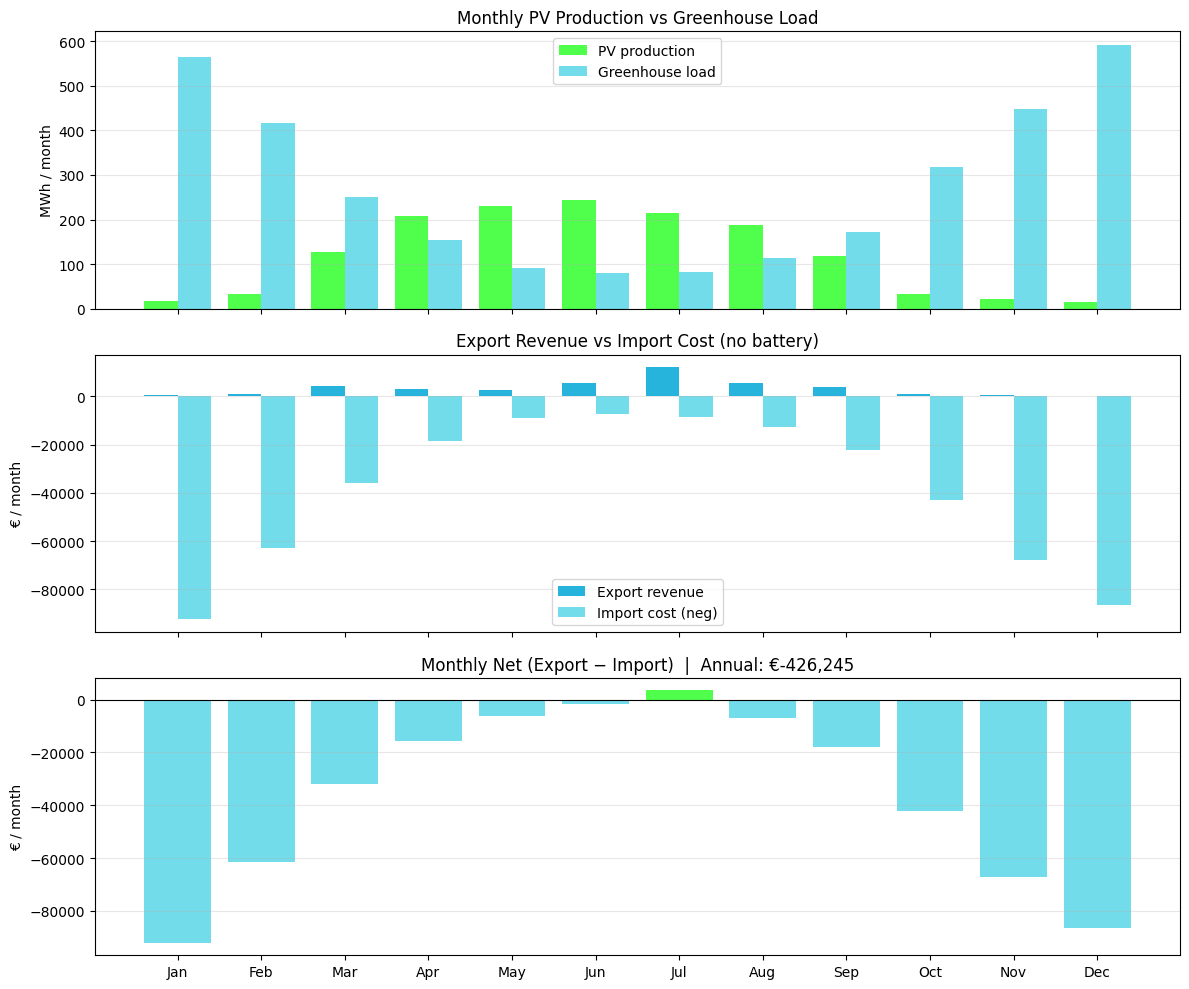

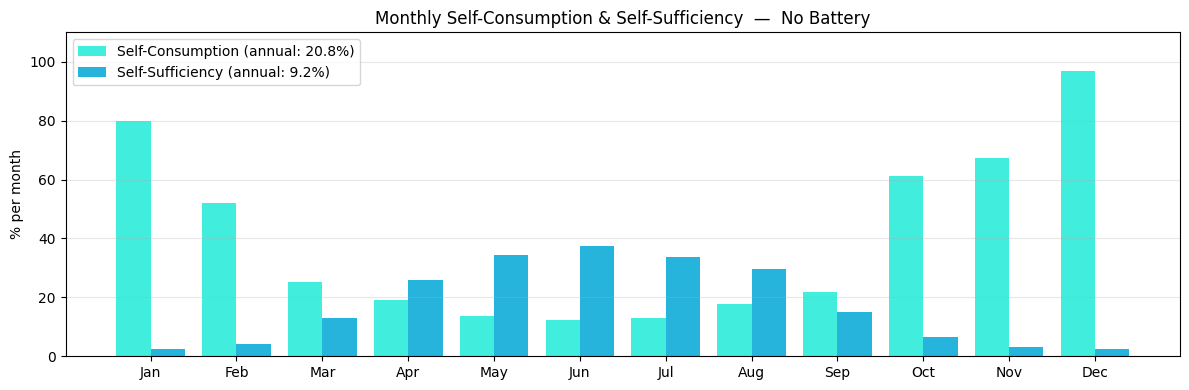

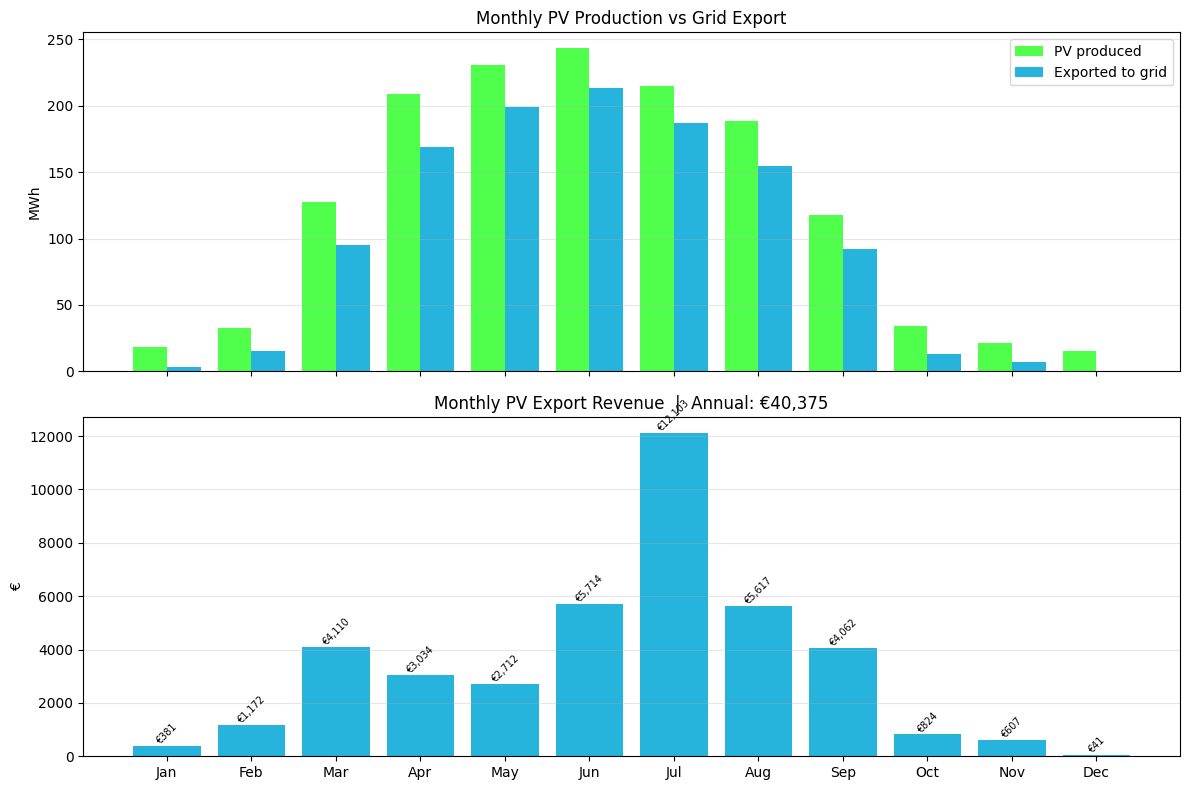

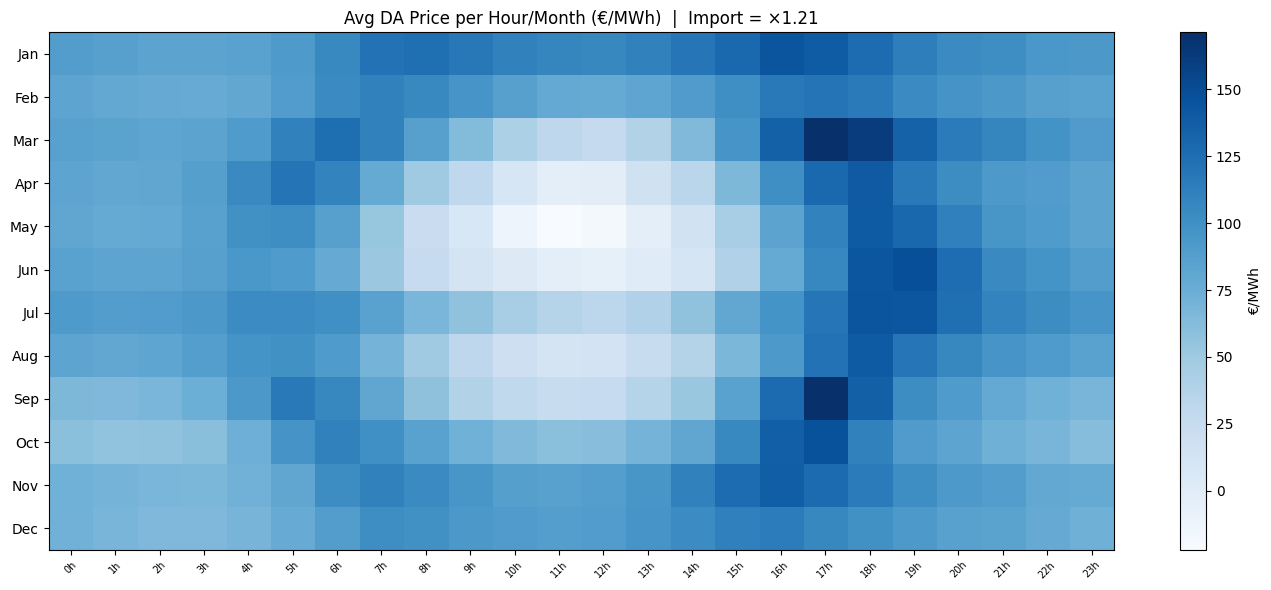

=== INVESTMENT COST BREAKDOWN ===
  Benchmark (3,600 kWh / 3.6 MW):
    Energy component  : €   234,000  (65 €/kWh × 3.6 MWh)
    Power component   : €   302,400  (84 €/kW  × 3600 kW)
    Other costs       : €   468,000  (130 €/kWh × 3.6 MWh)
    Total gross CAPEX : € 1,004,400
    Annual O&M        : €    29,160/yr  (8.1 k€/MW/yr)
  Expansion costs (above benchmark):
    Energy            : 84 €/kWh  (0.08 MEUR/MWh)
    Power             : 108 €/kW   (0.11 MEUR/MW)
  Subsidy: 0%



In [100]:
%pip install -q pandas pypsa numpy matplotlib openpyxl
import pandas as pd
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
plt.rcParams['font.family'] = 'Aptos' if 'Aptos' in _fm.get_font_names() else 'DejaVu Sans'
import warnings
warnings.filterwarnings("ignore")


# ════════════════════════════════════════════════════════════════════
# 1.  INPUTS & CONFIGURATION
#     Adjust all parameters here — nothing below needs to change
# ════════════════════════════════════════════════════════════════════

# =================================================================
#                     C O N F I G U R A T I O N
# =================================================================

# ── SCENARIO SELECTOR ──────────────────────────────────────────────────────
SCENARIO   = "2025_2026"   # "2025_2026"  or  "2023"

_FILES = {
    "2025_2026": "Input_Python-NL-Poel8-Heat-20252026.xlsx",
    "2023":      "Input_Python-NL-Poel8-heat-2023.xlsx",
}
INPUT_FILE   = _FILES[SCENARIO]
OUTPUT_EXCEL = f"nl_heat_no_dac_{SCENARIO}.xlsx"
# ───────────────────────────────────────────────────────────────────────────

COL_HEAT_LOAD = "Heat demand (kW)"   # column in Input_Python-NL-Heat.xlsx

# ─────────────────────────────────────────────────────────────────────────────
# HEAT PUMP  (DEA Technology Data, Heat pump for DH, 2025 – Image 1)
# Skipped  : construction time (0.5 yr)
# Used     : energy/tech data, regulation ability, financial data
# ─────────────────────────────────────────────────────────────────────────────
HP_COP_ANNUAL_AVG     = 5.44    # COP annual average              [544 %]
HP_COP_NOMINAL        = 5.49    # COP at nominal load             [549 %]
HP_HEAT_CAP_MW        = 3.0     # Heat generation per unit        [MW_th]
HP_AUX_ELEC_FRAC      = 0.01    # Auxiliary electricity           [1% of heat gen]
HP_FORCED_OUTAGE      = 0.00    # Forced outage rate              [0%]
HP_PLANNED_OUTAGE_WK  = 1       # Planned outage                  [1 week/yr]
HP_LIFETIME_YR        = 25      # Technical lifetime              [25 yr]
# Regulation ability
HP_MIN_LOAD           = 0.25    # Minimum partial load            [25% of full load]
HP_WARM_START_HR      = 0.1     # Warm start-up time              [0.1 h]
HP_COLD_START_HR      = 1.0     # Cold start-up time              [1 h]
# Financial data
HP_CAPEX_MEUR_MW      = 0.94    # Nominal investment              [0.94 M€/MW]
HP_INDIRECT_MEUR_MW   = 0.19    # Indirect investment costs       [0.19 M€/MW]
HP_FIXED_OM_EUR_MW_YR = 2_095   # Fixed O&M  (1 MJ/s = 1 MW)    [€/MW/yr]
HP_VAR_OM_EUR_MWH     = 3.02    # Variable O&M                   [€/MWh_th]
HP_STARTUP_EUR_MW     = 10.0    # Startup cost                   [€/MW/startup]
# Temperature levels (heat source)
HP_TEMP_SUPPLY_C      = 30      # Heat source supply              [30 °C]
HP_TEMP_RETURN_C      = 20      # Heat source return              [20 °C]

# ─────────────────────────────────────────────────────────────────────────────
# GEOTHERMAL  (DEA Technology Data, Geothermal heat plant, 2025, scenario 1
#              Images 2 + 3; columns: 1st scenario value)
# Skipped  : space requirement, construction time (4.5 yr), environment section
# Used     : energy/tech data, regulation ability (20% min), financial data
# ─────────────────────────────────────────────────────────────────────────────
GEO_HEAT_CAP_MW       = 10.86   # Generating capacity per unit    [MW_th]
GEO_EFF_ANNUAL_AVG    = 5.64    # Net heat efficiency annual avg  [564 %]
GEO_AUX_ELEC_FRAC     = 0.043   # Auxiliary electricity           [4.3% of heat gen]
GEO_FORCED_OUTAGE     = 0.02    # Forced outage rate              [2%]
GEO_PLANNED_OUTAGE_WK = 2       # Planned outage                  [2 weeks/yr]
GEO_LIFETIME_YR       = 30      # Technical lifetime              [30 yr]
# Regulation ability
GEO_MIN_LOAD          = 0.20    # Minimum load – always delivers  [≥ 20%]
GEO_COLD_START_HR     = 2.0     # Cold start-up time              [2 h]
# Financial data
GEO_CAPEX_TOTAL_MEUR_MW   = 2.65      # Total nominal investment   [M€/MW_th]
GEO_CAPEX_EQUIP_MEUR_MW   = 1.61      # Equipment share            [M€/MW_th]
GEO_CAPEX_HP_MEUR_MW      = 0.51      # Built-in HP (replaced)     [M€/MW_th]
GEO_CAPEX_INSTALL_MEUR_MW = 0.53      # Installation               [M€/MW_th]
GEO_VAR_OM_EUR_MWH        = 6.15      # Variable O&M               [€/MWh_th]
GEO_FIXED_OM_EUR_MW_YR    = 23_182    # Fixed O&M                  [€/MW_th/yr]
GEO_ABEX_MEUR_MW          = 0.10      # Abandonment cost ABEX      [M€/MW_th]
# Technology-specific data (Image 3)
GEO_HP_SCOP_ORIGINAL  = 3.77    # Original built-in HP SCOP      [377 % annual avg]
GEO_HEAT_FROM_HP_MW   = 21.0    # Heat from HP (reference scale) [MW_th]
GEO_HEAT_FROM_GEO_MW  = 100.0   # Heat from ground (ref scale)   [MW_th]
GEO_INJECTION_WELLS   = 4       # Number of injection wells
GEO_PRODUCTION_WELLS  = 2       # Number of production wells
GEO_WELL_DEPTH_M      = 1200    # Geothermal well depth           [m]

# -----------------------------------------------------------------------------
# GEOTHERMAL SIZING  (scale DEA reference system to modelled greenhouse area)
# -----------------------------------------------------------------------------
# Reference sizing (10 ha tomatoes, WITH thermal storage):
#
#   Peak heat demand (-10 deg C design)  :  9.30 MW_th
#   Geothermal target (10 ha ref)        :  3.50 MW_th  ~1 doublet per 2-3 ha
#
#   Scaled to GREENHOUSE_HA via (GREENHOUSE_HA / GREENHOUSE_HA_REF):
#   - All capacity-linked geo values, heat demand, and CAPEX/OPEX totals scale
#   - Per-unit rates (EUR/MWh, EUR/MW/yr, outage fractions) remain unchanged
#
# Parameters that SCALE with GEO_SCALE (capacity-linked):
#   capacity [MW], wells (floored at 1 doublet), heat-from-ground/HP [MW]
#
# Parameters that do NOT scale (ratios / physical constants / per-unit):
#   efficiency, outage rates, lifetime, min-load fraction, start-up time,
#   variable O&M [EUR/MWh], HP SCOP, well depth [m]
#
# CAPEX caveat:
#   DEA per-MW figures reflect a 10.93 MW reference plant (6 doublets).
#   A single-doublet system has higher EUR/MW (fixed drilling cost over
#   ~27x less capacity). Treat CAPEX here as a LOWER BOUND.
#   Rule of thumb: expect +50-150% premium for a single-doublet system.
# -----------------------------------------------------------------------------
GREENHOUSE_HA_REF = 10.0   # ha — reference greenhouse area (3.5 MW geo is for this)
GREENHOUSE_HA     = 5.2  # ha — modelled greenhouse area (scale all geo + heat demand)

GEO_TARGET_MW  = 2.8               # MW_th — fixed installed capacity (from site data)
GEO_SCALE      = GEO_TARGET_MW / GEO_HEAT_CAP_MW              # fraction of DEA ref unit

# Capacity-linked scaled values
GEO_HEAT_CAP_SCALED_MW    = GEO_TARGET_MW                                     # MW_th
GEO_HEAT_FROM_HP_SCALED   = round(GEO_HEAT_FROM_HP_MW  * GEO_SCALE, 3)       # MW_th
GEO_HEAT_FROM_GEO_SCALED  = round(GEO_HEAT_FROM_GEO_MW * GEO_SCALE, 3)       # MW_th
GEO_INJECTION_WELLS_SCALED  = max(1, round(GEO_INJECTION_WELLS  * GEO_SCALE)) # min 1
GEO_PRODUCTION_WELLS_SCALED = max(1, round(GEO_PRODUCTION_WELLS * GEO_SCALE)) # min 1

# -----------------------------------------------------------------------------
# THERMAL STORAGE  (DEA Large-Scale Hot Water Tank, steel, 2030)
# -----------------------------------------------------------------------------
# DEA reference unit: 175 MWh / 3 000 m3 / 55 K temperature difference
# Parameters used directly from DEA table (already per-unit / per-MWh):
#   Specific investment  : 3.0 M€/GWh = 3 000 EUR/MWh  (lower bound for small systems)
#   Fixed O&M            : 8.8 EUR/MWh capacity/yr
#   Variable O&M         : 0 EUR/MWh output
#   Round-trip efficiency: 98 %  (charge 100%, discharge 100%; 2% from standing losses)
#   Standing loss        : 0.2 %/day
#   Charge/discharge     : 2.9 MW per 175 MWh -> 0.01657 MW/MWh (C-rate)
#   Lifetime             : 40 yr
#   Planned outage       : 1 wk/yr
#
# CAPEX caveat: 3 000 EUR/MWh is calibrated to the 175 MWh reference.
#   Smaller systems have higher specific cost (fixed civil/equipment costs).
#   Expect +50-200% for a system below ~20 MWh. Treat as lower bound.
# -----------------------------------------------------------------------------
TS_CAP_MWH             = 10.0     # MWh — chosen capacity (tune as needed)
TS_CAP_REF_MWH         = 175.0    # MWh — DEA reference unit capacity
TS_CHARGE_MW_REF       = 2.9      # MW  — DEA reference charge/discharge power
TS_CYCLE_EFF           = 0.98     # round-trip efficiency
TS_LOSS_PCT_PER_DAY    = 0.19     # standing loss [%/day]
TS_LIFETIME_YR         = 40       # years
TS_CAPEX_EUR_MWH       = 3_036.0  # EUR/MWh  CAPEX (lower bound)
TS_FIXED_OM_EUR_MWH_YR = 8.81     # EUR/MWh capacity/yr  fixed O&M
TS_VAR_OM_EUR_MWH      = 0.0      # EUR/MWh output  (no electricity use)
TS_FORCED_OUTAGE       = 0.00
TS_PLANNED_OUTAGE_WK   = 1

# Derived totals (for PyPSA — works in kW / kWh)
TS_CHARGE_MW       = TS_CAP_MWH * (TS_CHARGE_MW_REF / TS_CAP_REF_MWH)   # scaled charge power
TS_TOTAL_CAP_KWH   = TS_CAP_MWH * 1e3                                    # kWh
TS_TOTAL_CHARGE_KW = TS_CHARGE_MW * 1e3                                  # kW
TS_LOSS_PER_HOUR   = TS_LOSS_PCT_PER_DAY / (100 * 24)                    # fraction/hr for PyPSA





COL_DA_PRICE        = "Day-ahead price (EUR/kWh)"          # €/kWh
COL_IMBALANCE_VOL   = "Imbalance volume (kWh)"               # kWh per 15-min PTU (TenneT)
COL_PV_PROFILE = "Production voltiron (W)"
COL_LOAD       = "Loadcurve (kW)"          # greenhouse electricity demand
COL_MONTH  = "Month"
COL_DAY    = "Day"
COL_HOUR   = "Hour"
COL_MINUTE = "Minute"

YEAR       = 2025
DT         = 0.25   # 15-min timestep in hours
DT_H       = 1.0    # hourly timestep for investment/heat network
PV_MODULES = int(2500 * GREENHOUSE_HA)   # 2500 modules/ha
MODULE_WP  = 145                          # Wp per module (STC nameplate)
PV_CAPEX_EUR_WP = 1.80                   # €/Wp — installed system cost
PV_LIFETIME_YR  = 25                     # yr   — PV system technical lifetime

# -----------------------------------------------------------------
# Netherlands electricity pricing
#   Export : DA market price (no SDE+/subsidy on export)
#   Import : DA price + €39/MWh energy tax + €26/MWh transport (Westland infra)
# -----------------------------------------------------------------
# -----------------------------------------------------------------
# Import price surcharges (fixed, excl. BTW)
#
#   ENERGY_TAX : Energiebelasting 2026, Staffel 4 (50,001-10,000,000 kWh/yr)
#                = €37.35/MWh = €0.03735/kWh
#                Source: Vattenfall Grootzakelijk 2026
#                https://www.vattenfall.nl/grootzakelijk/energiebelasting/tarieven-2026/
#
#   TRANSPORT  : Westland Infra variable transport tariff 2026
#                Middenspanning (MS) connection, large consumer
#                = €24.20/MWh = €0.02420/kWh
#                Source: Westland Infra Aansluit- en transporttarieven elektriciteit
#                        grootverbruik 2026 (ACM tarievenbesluit)
#                https://westlandinfra.nl/wp-content/uploads/2025/12/westland-infra-aansluit-en-transporttarieven-elektriciteit-grootverbruik-2026.pdf
# -----------------------------------------------------------------
ENERGY_TAX   = 37.35 / 1000   # €/kWh  energiebelasting 2026, staffel 4
TRANSPORT    = 24.20 / 1000   # €/kWh  Westland Infra MS transport 2026


MONTHS = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

# -----------------------------------------------------------------
# BATTERY OPTIMISATION PARAMETERS
# -----------------------------------------------------------------
BATTERY_C_RATE              = 1.0
BATTERY_EFFICIENCY_STORE    = 0.98
BATTERY_EFFICIENCY_DISPATCH = 0.97   # discharge efficiency
BATTERY_LIFE_YR             = 20   # battery lifetime (years)
MAX_CYCLES_PER_YEAR         = 6000 / 20   # 333.33 full cycles/yr over lifetime
# Note: cycle limit IS enforced in the LP via extra_functionality (linear constraint:
#       sum(dis*DT_H) <= MAX_CYCLES_PER_YEAR * e_nom — constant * variable is linear).
BATTERY_SELF_DISCHARGE_HR   = 0.1 / 100 / 24  # 0.1% per day

# -----------------------------------------------------------------
# GRID CONNECTION
# -----------------------------------------------------------------
GRID_IMPORT_MAX_KW = 1372.0    # kW — grid import limit (Transport, Westland Infra 2026)
GRID_EXPORT_MAX_KW = 1940.0    # kW — grid export limit (Teruglever, Westland Infra 2026)

# -----------------------------------------------------------------
# BATTERY INVESTMENT COSTS  (benchmark: 3,600 kWh / 3.6 MW)
# -----------------------------------------------------------------
BATTERY_BENCHMARK_KWH         = 3_600   # kWh — minimum battery size (benchmark reference)
BATTERY_BENCHMARK_MW          = 3.6     # MW  — benchmark power capacity (C-rate = 1)

BATTERY_CAPEX_ENERGY_MEUR_MWH = 0.065  # MEUR/MWh — energy component (benchmark)
BATTERY_CAPEX_POWER_MEUR_MW   = 0.084  # MEUR/MW  — power component  (benchmark)
BATTERY_CAPEX_OTHER_MEUR_MWH  = 0.13   # MEUR/MWh — other project costs (benchmark)

BATTERY_SUBSIDY_FRAC = 0.0   # subsidy fraction (0 = none; 0.5 = 50% grant)

BATTERY_OM_KEUR_MW_YR  = 8.1  # kEUR/MW/year  — fixed O&M (on total installed power capacity)

# Expansion costs (marginal, for capacity added above benchmark)
EXPANSION_ENERGY_MEUR_MWH = 0.084  # MEUR/MWh — marginal energy storage cost
EXPANSION_POWER_MEUR_MW   = 0.108  # MEUR/MW  — marginal power (charge/discharge) cost

# -----------------------------------------------------------------
# PLANNED OUTAGE
# -----------------------------------------------------------------
OUTAGE_WEEKS = 0.2   # weeks/year of planned maintenance (first weeks of January)


# ════════════════════════════════════════════════════════════════════
# 2.  DATA LOADING & PREPROCESSING
# ════════════════════════════════════════════════════════════════════

df = pd.read_excel(INPUT_FILE)
df["timestamp"] = pd.to_datetime(
    dict(year=YEAR, month=df[COL_MONTH], day=df[COL_DAY],
         hour=df[COL_HOUR], minute=df[COL_MINUTE])
)
df = df.set_index("timestamp")
# Replace index with a clean synthetic 15-min sequence to avoid DST duplicate timestamps
df.index = pd.date_range("2025-01-01 00:00", periods=len(df), freq="15min")

pv_kw        = (df[COL_PV_PROFILE] / 1000) * PV_MODULES   # kW
load_kw      = df[COL_LOAD] / DT                            # kWh per 15-min interval → kW
da_price         = df[COL_DA_PRICE].fillna(0)                    # €/kWh  (NaN → 0 if missing)
import_price     = da_price + ENERGY_TAX + TRANSPORT             # €/kWh  (DA + tax + transport)

pv_kwh   = pv_kw   * DT
load_kwh = load_kw * DT

# Baseline (no battery)
pv_surplus_kw   = (pv_kw   - load_kw).clip(lower=0)
load_deficit_kw = (load_kw - pv_kw  ).clip(lower=0)
export_rev_ts   = pv_surplus_kw   * DT * da_price
import_cost_ts  = load_deficit_kw * DT * import_price
net_revenue_ts  = export_rev_ts - import_cost_ts

# Direct PV consumed on-site (no battery)
direct_pv_kwh = pv_kwh - pv_surplus_kw * DT   # kWh self-consumed directly

eta2 = BATTERY_EFFICIENCY_STORE * BATTERY_EFFICIENCY_DISPATCH

# Baseline SC / SS
sc_base = direct_pv_kwh.sum() / pv_kwh.sum()   * 100   # % of PV used on-site
ss_base = direct_pv_kwh.sum() / load_kwh.sum() * 100   # % of load covered by PV

# Monthly aggregates (reused throughout)
pv_monthly_kwh   = pv_kwh.groupby(pv_kwh.index.month).sum()
load_monthly_kwh = load_kwh.groupby(load_kwh.index.month).sum()


# ════════════════════════════════════════════════════════════════════
# 3.  CAPEX HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════

def gross_capex(energy_kwh, power_kw):
    """Benchmark floor (3,600 kWh / 3,600 kW) + expansion CAPEX.
    Floor cost (energy + other + power) is fixed regardless of size.
    Expansion above floor: expansion_energy/kWh + expansion_power/kW.
    Other project costs (130 EUR/kWh) apply to benchmark floor only.
    """
    _bm_e = BATTERY_BENCHMARK_KWH
    _bm_p = BATTERY_BENCHMARK_MW * 1e3
    bm    = ((BATTERY_CAPEX_ENERGY_MEUR_MWH + BATTERY_CAPEX_OTHER_MEUR_MWH) * _bm_e / 1e3
             + BATTERY_CAPEX_POWER_MEUR_MW * _bm_p / 1e3) * 1e6
    exp_e = EXPANSION_ENERGY_MEUR_MWH * max(0.0, energy_kwh - _bm_e) / 1e3 * 1e6
    exp_p = EXPANSION_POWER_MEUR_MW   * max(0.0, power_kw  - _bm_p) / 1e3 * 1e6
    return bm + exp_e + exp_p

def net_capex(energy_kwh, power_kw):
    return gross_capex(energy_kwh, power_kw) * (1 - BATTERY_SUBSIDY_FRAC)

def annual_om(power_kw):
    """Annual fixed O&M cost (€), proportional to total installed power capacity."""
    return BATTERY_OM_KEUR_MW_YR * (power_kw / 1e3) * 1e3   # €/yr

def compute_payback(energy_kwh, power_kw, annual_extra_after_om):
    if annual_extra_after_om <= 0:
        return float("inf")
    return net_capex(energy_kwh, power_kw) / annual_extra_after_om


# ════════════════════════════════════════════════════════════════════
# 4.  BATTERY MODEL FUNCTIONS
# ════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════
baseline_annual_net  = net_revenue_ts.sum()
baseline_monthly_net = net_revenue_ts.groupby(net_revenue_ts.index.month).sum()
baseline_monthly_net.index = MONTHS


# ════════════════════════════════════════════════════════════════════
# 5.  INVESTMENT OPTIMISATION — SOLVE & RESULTS
# ════════════════════════════════════════════════════════════════════


# ════════════════════════════════════════════════════════════════════
# OUTPUT 1:  Baseline diagnostics (sanity check, DA spread, monthly baseline,
#            early charts — plots 1 / 1b / 1c / 2)
# ════════════════════════════════════════════════════════════════════

_no_pv_import_cost = (load_kw * import_price * DT).sum()
_pv_import_cost    = import_cost_ts.sum()
_pv_export_rev     = export_rev_ts.sum()
_pv_net_cost       = _pv_import_cost - _pv_export_rev
_pv_saving         = _no_pv_import_cost - _pv_net_cost
_pv_import_mwh     = (load_deficit_kw * DT).sum() / 1000
_pv_export_mwh     = (pv_surplus_kw   * DT).sum() / 1000

W = 58
print()
print("="*W)
print(f"  {'METRIC':<30} {'Baseline':>10} {'PV only':>12}")
print("="*W)
print(f"  {'PV production (MWh)':<30} {'--':>10} {pv_kwh.sum()/1000:>12.1f}")
print(f"  {'Grid import (MWh)':<30} {load_kwh.sum()/1000:>10.1f} {_pv_import_mwh:>12.1f}")
print(f"  {'Grid export (MWh)':<30} {'--':>10} {_pv_export_mwh:>12.1f}")
print(f"  {'SC (%)':<30} {'--':>10} {sc_base:>11.1f}%")
print(f"  {'SS (%)':<30} {'--':>10} {ss_base:>11.1f}%")
print("-"*W)
print(f"  {'Import cost (€)':<30} {_no_pv_import_cost:>10,.0f} {_pv_import_cost:>12,.0f}")
print(f"  {'Export revenue (€)':<30} {'--':>10} {_pv_export_rev:>12,.0f}")
print(f"  {'Net electricity cost (€)':<30} {_no_pv_import_cost:>10,.0f} {_pv_net_cost:>12,.0f}")
print(f"  {'PV savings vs baseline (€)':<30} {'--':>10} {_pv_saving:>12,.0f}")
print("="*W)
print()

print("=== SANITY CHECK ===")
print(f"  Annual PV yield           : {pv_kwh.sum() / 1000:.1f} MWh")
print(f"  Annual load               : {load_kwh.sum() / 1000:.1f} MWh")
print(f"  DA price range            : €{da_price.min()*1000:.1f} – {da_price.max()*1000:.1f} /MWh")
print(f"  Import price range        : €{import_price.min()*1000:.1f} – {import_price.max()*1000:.1f} /MWh  (DA + €39 tax + €26 transport)")
print(f"  Negative DA steps         : {(da_price < 0).sum()} ({(da_price < 0).mean()*100:.1f}%)")
print(f"  Baseline export revenue   : €{export_rev_ts.sum():,.0f}/yr")
print(f"  Baseline import cost      : €{import_cost_ts.sum():,.0f}/yr")
print(f"  Baseline net              : €{net_revenue_ts.sum():,.0f}/yr")
print()
print(f"  --- No-battery SC / SS ---")
print(f"  Self-Consumption (no bat) : {sc_base:.1f}%  (PV used on-site / total PV)")
print(f"  Self-Sufficiency (no bat) : {ss_base:.1f}%  (load covered by PV / total load)")
print()

print("=== DA SPREAD DIAGNOSTIC ===")

daily_max    = da_price.resample("D").max() * 1000
daily_min    = da_price.resample("D").min() * 1000
daily_spread = daily_max - daily_min

print(f"  Round-trip efficiency (η²)   : {eta2*100:.1f}%")
print(f"  Import surcharge              : €{(ENERGY_TAX+TRANSPORT)*1000:.0f}/MWh fixed  (€39 tax + €26 transport)")
print()
print(f"  Daily DA spread stats (€/MWh):")
print(f"    Mean   : €{daily_spread.mean():.1f}")
print(f"    Median : €{daily_spread.median():.1f}")
print(f"    P75    : €{daily_spread.quantile(0.75):.1f}")
print(f"    P90    : €{daily_spread.quantile(0.90):.1f}")
print(f"    Max    : €{daily_spread.max():.1f}")
print(f"    Days spread > €50/MWh : {(daily_spread > 50).sum()} days")
print(f"    Days spread > €30/MWh : {(daily_spread > 30).sum()} days")
print()

hourly_avg          = (da_price * 1000).groupby(da_price.index.hour).mean()
best_charge_hour    = int(hourly_avg.idxmin())
best_discharge_hour = int(hourly_avg.idxmax())
spread_best_hours   = hourly_avg.max() - hourly_avg.min()
effective_import_spread = hourly_avg.max() * 1.21 - hourly_avg.min()

print(f"  Best avg charge hour     : {best_charge_hour:02d}:00  (avg €{hourly_avg.min():.1f}/MWh)")
print(f"  Best avg discharge hour  : {best_discharge_hour:02d}:00  (avg €{hourly_avg.max():.1f}/MWh)")
print(f"  DA spread (best hours)   : €{spread_best_hours:.1f}/MWh")
print(f"  After η² loss            : €{spread_best_hours * eta2:.1f}/MWh net (export→export)")
print(f"  Import-offset spread     : €{effective_import_spread:.1f}/MWh")
print(f"  After η² (import offset) : €{effective_import_spread * eta2:.1f}/MWh net")
print()

direct_pv_monthly = direct_pv_kwh.groupby(direct_pv_kwh.index.month).sum()
monthly_sc_base   = direct_pv_monthly / pv_monthly_kwh   * 100
monthly_ss_base   = direct_pv_monthly / load_monthly_kwh * 100

export_kwh_base  = pv_surplus_kw * DT
exp_monthly_base = export_kwh_base.groupby(export_kwh_base.index.month).sum() / 1000   # MWh

monthly = pd.DataFrame({
    "PV production (MWh)":   pv_monthly_kwh / 1000,
    "Load (MWh)":            load_monthly_kwh / 1000,
    "Exported (MWh)":        exp_monthly_base,
    "Export revenue (€)":    export_rev_ts.groupby(export_rev_ts.index.month).sum(),
    "Import cost (€)":       import_cost_ts.groupby(import_cost_ts.index.month).sum(),
    "Net (€)":               net_revenue_ts.groupby(net_revenue_ts.index.month).sum(),
    "SC base (%)": monthly_sc_base.values,
    "SS base (%)": monthly_ss_base.values,
    "Avg DA price (€/MWh)": (da_price * 1000).groupby(da_price.index.month).mean(),
})
monthly.index = MONTHS
monthly_sc_base.index = MONTHS
monthly_ss_base.index = MONTHS

print("=== MONTHLY BASELINE (no battery) ===")
print(f"{'Month':<6} {'PV (MWh)':>9} {'Load (MWh)':>10} {'Export €':>10} "
      f"{'Import €':>10} {'Net €':>10} {'SC %':>7} {'SS %':>7}")
print("-" * 73)
for m in MONTHS:
    print(f"{m:<6} {monthly.loc[m,'PV production (MWh)']:>9.1f}"
          f" {monthly.loc[m,'Load (MWh)']:>10.1f}"
          f" {monthly.loc[m,'Export revenue (€)']:>10,.0f}"
          f" {monthly.loc[m,'Import cost (€)']:>10,.0f}"
          f" {monthly.loc[m,'Net (€)']:>10,.0f}"
          f" {monthly.loc[m,'SC base (%)']:>6.1f}%"
          f" {monthly.loc[m,'SS base (%)']:>6.1f}%")
print("-" * 73)
print(f"{'TOTAL':<6} {monthly['PV production (MWh)'].sum():>9.1f}"
      f" {monthly['Load (MWh)'].sum():>10.1f}"
      f" {monthly['Export revenue (€)'].sum():>10,.0f}"
      f" {monthly['Import cost (€)'].sum():>10,.0f}"
      f" {monthly['Net (€)'].sum():>10,.0f}"
      f" {sc_base:>6.1f}%"
      f" {ss_base:>6.1f}%")
print()

print("=== MONTHLY PV REVENUE ANALYSIS (no battery) ===")
print(f"{'Month':<6} {'PV (MWh)':>9} {'Exported (MWh)':>15} {'Avg export €/MWh':>18} "
      f"{'Export rev €':>13} {'€/MWh PV':>10}")
print("-" * 76)
for m in MONTHS:
    pv_mwh   = monthly.loc[m, "PV production (MWh)"]
    exp_mwh  = monthly.loc[m, "Exported (MWh)"]
    exp_rev  = monthly.loc[m, "Export revenue (€)"]
    avg_exp  = exp_rev / exp_mwh if exp_mwh > 0 else 0
    rev_pv   = exp_rev / pv_mwh  if pv_mwh  > 0 else 0
    print(f"{m:<6} {pv_mwh:>9.1f} {exp_mwh:>15.1f} {avg_exp:>18.2f} "
          f"{exp_rev:>13,.0f} {rev_pv:>10.2f}")
print("-" * 76)
tot_pv  = monthly["PV production (MWh)"].sum()
tot_exp = monthly["Exported (MWh)"].sum()
tot_rev = monthly["Export revenue (€)"].sum()
print(f"{'TOTAL':<6} {tot_pv:>9.1f} {tot_exp:>15.1f} "
      f"{tot_rev/tot_exp if tot_exp>0 else 0:>18.2f} "
      f"{tot_rev:>13,.0f} {tot_rev/tot_pv if tot_pv>0 else 0:>10.2f}")
print()


# Plot 1 — Monthly PV, load, and net revenue
fig1, axes1 = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
x = np.arange(12)

axes1[0].bar(x - 0.2, monthly["PV production (MWh)"].values, 0.4,
             color="#30FF2C", alpha=0.85, label="PV production")
axes1[0].bar(x + 0.2, monthly["Load (MWh)"].values, 0.4,
             color="#5AD6E7", alpha=0.85, label="Greenhouse load")
axes1[0].set_ylabel("MWh / month")
axes1[0].set_title("Monthly PV Production vs Greenhouse Load")
axes1[0].legend()
axes1[0].grid(True, alpha=0.3, axis="y")

axes1[1].bar(x - 0.2, monthly["Export revenue (€)"].values, 0.4,
             color="#00A6D6", alpha=0.85, label="Export revenue")
axes1[1].bar(x + 0.2, -monthly["Import cost (€)"].values, 0.4,
             color="#5AD6E7", alpha=0.85, label="Import cost (neg)")
axes1[1].set_ylabel("€ / month")
axes1[1].set_title("Export Revenue vs Import Cost (no battery)")
axes1[1].legend()
axes1[1].grid(True, alpha=0.3, axis="y")

colors1 = ["#30FF2C" if v >= 0 else "#5AD6E7" for v in monthly["Net (€)"].values]
axes1[2].bar(x, monthly["Net (€)"].values, color=colors1, alpha=0.85)
axes1[2].axhline(0, color="black", lw=0.8)
axes1[2].set_xticks(x); axes1[2].set_xticklabels(MONTHS)
axes1[2].set_ylabel("€ / month")
axes1[2].set_title(f"Monthly Net (Export − Import)  |  Annual: €{monthly['Net (€)'].sum():,.0f}")
axes1[2].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_monthly_baseline.png", dpi=150)
plt.show()

# Plot 1b — Monthly SC and SS (baseline)
fig1b, ax1b = plt.subplots(figsize=(12, 4))
ax1b.bar(x - 0.2, monthly["SC base (%)"].values, 0.4,
         color="#1FEAD6", alpha=0.85, label=f"Self-Consumption (annual: {sc_base:.1f}%)")
ax1b.bar(x + 0.2, monthly["SS base (%)"].values, 0.4,
         color="#00A6D6", alpha=0.85, label=f"Self-Sufficiency (annual: {ss_base:.1f}%)")
ax1b.set_xticks(x); ax1b.set_xticklabels(MONTHS)
ax1b.set_ylabel("% per month")
ax1b.set_title("Monthly Self-Consumption & Self-Sufficiency  —  No Battery")
ax1b.legend()
ax1b.grid(True, alpha=0.3, axis="y")
ax1b.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("nl_sc_ss_baseline.png", dpi=150)
plt.show()

# Plot 1c — Monthly PV revenue breakdown
fig1c, axes1c = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes1c[0].bar(x - 0.2, monthly["PV production (MWh)"].values, 0.4,
              color="#30FF2C", alpha=0.85, label="PV produced")
axes1c[0].bar(x + 0.2, monthly["Exported (MWh)"].values, 0.4,
              color="#00A6D6", alpha=0.85, label="Exported to grid")
axes1c[0].set_ylabel("MWh")
axes1c[0].set_title("Monthly PV Production vs Grid Export")
axes1c[0].legend()
axes1c[0].grid(True, alpha=0.3, axis="y")

axes1c[1].bar(x, monthly["Export revenue (€)"].values, color="#00A6D6", alpha=0.85)
for i, v in enumerate(monthly["Export revenue (€)"].values):
    axes1c[1].text(i, v + 50, f"€{v:,.0f}", ha="center", fontsize=7, rotation=45)
axes1c[1].set_xticks(x); axes1c[1].set_xticklabels(MONTHS)
axes1c[1].set_ylabel("€")
axes1c[1].set_title(f"Monthly PV Export Revenue  |  Annual: €{monthly['Export revenue (€)'].sum():,.0f}")
axes1c[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_pv_revenue_monthly.png", dpi=150)
plt.show()

# Plot 2 — Avg DA price per hour/month heatmap
da_hourly_df = pd.DataFrame({
    "month": da_price.index.month,
    "hour":  da_price.index.hour,
    "price": da_price.values * 1000,
})
pivot_da = da_hourly_df.groupby(["month","hour"])["price"].mean().unstack(level=1)
pivot_da.index = MONTHS

fig2, ax2 = plt.subplots(figsize=(14, 6))
im2 = ax2.imshow(pivot_da.reindex(columns=range(24)).fillna(0).values,
                 aspect="auto", cmap="Blues")
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=7)
ax2.set_yticks(range(12)); ax2.set_yticklabels(MONTHS)
ax2.set_title("Avg DA Price per Hour/Month (€/MWh)  |  Import = ×1.21")
plt.colorbar(im2, ax=ax2, label="€/MWh")
plt.tight_layout()
plt.savefig("nl_da_price_heatmap.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════
# OUTPUT 2:  Capex schedule
# ════════════════════════════════════════════════════════════════════

print("=== INVESTMENT COST BREAKDOWN ===")
bm_e   = BATTERY_CAPEX_ENERGY_MEUR_MWH * (BATTERY_BENCHMARK_KWH/1e3) * 1e6
bm_p   = BATTERY_CAPEX_POWER_MEUR_MW   *  BATTERY_BENCHMARK_MW       * 1e6
bm_o   = BATTERY_CAPEX_OTHER_MEUR_MWH  * (BATTERY_BENCHMARK_KWH/1e3) * 1e6
bm_tot = bm_e + bm_p + bm_o
print(f"  Benchmark ({BATTERY_BENCHMARK_KWH:,.0f} kWh / {BATTERY_BENCHMARK_MW:.1f} MW):")
print(f"    Energy component  : €{bm_e:>10,.0f}  ({BATTERY_CAPEX_ENERGY_MEUR_MWH*1e3:.0f} €/kWh × {BATTERY_BENCHMARK_KWH/1e3:.1f} MWh)")
print(f"    Power component   : €{bm_p:>10,.0f}  ({BATTERY_CAPEX_POWER_MEUR_MW*1e6/1e3:.0f} €/kW  × {BATTERY_BENCHMARK_MW*1e3:.0f} kW)")
print(f"    Other costs       : €{bm_o:>10,.0f}  ({BATTERY_CAPEX_OTHER_MEUR_MWH*1e3:.0f} €/kWh × {BATTERY_BENCHMARK_KWH/1e3:.1f} MWh)")
print(f"    Total gross CAPEX : €{bm_tot:>10,.0f}")
print(f"    Annual O&M        : €{annual_om(BATTERY_BENCHMARK_MW * 1e3):>10,.0f}/yr  ({BATTERY_OM_KEUR_MW_YR:.1f} k€/MW/yr)")
print(f"  Expansion costs (above benchmark):")
print(f"    Energy            : {EXPANSION_ENERGY_MEUR_MWH*1e3:.0f} €/kWh  ({EXPANSION_ENERGY_MEUR_MWH:.2f} MEUR/MWh)")
print(f"    Power             : {EXPANSION_POWER_MEUR_MW*1e3:.0f} €/kW   ({EXPANSION_POWER_MEUR_MW:.2f} MEUR/MW)")
print(f"  Subsidy: {BATTERY_SUBSIDY_FRAC*100:.0f}%")
print()


# =================================================================
#          D A C   C O N F I G U R A T I O N   (2030)
#  All DAC numbers live here — nothing below hard-codes them.
# =================================================================

DAC_CONFIG = {
    "add_dac":              False,  # Script 2: electrical + heat system, no DAC
    "dac_unit_commitment":  False,   # True = MILP, False = LP (default)
    "co2_profile_source":   "auto",  # "pv" | "solar_geometry" | "auto"
    "heat_price_eur_per_MWh": 20.0, # representative heat cost for MILP startup only
}

# Solid-sorbent DAC (Climeworks-style, 2030 DEA data)
DAC_2030 = {
    "elec_in_MWh_per_tCO2":   0.225 + 0.11,  # DAC + compression
    "heat_in_MWh_per_tCO2":   1.5,            # 100 degC consumed
    "heat_out_MWh_per_tCO2":  1.0 + 0.16,     # 50 degC waste delivered
    "capex_Meur_per_tCO2h":   3.0,
    "fom_Meur_per_tCO2h_yr":  0.12,
    "lifetime_yr":            25,
    "forced_outage_frac":     0.03,
    "planned_outage_weeks":   3,    # placed weeks 1-3 (Jan) — lowest CO2 demand
    "vom_eur_per_tCO2":       0.0,
    "warmup_cycles_on_start": 1.0,
}

# Waste-heat recovery using EXISTING HP (no new capex)
WASTE_HEAT_RECOVERY = {
    "cop": 5.0,         # 50 degC source -> 70 degC sink, 20K lift
    "booster_cop": 4.5, # 70 degC source -> 100 degC sink, 30K lift (same Carnot-eta as WHR: 12.43 x 0.29)
}

# Liquid CO2 tank — DEA terminal reference (2030)
TERMINAL_REF = {
    "size_small_t":                 3_000,
    "size_large_t":                14_000,
    "capex_eur_per_t_small":        2_199,
    "capex_eur_per_t_large":        1_338,
    "fom_eur_per_t_yr_small":          63.1,
    "fom_eur_per_t_yr_large":          38.4,
    "vom_eur_per_t":                    0.0,
    "energy_kWh_per_tCO2_per_day":      0.20,
    "lifetime_yr":                     25,
}

# CO2 demand inside the greenhouse
CO2_DEMAND = {
    "annual_tCO2_per_ha":  250,
    "hectares":            GREENHOUSE_HA,  # inferred from existing model
    "profile_source":      "auto",
    "latitude_deg":        52.0,
}

In [101]:
# ════════════════════════════════════════════════════════════════════════════
# COMBINED OPTIMISATION MODEL  —  NL Greenhouse (PyPSA)
#
# Single network: elec bus + heat bus
# Jointly optimises:
#   Battery        : energy + power, above 3 600 kWh / 3.6 MW benchmark floor
#   Heat pump      : capacity extendable from 0  (DEA CAPEX, per kW_e)
#   Thermal storage: capacity extendable from 0  (DEA CAPEX, fixed C-rate ratio)
# Fixed:
#   PV  (from input profile)
#   Geothermal at GEO_TARGET_MW = 2.8 MW
#   Grid connection
#
# Marginal costs in optimizer (pre-solve):
#   Geo     : GEO_VAR_OM_EUR_MWH per MWh_th  →  scaled to €/kWh_e input
#   HP      : HP_VAR_OM_EUR_MWH  per MWh_th  →  scaled to €/kWh_e input
#   Curtail : GEO_VAR_OM_EUR_MWH + HEAT_CURTAIL_PENALTY  →  excluded from financials
# ════════════════════════════════════════════════════════════════════════════

heat_load_mw = df[COL_HEAT_LOAD] / 1000 * GREENHOUSE_HA  # kW (1 ha ref) -> MW, scaled to modelled area

HEAT_CURTAIL_PENALTY = 10.0   # €/MWh_th — optimizer incentive only, excluded from financial outputs

# ── Pre-computed capital cost parameters (used in build function + post-solve reporting) ──

# Battery full-cost LP (Option B: no benchmark floor, C-rate floats freely)
_bat_store_cap  = EXPANSION_ENERGY_MEUR_MWH * 1e6 / 1e3 / BATTERY_LIFE_YR                                              # €/kWh/yr — expansion energy only
_bat_link_cap   = (EXPANSION_POWER_MEUR_MW * 1e6 / 1e3 / BATTERY_LIFE_YR) / 2 + BATTERY_OM_KEUR_MW_YR * 1e3 / 1e3 / 2  # €/kW/yr per link — expansion power + O&M on total power

# Heat pump (capital_cost per kW_e of p_nom; DEA CAPEX is per MW_th → scale by COP)
_hp_capex_kw_e   = ((HP_CAPEX_MEUR_MW + HP_INDIRECT_MEUR_MW)
                    * 1e6 / 1e3 * HP_COP_ANNUAL_AVG / HP_LIFETIME_YR)                 # €/kW_e/yr  CAPEX only
_hp_fixom_kw_e   = HP_FIXED_OM_EUR_MW_YR / 1e3 * HP_COP_ANNUAL_AVG                   # €/kW_e/yr  fixed O&M only
_hp_capital_cost = _hp_capex_kw_e + _hp_fixom_kw_e                                    # €/kW_e/yr  total

# Thermal storage (capital_cost per kW of p_nom; energy = p_nom × max_hours, ratio locked to DEA)
_ts_max_h         = TS_CAP_REF_MWH / TS_CHARGE_MW_REF                                 # ~60.34 h  fixed DEA C-rate ratio
_ts_capex_kw      = TS_CAPEX_EUR_MWH * _ts_max_h / 1e3 / TS_LIFETIME_YR              # €/kW/yr  CAPEX only
_ts_fixom_kw      = TS_FIXED_OM_EUR_MWH_YR * _ts_max_h / 1e3                         # €/kW/yr  fixed O&M only
_ts_capital_cost  = _ts_capex_kw + _ts_fixom_kw                                       # €/kW/yr  total

# Marginal costs (per kWh of Link input; for curtailment per kWh_th)
# Link convention: p0 = input [kW], efficiency η → p1 = -η·p0 [kW] injected into bus1
# → cost per kWh_th = cost_per_kWh_e / η
_geo_mc      = GEO_VAR_OM_EUR_MWH / 1e3 * GEO_AUX_ELEC_FRAC    # €/kWh_e  (η=1/0.04=25 → ÷25 to get per kWh_th ✓)
_hp_mc       = HP_VAR_OM_EUR_MWH  / 1e3 / HP_COP_ANNUAL_AVG     # €/kWh_e  (η=COP     → ÷COP to get per kWh_th ✓)
_curtail_mc  = (GEO_VAR_OM_EUR_MWH + HEAT_CURTAIL_PENALTY) / 1e3 # €/kWh_th (excluded from financials)

print(f"Capital cost parameters:")
print(f"  HP      : {_hp_capital_cost:.2f} €/kW_e/yr  (CAPEX {_hp_capex_kw_e:.2f} + O&M {_hp_fixom_kw_e:.2f})")
print(f"  Storage : {_ts_capital_cost:.4f} €/kW/yr   (CAPEX {_ts_capex_kw:.4f} + O&M {_ts_fixom_kw:.4f})")
print(f"  Storage max_hours: {_ts_max_h:.2f} h  (DEA C-rate ratio)")
print(f"Marginal costs (pre-solve):")
print(f"  Geo     : {_geo_mc*1e3:.4f} €/kWh_e  = {GEO_VAR_OM_EUR_MWH:.2f} €/MWh_th")
print(f"  HP      : {_hp_mc*1e3:.4f} €/kWh_e  = {HP_VAR_OM_EUR_MWH:.2f} €/MWh_th")
print(f"  Curtail : {_curtail_mc*1e3:.3f} €/kWh_th  ({GEO_VAR_OM_EUR_MWH:.2f} geo O&M + {HEAT_CURTAIL_PENALTY:.0f} penalty)")
print()

if DAC_CONFIG.get('add_dac', False):
    _dac_a        = DAC_2030['elec_in_MWh_per_tCO2']
    _dac_capex_kw = DAC_2030['capex_Meur_per_tCO2h'] * 1e6 / _dac_a / DAC_2030['lifetime_yr'] / 1000
    _dac_fom_kw   = DAC_2030['fom_Meur_per_tCO2h_yr'] * 1e6 / _dac_a / 1000
    _dac_cap_kw   = _dac_capex_kw + _dac_fom_kw
    _dac_vom      = DAC_2030['vom_eur_per_tCO2']
    _dac_annual_t = CO2_DEMAND['annual_tCO2_per_ha'] * CO2_DEMAND['hectares']
    print(f"DAC cost parameters:")
    print(f"  DAC     : {_dac_cap_kw:.2f} €/kW_e/yr  (CAPEX {_dac_capex_kw:.2f} + FOM {_dac_fom_kw:.2f})")
    print(f"  VOM     : {_dac_vom:.2f} €/tCO2  (elec cost priced via grid)")
    print(f"  CO2 demand: {_dac_annual_t:.1f} tCO2/yr  ({CO2_DEMAND['hectares']:.1f} ha x {CO2_DEMAND['annual_tCO2_per_ha']} tCO2/ha/yr)")
    print()


# ── Pre-computed shared values (used by all network builders) ─────────────────────
_PV_NOM_KW     = float(pv_kw.max())
_PV_PU         = (pv_kw / _PV_NOM_KW).clip(upper=1.0)
_BAT_OFF       = int(round(OUTAGE_WEEKS * 7 * 24 / DT))
_BAT_MAX_PU    = pd.Series(1.0, index=df.index)
_BAT_MAX_PU.iloc[:_BAT_OFF] = 0.0

# Hourly resampled series for investment sizing (4x faster solve)
_H              = pd.date_range(df.index[0], periods=len(df)//4, freq='h')
_PV_PU_H        = _PV_PU.resample('h').mean()
_load_kw_H      = load_kw.resample('h').mean()
_import_price_H = import_price.resample('h').mean()
_da_price_H     = da_price.resample('h').mean()
_BAT_MAX_PU_H   = _BAT_MAX_PU.resample('h').min()
_P_EXPORT_NOM  = GRID_EXPORT_MAX_KW if GRID_EXPORT_MAX_KW else _PV_NOM_KW * 1.1
_P_IMPORT_ELEC = GRID_IMPORT_MAX_KW if GRID_IMPORT_MAX_KW else float(load_kw.max()) * 2


def _make_network(snapshots=None, dt=None):
    n = pypsa.Network()
    n.set_snapshots(snapshots if snapshots is not None else df.index)
    n.snapshot_weightings.loc[:, :] = dt if dt is not None else DT
    return n


def _add_elec_bus(n, p_import, p_export, mc_import, mc_export, pv_pu=None, elec_load=None):
    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0.0)
    n.generators_t.p_max_pu["pv"] = pv_pu if pv_pu is not None else _PV_PU
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = elec_load if elec_load is not None else load_kw
    n.add("Generator", "grid_import", bus="elec", p_nom=p_import, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_import"] = mc_import
    n.add("Generator", "grid_export", bus="elec", p_nom=p_export,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0.0)
    n.generators_t.marginal_cost["grid_export"] = mc_export


def _add_battery(n, extendable=True, bat_e=None, bat_p=None, max_pu=None):
    n.add("Bus", "battery_bus", carrier="electricity")

    pu    = max_pu if max_pu is not None else _BAT_MAX_PU
    if extendable:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=0, e_nom_min=BATTERY_BENCHMARK_KWH,
              e_nom_extendable=True, e_cyclic=True,
              standing_loss=BATTERY_SELF_DISCHARGE_HR,
              capital_cost=_bat_store_cap, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_STORE,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=0, p_nom_min=BATTERY_BENCHMARK_MW * 1e3, p_nom_extendable=True,
              efficiency=BATTERY_EFFICIENCY_DISPATCH,
              capital_cost=_bat_link_cap, marginal_cost=0.0)
    else:
        n.add("Store", "battery_store", bus="battery_bus",
              e_nom=bat_e, e_cyclic=True,
              standing_loss=BATTERY_SELF_DISCHARGE_HR, marginal_cost=0.0)
        n.add("Link", "bat_charge", bus0="elec", bus1="battery_bus",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_STORE, marginal_cost=0.0)
        n.add("Link", "bat_discharge", bus0="battery_bus", bus1="elec",
              p_nom=bat_p, efficiency=BATTERY_EFFICIENCY_DISPATCH, marginal_cost=0.0)
    n.links_t.p_max_pu["bat_charge"]    = pu
    n.links_t.p_max_pu["bat_discharge"] = pu


def build_elec_only_network():
    """Battery + PV + grid only — no heat. Used as grid-support comparison baseline."""
    n = _make_network(snapshots=_H, dt=1.0)
    _add_elec_bus(n, _P_IMPORT_ELEC, _P_EXPORT_NOM, _import_price_H, _da_price_H,
                  pv_pu=_PV_PU_H, elec_load=_load_kw_H)
    _add_battery(n, extendable=True, max_pu=_BAT_MAX_PU_H)
    n.sanitize()
    status, cond = n.optimize(solver_name="highs", log_to_console=False)
    if status not in ("ok", "warning"):
        raise RuntimeError(f"Elec-only solve failed: {cond}")
    return n


import math as _math


# ─────────────────────────────────────────────────────────────────────────────
# DAC HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def _co2_demand_profile(pv_pu_H, snapshots, annual_tco2, profile_source, latitude_deg):
    """Hourly CO2 demand (tCO2/h). Annual sum normalised to annual_tco2.
    Uses PV p_max_pu when available (auto/pv), solar geometry as fallback."""
    if profile_source in ("pv", "auto") and pv_pu_H is not None:
        raw = pv_pu_H.reindex(snapshots).fillna(0.0).clip(lower=0.0)
    else:
        lat = _math.radians(latitude_deg)
        vals = []
        for ts in snapshots:
            doy  = ts.timetuple().tm_yday
            hour = ts.hour + ts.minute / 60.0
            decl = _math.radians(23.45 * _math.sin(_math.radians(360 / 365 * (doy - 81))))
            ha   = _math.radians(15 * (hour - 12))
            alt  = _math.asin(_math.sin(lat) * _math.sin(decl)
                              + _math.cos(lat) * _math.cos(decl) * _math.cos(ha))
            vals.append(max(0.0, _math.sin(alt)))
        raw = pd.Series(vals, index=snapshots)
    total = float(raw.sum())
    if total <= 0:
        return raw * 0.0
    return raw * (annual_tco2 / total)


def _capex_per_t_tank(size_t):
    """Power-law scale rule from two DEA reference points."""
    size_t = max(size_t, 1.0)  # guard against near-zero solved size
    S1 = TERMINAL_REF['size_small_t'];  C1 = TERMINAL_REF['capex_eur_per_t_small']
    S2 = TERMINAL_REF['size_large_t'];  C2 = TERMINAL_REF['capex_eur_per_t_large']
    n_s = _math.log((C2 * S2) / (C1 * S1)) / _math.log(S2 / S1)
    return C1 * (size_t / S1) ** (n_s - 1)


def _fom_per_t_yr_tank(size_t):
    size_t = max(size_t, 1.0)
    S1 = TERMINAL_REF['size_small_t'];  F1 = TERMINAL_REF['fom_eur_per_t_yr_small']
    S2 = TERMINAL_REF['size_large_t'];  F2 = TERMINAL_REF['fom_eur_per_t_yr_large']
    n_s = _math.log((F2 * S2) / (F1 * S1)) / _math.log(S2 / S1)
    return F1 * (size_t / S1) ** (n_s - 1)


def _add_dac_components(n, dac_config, pv_pu_H, snapshots):
    """Add DAC, heat_low bus, CO2 bus, waste-heat recovery, CO2 tank to network n.
    n must already have 'elec' and 'heat' buses."""
    d   = DAC_2030
    cfg = dac_config
    a   = d['elec_in_MWh_per_tCO2']   # 0.335  MWh_e / tCO2
    b   = d['heat_in_MWh_per_tCO2']   # 1.5    MWh_th / tCO2  (100 degC consumed)
    g   = d['heat_out_MWh_per_tCO2']  # 1.16   MWh_th / tCO2  (50 degC waste)

    # ── New buses ────────────────────────────────────────────────────────────
    n.add('Carrier', 'co2')
    n.add('Carrier', 'heat_low')
    n.add('Carrier', 'heat_high')
    n.add('Bus', 'dac_co2',  carrier='co2')
    n.add('Bus', 'heat_low', carrier='heat_low')
    n.add('Bus', 'heat_high', carrier='heat_high')  # 100 degC bus for DAC

    # ── CO2 demand (seasonal daytime profile driven by PV) ───────────────────
    annual_tco2 = CO2_DEMAND['annual_tCO2_per_ha'] * CO2_DEMAND['hectares']
    co2_prof    = _co2_demand_profile(
        pv_pu_H, snapshots, annual_tco2,
        CO2_DEMAND['profile_source'], CO2_DEMAND['latitude_deg'])
    n.add('Load', 'co2_demand', bus='dac_co2')
    n.loads_t.p_set['co2_demand'] = co2_prof

    # ── heat_low vent — free disposal of surplus waste heat ──────────────────
    # p_min_pu=-1, p_max_pu=0: can only absorb (same pattern as grid_export)
    n.add('Generator', 'heat_low_vent', bus='heat_low',
          p_nom=1e6, p_min_pu=-1, p_max_pu=0, marginal_cost=0.0)

    # ── DAC availability: planned outage weeks 1-3 (Jan), forced outage rest ─
    _off_h  = int(d['planned_outage_weeks'] * 7 * 24)
    dac_pu  = pd.Series(1.0 - d['forced_outage_frac'], index=snapshots)
    dac_pu.iloc[:_off_h] = 0.0

    # ── DAC capital cost: capex/lifetime + FOM  (matches HP/storage pattern) ─
    capex_per_MWe  = d['capex_Meur_per_tCO2h'] * 1e6 / a   # EUR/MW_e
    fom_per_MWe_yr = d['fom_Meur_per_tCO2h_yr'] * 1e6 / a  # EUR/MW_e/yr
    _dac_capital   = capex_per_MWe / d['lifetime_yr'] + fom_per_MWe_yr

    # ── MILP params (only active when dac_unit_commitment=True) ─────────────
    # NOTE: PyPSA requires fixed p_nom for committable Links.
    # MILP mode via validate_dac_mode() pre-solves LP to get p_nom_opt, then
    # sets committable=True on a rebuilt network with fixed p_nom.
    # start_up_cost is a representative penalty in EUR/start (not MW-scaled here).
    _uc_kw = {}
    if cfg.get('dac_unit_commitment', False):
        _heat_px = cfg.get('heat_price_eur_per_MWh', 20.0)
        _uc_kw = {
            'committable':    True,
            'p_min_pu':       0.4,
            'min_up_time':    4,
            'min_down_time':  2,
            'start_up_cost':  d['warmup_cycles_on_start'] * b * _heat_px,
        }
    else:
        _uc_kw = {'p_min_pu': 0.0}

    # ── DAC Link ─────────────────────────────────────────────────────────────
    # bus0 = elec   (MW_e in  — PyPSA convention: p_nom is always bus0 power)
    # bus1 = dac_co2 (tCO2/h out;  p1 = -(1/a)*p0  < 0 = injected)
    # bus2 = heat_high (MW_th in;  p2 = (b/a)*p0   > 0 = consumed from bus)
    # bus3 = heat_low (MW_th out;  p3 = -(g/a)*p0  < 0 = injected)
    n.add('Link', 'dac',
          bus0='elec', bus1='dac_co2', bus2='heat_high', bus3='heat_low',
          p_nom=0.0, p_nom_min=0.0, p_nom_extendable=True,
          efficiency  =  1.0 / (a * 1000),  # tCO2/h per kW_e (network in kW)
          efficiency2 = -b   / a,   # negative -> draws heat from heat bus
          efficiency3 =  g   / a,   # positive -> delivers waste to heat_low
          capital_cost=_dac_capital / 1000,  # EUR/kW_e (divide EUR/MW_e by 1000)
          marginal_cost=d['vom_eur_per_tCO2'] * a,
          **_uc_kw)
    n.links_t.p_max_pu['dac'] = dac_pu

    # ── Waste-heat recovery Link (existing HP on DAC 50 degC waste) ──────────
    # This Link represents the existing HP operating on DAC waste heat (50 degC
    # source) instead of its normal ambient/aquifer source.  No new capex.
    #
    # v1 SIMPLIFICATION: dispatch is NOT constrained against the existing HP
    # in the same hour.  The physical HP can only do one thing at a time, so
    # this can over-utilise the machine when both Links run simultaneously.
    #
    # v2: add custom constraint after solve:
    #   hp_ambient.p[t]/hp_ambient.p_nom + waste.p[t]/waste.p_nom <= 1
    #
    # v1 monitoring: if hours where (hp_ambient+waste)/p_nom_HP > 1 exceed
    # ~5% of operating hours, the v2 constraint is needed.
    whr = WASTE_HEAT_RECOVERY['cop']
    n.add('Link', 'waste_heat_recovery',
          bus0='elec', bus1='heat', bus2='heat_low',
          p_nom=0.0, p_nom_min=0.0, p_nom_extendable=True,
          efficiency  =  whr,          # 5.0  -> heat delivered to heat bus
          efficiency2 = -(whr - 1),    # -4.0 -> heat drawn from heat_low bus
          capital_cost=0.0,
          marginal_cost=0.0)


    # ── heat_booster Link (existing HP: heat bus 70 degC -> heat_high 100 degC) ─
    # Uses the same physical HP already present — no new capex.
    # COP = HP_COP_ANNUAL_AVG: same assumption as the main HP (consistent with
    # the rest of the model; the smaller 30 degC lift is offset by off-design
    # operation at higher absolute temperatures, so the annual-average COP is
    # a reasonable single-number approximation).
    #
    # v1: capacity not constrained against heat_pump or waste_heat_recovery.
    # v2 monitoring: (heat_pump + waste_heat_recovery + heat_booster) / p_nom_HP.
    _booster_cop = WASTE_HEAT_RECOVERY.get('booster_cop', HP_COP_ANNUAL_AVG)
    n.add('Link', 'heat_booster',
          bus0='elec', bus1='heat_high', bus2='heat',
          p_nom=0.0, p_nom_min=0.0, p_nom_extendable=True,
          efficiency  =  _booster_cop,
          efficiency2 = -(_booster_cop - 1),  # draws from 70 degC heat bus
          capital_cost=0.0,
          marginal_cost=_hp_mc)
    # ── CO2 liquid tank ───────────────────────────────────────────────────────
    # Tank is the only component with non-linear capex; handled via outer
    # iteration loop, not via in-model linearisation.
    n.add('Store', 'co2_tank',
          bus='dac_co2',
          e_nom_extendable=True,
          e_cyclic=True,
          standing_loss=0.0,
          marginal_cost=TERMINAL_REF['vom_eur_per_t'],
          capital_cost=0.0)  # placeholder — updated in tank iteration loop

    # ── Tank refrigeration parasitic load (placeholder; updated in loop) ─────
    n.add('Load', 'co2_tank_refrigeration', bus='elec')
    n.loads_t.p_set['co2_tank_refrigeration'] = pd.Series(0.0, index=snapshots)



def _add_hp_shared_capacity_constraint(n, snapshots):
    """v2: HP, WHR, and booster share the same physical machine.
    Constraint: p0_hp[t] + p0_whr[t] + p0_bst[t] <= p_nom_hp for all t.
    """
    required = {'heat_pump', 'waste_heat_recovery', 'heat_booster'}
    if not required.issubset(n.links.index):
        return
    m = n.model
    if "Link-p" not in m.variables or "Link-p_nom" not in m.variables:
        return
    p     = m.variables['Link-p']
    p_nom = m.variables['Link-p_nom']
    p_dim   = [d for d in p.dims     if d != 'snapshot'][0]
    nom_dim = [d for d in p_nom.dims][0]
    link_vals = list(p.coords[p_dim].values)
    if not all(lk in link_vals for lk in ['heat_pump', 'waste_heat_recovery', 'heat_booster']):
        return
    p_sum    = (p.sel({p_dim: 'heat_pump'}) +
                p.sel({p_dim: 'waste_heat_recovery'}) +
                p.sel({p_dim: 'heat_booster'}))
    p_nom_hp = p_nom.sel({nom_dim: 'heat_pump'})
    n.model.add_constraints(p_sum <= p_nom_hp, name='hp_shared_capacity')
    print('  [v2] HP shared-capacity constraint active')

def _add_cycle_constraint(n, snapshots):
    """Hard annual cycle cap: sum(bat_discharge * DT_H) <= MAX_CYCLES_PER_YEAR * e_nom.
    Linear constraint (MAX_CYCLES_PER_YEAR is a constant, e_nom is a variable).
    """
    m = n.model
    if 'Link-p' not in m.variables or 'battery_store' not in n.stores.index:
        return
    p     = m.variables['Link-p']
    p_dim = [d for d in p.dims if d != 'snapshot'][0]
    if 'bat_discharge' not in list(p.coords[p_dim].values):
        return
    dis = p.sel({p_dim: 'bat_discharge'})
    # e_nom is a variable when battery is extendable
    if 'Store-e_nom' in m.variables:
        e_nom_var = m.variables['Store-e_nom']
        e_dim     = [d for d in e_nom_var.dims][0]
        bat_e_nom = e_nom_var.sel({e_dim: 'battery_store'})
    else:
        bat_e_nom = float(n.stores.at['battery_store', 'e_nom'])
    m.add_constraints(
        (dis * DT_H).sum('snapshot') - MAX_CYCLES_PER_YEAR * bat_e_nom <= 0,
        name='max_annual_cycles'
    )
    print(f'  [cycle] Max {MAX_CYCLES_PER_YEAR:.0f} cycles/yr constraint active')

def _add_all_constraints(n, snapshots):
    _add_hp_shared_capacity_constraint(n, snapshots)
    _add_cycle_constraint(n, snapshots)


def build_combined_network(heat_load_mw, dac_config=None, solve=True):
    """Build and solve the combined elec+heat PyPSA network."""
    hp_off  = int(round(HP_PLANNED_OUTAGE_WK  * 7 * 24 / DT))
    geo_off = int(round(GEO_PLANNED_OUTAGE_WK * 7 * 24 / DT))

    hp_max_pu  = pd.Series(1.0, index=df.index)
    geo_max_pu = pd.Series(1.0 - GEO_FORCED_OUTAGE, index=df.index)
    geo_min_pu = pd.Series(GEO_MIN_LOAD, index=df.index)

    total_off = hp_off + geo_off
    _t0 = int(np.argmin(np.convolve(heat_load_mw.values, np.ones(total_off), mode='valid')))
    hp_max_pu.iloc[_t0      : _t0 + hp_off]  = 0.0
    _t1 = _t0 + hp_off
    geo_max_pu.iloc[_t1     : _t1 + geo_off] = 0.0
    geo_min_pu.iloc[_t1     : _t1 + geo_off] = 0.0

    # Resample outage masks and heat load to hourly for the investment solve
    heat_H      = heat_load_mw.resample('h').mean()
    hp_max_pu_H = hp_max_pu.resample('h').min()
    geo_max_H   = geo_max_pu.resample('h').min()
    geo_min_H   = geo_min_pu.resample('h').max()

    n = _make_network(snapshots=_H, dt=1.0)
    n.add("Carrier", "heat")
    _add_elec_bus(n, _P_IMPORT_ELEC, _P_EXPORT_NOM, _import_price_H, _da_price_H,
                  pv_pu=_PV_PU_H, elec_load=_load_kw_H)
    _add_battery(n, extendable=True, max_pu=_BAT_MAX_PU_H)

    n.add("Bus", "heat", carrier="heat")
    n.add("Link", "heat_pump", bus0="elec", bus1="heat",
          p_nom=0.0, p_nom_min=0.0, p_nom_extendable=True,
          efficiency=HP_COP_ANNUAL_AVG, marginal_cost=_hp_mc,
          capital_cost=_hp_capital_cost)
    n.links_t.p_max_pu["heat_pump"] = hp_max_pu_H

    geo_p_nom_e = GEO_TARGET_MW * 1e3 * GEO_AUX_ELEC_FRAC
    n.add("Link", "geothermal", bus0="elec", bus1="heat",
          p_nom=geo_p_nom_e, efficiency=1.0 / GEO_AUX_ELEC_FRAC,
          p_min_pu=0.0, marginal_cost=_geo_mc)
    n.links_t.p_max_pu["geothermal"] = geo_max_H
    n.links_t.p_min_pu["geothermal"] = geo_min_H

    n.add("Load", "heat_load", bus="heat")
    n.loads_t.p_set["heat_load"] = heat_H * 1e3

    n.add("StorageUnit", "heat_storage", bus="heat",
          p_nom=0.0, p_nom_min=0.0, p_nom_extendable=True,
          max_hours=_ts_max_h, efficiency_store=1.0, efficiency_dispatch=1.0,
          standing_loss=TS_LOSS_PER_HOUR, cyclic_state_of_charge=True,
          marginal_cost=0.0, capital_cost=_ts_capital_cost)

    n.add("Generator", "heat_curtail", bus="heat",
          p_nom=GEO_TARGET_MW * 1e3, p_min_pu=-1.0, p_max_pu=0.0,
          marginal_cost=-_curtail_mc)  # absorb-only; negative MC = costly to curtail

    if dac_config is not None and dac_config.get('add_dac', False):
        _add_dac_components(n, dac_config, _PV_PU_H, _H)

    n.sanitize()
    if solve:
        status, cond = n.optimize(solver_name="highs", log_to_console=False, extra_functionality=_add_all_constraints)
        if status not in ("ok", "warning"):
            raise RuntimeError(f"Combined solve failed: {cond}")
    return n


print("Solving elec-only network (PV + battery, no heat)...")
n_elec = build_elec_only_network()
print("  → OK")
_zeros_H = pd.Series(0.0, index=n_elec.snapshots)
_eo_bat_ei = n_elec.generators_t.p["grid_import"] if "grid_import" in n_elec.generators_t.p.columns else _zeros_H
_eo_bat_ee = -(n_elec.generators_t.p["grid_export"] if "grid_export" in n_elec.generators_t.p.columns else _zeros_H)
_eo_net_cost_prelim = (float((_eo_bat_ei * _import_price_H).sum())
                      - float((_eo_bat_ee * _da_price_H).sum()))

if DAC_CONFIG.get('add_dac', False):
    print("Solving combined network WITH DAC (tank capital cost iteration) ...")
    _n = build_combined_network(heat_load_mw, dac_config=DAC_CONFIG, solve=False)
    _seed_t = 10.0
    tank_history = []
    for _i in range(5):
        _cap = (_capex_per_t_tank(_seed_t) / TERMINAL_REF['lifetime_yr']
                + _fom_per_t_yr_tank(_seed_t))
        _n.stores.at['co2_tank', 'capital_cost'] = _cap
        _n.loads_t.p_set['co2_tank_refrigeration'] = (
            TERMINAL_REF['energy_kWh_per_tCO2_per_day'] * _seed_t / 24 / 1e3)
        _st, _cd = _n.optimize(solver_name='highs', log_to_console=False,
                                extra_functionality=_add_all_constraints)
        if _st != 'ok': raise RuntimeError(f'DAC solve failed at iter {_i}: {_cd}')
        _sol = max(float(_n.stores.at['co2_tank', 'e_nom_opt']), 1.0)
        tank_history.append((_i, round(_seed_t, 2), round(_sol, 2), round(_cap, 4)))
        print(f'  Tank iter {_i}: seed={_seed_t:.1f} t  solved={_sol:.1f} t  rel={(abs(_sol-_seed_t)/max(_seed_t,1)):.3f}')
        if abs(_sol - _seed_t) / max(_seed_t, 1.0) < 0.10:
            print('  Converged.')
            break
        _seed_t = _sol
    n_comb = _n
else:
    print("Solving combined network (battery + PV + heat, no DAC)...")
    _n = build_combined_network(heat_load_mw, dac_config=DAC_CONFIG, solve=False)
    tank_history = []
    _st, _cd = _n.optimize(solver_name='highs', log_to_console=False,
                            extra_functionality=_add_all_constraints)
    if _st not in ('ok', 'warning'): raise RuntimeError(f'Combined solve failed: {_cd}')
    n_comb = _n
print("  → OK\n")


# ════════════════════════════════════════════════════════════════════════════
# RESULTS
# ════════════════════════════════════════════════════════════════════════════

# ── Optimised capacities ──────────────────────────────────────────────────
bat_e_kwh    = float(n_comb.stores.e_nom_opt["battery_store"])
bat_p_kw     = float(n_comb.links.p_nom_opt["bat_charge"])
bat_c_rate   = bat_p_kw / bat_e_kwh if bat_e_kwh > 0 else 0.0

hp_p_nom_e   = float(n_comb.links.p_nom_opt["heat_pump"])    # kW_e electrical input capacity
hp_cap_mw_th = hp_p_nom_e * HP_COP_ANNUAL_AVG / 1e3          # MW_th heat output capacity

ts_p_nom_kw  = float(n_comb.storage_units.p_nom_opt["heat_storage"])  # kW power
ts_e_mwh     = ts_p_nom_kw * _ts_max_h / 1e3                          # MWh energy

# ── Time series (sign convention: p1 < 0 = injected into bus1) ───────────
_z = pd.Series(0.0, index=n_comb.snapshots)
hp_elec_kw   = n_comb.links_t.p0["heat_pump"]     if "heat_pump"     in n_comb.links_t.p0.columns else _z
hp_heat_kw   = -n_comb.links_t.p1["heat_pump"]    if "heat_pump"     in n_comb.links_t.p1.columns else _z
geo_elec_kw  = n_comb.links_t.p0["geothermal"]   if "geothermal"   in n_comb.links_t.p0.columns else _z
geo_heat_kw  = -n_comb.links_t.p1["geothermal"]  if "geothermal"   in n_comb.links_t.p1.columns else _z
bat_chg_kw   = n_comb.links_t.p0["bat_charge"]   if "bat_charge"   in n_comb.links_t.p0.columns else _z
bat_dis_kw   = -n_comb.links_t.p1["bat_discharge"] if "bat_discharge" in n_comb.links_t.p1.columns else _z
bat_soc_kwh  = n_comb.stores_t.e["battery_store"] if "battery_store" in n_comb.stores_t.e.columns else _z

if DAC_CONFIG.get('add_dac', False) and 'dac' in n_comb.links.index:
    dac_p_nom_kw = float(n_comb.links.p_nom_opt['dac'])
    dac_elec_kw  = n_comb.links_t.p0['dac']
else:
    dac_p_nom_kw = 0.0
    dac_elec_kw  = pd.Series(0.0, index=n_comb.snapshots)
dac_heat_draw_kw = (
    -n_comb.links_t.p2['dac']
    if DAC_CONFIG.get('add_dac', False) and 'dac' in n_comb.links.index
    else pd.Series(0.0, index=n_comb.snapshots)
)
whr_heat_kw = (
    -n_comb.links_t.p1['waste_heat_recovery']
    if DAC_CONFIG.get('add_dac', False) and 'waste_heat_recovery' in n_comb.links.index
    else pd.Series(0.0, index=n_comb.snapshots)
)
ts_net_kw    = n_comb.storage_units_t.p["heat_storage"] if "heat_storage" in n_comb.storage_units_t.p.columns else _z
ts_dis_kw    = ts_net_kw.clip(lower=0)
ts_chg_kw    = (-ts_net_kw).clip(lower=0)
ts_soc_kwh   = n_comb.storage_units_t.state_of_charge["heat_storage"] if "heat_storage" in n_comb.storage_units_t.state_of_charge.columns else _z
curtail_kw   = n_comb.generators_t.p["heat_curtail"] if "heat_curtail" in n_comb.generators_t.p.columns else _z
heat_low_vent_kw = (
    -n_comb.generators_t.p["heat_low_vent"]
    if DAC_CONFIG.get('add_dac', False) and "heat_low_vent" in n_comb.generators.index
    else pd.Series(0.0, index=n_comb.snapshots)
)  # kW_th DAC waste heat vented (not recovered by WHR)
pv_kw_opt    = n_comb.generators_t.p["pv"]            if "pv"          in n_comb.generators_t.p.columns else _z
ei_kw        = n_comb.generators_t.p["grid_import"]   if "grid_import" in n_comb.generators_t.p.columns else _z
ee_kw        = -(n_comb.generators_t.p["grid_export"] if "grid_export" in n_comb.generators_t.p.columns else _z)
heat_dem_kw  = n_comb.loads_t.p_set["heat_load"]

# ── Annual energy totals ──────────────────────────────────────────────────
DT_H = 1.0  # hourly investment network timestep (n_comb dt=1.0, not 0.25)
hp_elec_mwh  = float((hp_elec_kw  * DT_H).sum() / 1e3)
hp_heat_mwh  = float((hp_heat_kw  * DT_H).sum() / 1e3)
geo_elec_mwh = float((geo_elec_kw * DT_H).sum() / 1e3)
geo_heat_mwh = float((geo_heat_kw * DT_H).sum() / 1e3)
bat_chg_mwh  = float((bat_chg_kw  * DT_H).sum() / 1e3)
bat_dis_mwh  = float((bat_dis_kw  * DT_H).sum() / 1e3)
ts_dis_mwh   = float((ts_dis_kw   * DT_H).sum() / 1e3)
ts_chg_mwh   = float((ts_chg_kw   * DT_H).sum() / 1e3)
curtail_mwh  = float((curtail_kw  * DT_H).sum() / 1e3)
heat_low_vent_mwh = float((heat_low_vent_kw * DT_H).sum() / 1e3)
ei_mwh       = float((ei_kw       * DT_H).sum() / 1e3)
ee_mwh       = float((ee_kw       * DT_H).sum() / 1e3)
heat_dem_mwh = float((heat_dem_kw * DT_H).sum() / 1e3)
pv_mwh_opt   = float((pv_kw_opt   * DT_H).sum() / 1e3)
bat_cycles   = float((bat_dis_kw  * DT_H).sum() / bat_e_kwh) if bat_e_kwh > 0 else 0.0
dac_elec_mwh = float((dac_elec_kw * DT_H).sum() / 1e3)
dac_heat_mwh_h  = float((dac_heat_draw_kw * DT_H).sum() / 1e3)
whr_mwh_h       = float((whr_heat_kw       * DT_H).sum() / 1e3)
total_heat_mwh  = heat_dem_mwh + max(dac_heat_mwh_h - whr_mwh_h, 0.0)

# ── Financial outputs  (curtailment penalty excluded throughout) ──────────
elec_cost     = float((ei_kw * import_price * DT_H).sum())  # € paid for grid import
elec_rev      = float((ee_kw * da_price     * DT_H).sum())  # € received for export

hp_var_eur    = hp_heat_mwh  * HP_VAR_OM_EUR_MWH           # variable O&M (consistent with pre-solve mc)
geo_var_eur   = geo_heat_mwh * GEO_VAR_OM_EUR_MWH

hp_fix_eur    = hp_cap_mw_th  * HP_FIXED_OM_EUR_MW_YR      # fixed O&M from optimal capacities
geo_fix_eur   = GEO_TARGET_MW * GEO_FIXED_OM_EUR_MW_YR
ts_fix_eur    = ts_e_mwh      * TS_FIXED_OM_EUR_MWH_YR
bat_fix_eur   = annual_om(bat_p_kw)

hp_capex_tot  = (HP_CAPEX_MEUR_MW + HP_INDIRECT_MEUR_MW) * hp_cap_mw_th * 1e6
geo_capex_tot = (GEO_CAPEX_TOTAL_MEUR_MW - GEO_CAPEX_HP_MEUR_MW) * GEO_TARGET_MW * 1e6
geo_abex_tot  = GEO_ABEX_MEUR_MW * GEO_TARGET_MW * 1e6
ts_capex_tot  = ts_e_mwh * TS_CAPEX_EUR_MWH
bat_capex_tot = gross_capex(bat_e_kwh, bat_p_kw)

hp_ann_cap    = hp_capex_tot  / HP_LIFETIME_YR
geo_ann_cap   = (geo_capex_tot + geo_abex_tot) / GEO_LIFETIME_YR
ts_ann_cap    = ts_capex_tot  / TS_LIFETIME_YR
bat_ann_cap   = bat_capex_tot / BATTERY_LIFE_YR
pv_capex_tot  = PV_MODULES * MODULE_WP * PV_CAPEX_EUR_WP   # EUR
pv_ann_cap    = pv_capex_tot / PV_LIFETIME_YR               # EUR/yr

if DAC_CONFIG.get('add_dac', False):
    dac_ann_cap = dac_p_nom_kw * _dac_cap_kw   # EUR/yr  (annualised CAPEX + FOM)
else:
    dac_ann_cap = 0.0

# LCOH: heat-specific costs; HP/geo electricity priced at actual import price (upper bound —
# ignores PV/battery coverage; consistent with original separate heat network model)
hp_elec_cost  = float((hp_elec_kw  * import_price * DT_H).sum())
geo_elec_cost = float((geo_elec_kw * import_price * DT_H).sum())
total_heat_cost = (hp_elec_cost + geo_elec_cost
                 + hp_var_eur   + geo_var_eur
                 + hp_fix_eur   + geo_fix_eur + ts_fix_eur
                 + hp_ann_cap   + geo_ann_cap + ts_ann_cap)
lcoh = total_heat_cost / max(heat_dem_mwh, 1.0)

def _pv_ss_flows(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, load_kw):
    """PV self-sufficiency via proportional bus-flow allocation (handles export)."""
    pv_arr  = pv_kw.values;   gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr  = bc_kw.values;   bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    lk_arr  = load_kw.values
    pv_to_load = 0.0;  pv_in_bat = 0.0;  prev_soc = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]; lk = lk_arr[t]
        total_supply = pv + gi + bd;  total_demand = lk + bc + ge
        if total_supply < 1e-9 or total_demand < 1e-9:
            prev_soc = soc_end; continue
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        pv_origin = pv + bd * bat_pv_frac
        pv_to_load += pv_origin * (lk / total_demand) * DT_H
        if bc > 0:
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * DT_H
        if bd > 0 and prev_soc > 0:
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * DT_H, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end);  prev_soc = soc_end
    total_load_kwh = float((load_kw * DT_H).sum())
    total_pv_kwh   = float((pv_kw * DT_H).sum())
    ss      = (pv_to_load / total_load_kwh * 100) if total_load_kwh > 0 else 0.0
    sc_load = (pv_to_load / total_pv_kwh   * 100) if total_pv_kwh   > 0 else 0.0
    return ss, sc_load

def _attr_export(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, da_price, dt=None):
    """Attribute export revenue to: PV-direct, PV-via-battery, Grid-via-battery."""
    dt = dt if dt is not None else DT_H
    pv_arr  = pv_kw.values;  gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr  = bc_kw.values;  bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    pr_arr  = da_price.values
    pv_in_bat = 0.0;  prev_soc = 0.0
    pv_dir_kwh = 0.0;  pv_bat_kwh = 0.0;  gi_bat_kwh = 0.0
    pv_dir_eur = 0.0;  pv_bat_eur = 0.0;  gi_bat_eur = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]; pr = pr_arr[t]
        total_supply = pv + gi + bd
        if total_supply < 1e-9:
            prev_soc = soc_end; continue
        # Track PV fraction in battery
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        # Export: split between direct PV, battery discharge (PV-origin), battery discharge (grid-origin)
        if ge > 0:
            # How much of ge comes from battery discharge vs direct PV vs direct grid?
            # At the bus: supply = pv + gi + bd; demand = load + bc + ge
            total_demand = ge  # just export portion
            # PV going directly to export (not via battery)
            pv_direct_to_export = pv * (ge / (pv + gi + bd))
            # Battery going to export, split by PV-origin fraction
            bat_to_export = bd * (ge / (pv + gi + bd))
            pv_via_bat_export   = bat_to_export * bat_pv_frac
            gi_via_bat_export   = bat_to_export * (1.0 - bat_pv_frac)
            pv_dir_kwh += pv_direct_to_export * dt
            pv_bat_kwh += pv_via_bat_export   * dt
            gi_bat_kwh += gi_via_bat_export   * dt
            rev = ge * dt * pr  # EUR (price in EUR/kWh, power in kW, dt in h)
            if ge > 1e-9:
                pv_dir_eur += rev * (pv_direct_to_export / ge)
                pv_bat_eur += rev * (pv_via_bat_export   / ge)
                gi_bat_eur += rev * (gi_via_bat_export   / ge)
        # Update battery PV tracking
        if bc > 0:
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * dt
        if bd > 0 and prev_soc > 0:
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * dt, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end);  prev_soc = soc_end
    return (pv_dir_kwh/1000, pv_bat_kwh/1000, gi_bat_kwh/1000,
            pv_dir_eur,      pv_bat_eur,      gi_bat_eur)


# SC / SS
pv_kwh_opt_tot   = float((pv_kw_opt * DT_H).sum())
pv_on_site_opt   = (pv_kw_opt - ee_kw).clip(lower=0)
sc_comb = float((pv_on_site_opt * DT_H).sum()) / pv_kwh_opt_tot * 100 if pv_kwh_opt_tot > 0 else 0.0
_total_consumed_kw = load_kw + hp_elec_kw + geo_elec_kw
# True PV SS and SC load-only via proportional bus-flow allocation (handles export)
ss_comb, sc_load_comb = _pv_ss_flows(pv_kw_opt, ei_kw, ee_kw,
                                     bat_chg_kw, bat_dis_kw, bat_soc_kwh.fillna(0.0), _total_consumed_kw)
# Export attribution: PV-direct, PV-via-battery, grid-via-battery
_exp_pv_dir_mwh, _exp_pv_bat_mwh, _exp_gi_bat_mwh, _exp_pv_dir_eur, _exp_pv_bat_eur, _exp_gi_bat_eur = \
    _attr_export(pv_kw_opt, ei_kw, ee_kw, bat_chg_kw, bat_dis_kw, bat_soc_kwh, _da_price_H)

bat_net_value    = elec_rev - elec_cost
extra_vs_base    = bat_net_value - baseline_annual_net
comb_net_cost    = elec_cost - elec_rev
_bat_marginal    = (_pv_net_cost - _eo_net_cost_prelim) - bat_fix_eur
payback_comb     = (net_capex(bat_e_kwh, bat_p_kw) / _bat_marginal
                    if _bat_marginal > 0 else float('inf'))


# ── Print summary ─────────────────────────────────────────────────────────
print(f"╔══ OPTIMISED CAPACITIES ═══════════════════════════════════════════╗")
print(f"║  Battery                                                         ║")
print(f"║    Energy  : {bat_e_kwh:>8,.0f} kWh  ({bat_e_kwh/BATTERY_BENCHMARK_KWH:.2f}× benchmark floor)    ║")
print(f"║    Power   : {bat_p_kw:>8,.0f} kW   ({bat_p_kw/1e3:.2f} MW)                     ║")
print(f"║    C-rate  : {bat_c_rate:>8.3f}  1/h                              ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  Heat pump  (extendable, jointly optimised)                      ║")
print(f"║    Heat cap: {hp_cap_mw_th*1e3:>8,.1f} kW_th ({hp_cap_mw_th:.3f} MW_th)              ║")
print(f"║    Elec in : {hp_p_nom_e:>8,.1f} kW_e  (p_nom, COP {HP_COP_ANNUAL_AVG:.2f})           ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  Thermal storage  (extendable, jointly optimised)                ║")
print(f"║    Power   : {ts_p_nom_kw:>8,.1f} kW                                 ║")
print(f"║    Energy  : {ts_e_mwh:>8,.2f} MWh  ({ts_p_nom_kw * _ts_max_h:.0f} kWh)              ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  Geothermal  (fixed {GEO_TARGET_MW:.1f} MW_th)                               ║")
print(f"║    Min load: {GEO_TARGET_MW*GEO_MIN_LOAD*1e3:>8,.0f} kW_th ({GEO_MIN_LOAD*100:.0f}% must-run)             ║")
print(f"╚═══════════════════════════════════════════════════════════════════╝")
print()
print(f"╔══ HEAT SYSTEM ════════════════════════════════════════════════════╗")
print(f"║  Heat demand (greenhouse): {heat_dem_mwh:>6,.0f} MWh_th/yr                 ║")
print(f"║  Heat demand (incl. DAC) : {total_heat_mwh:>6,.0f} MWh_th/yr                 ║")
print(f"║  Geothermal output    : {geo_heat_mwh:>9,.0f} MWh_th  ({geo_heat_mwh/total_heat_mwh*100:4.0f}% of tot) ║")
print(f"║  Heat pump output     : {hp_heat_mwh:>9,.0f} MWh_th  ({hp_heat_mwh/total_heat_mwh*100:4.0f}% of tot) ║")
print(f"║  Storage discharged   : {ts_dis_mwh:>9,.1f} MWh_th                    ║")
print(f"║  Heat curtailed (geo) : {curtail_mwh:>9,.1f} MWh_th  ({curtail_mwh/max(heat_dem_mwh,1)*100:4.1f}% of dem)    ║")
print(f"║  DAC waste vented     : {heat_low_vent_mwh:>9,.1f} MWh_th  ({heat_low_vent_mwh/max(heat_dem_mwh,1)*100:4.1f}% of dem)    ║")
_dac_waste_tot = heat_low_vent_mwh + whr_mwh_h
_whr_pct = whr_mwh_h / max(_dac_waste_tot, 1e-9) * 100
print(f"║  DAC waste recovered  : {whr_mwh_h:>9,.1f} MWh_th  ({_whr_pct:4.1f}% of waste)      ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  ELECTRICITY                                                     ║")
print(f"║  PV production        : {pv_mwh_opt:>9,.0f} MWh_e                     ║")
print(f"║  Grid import          : {ei_mwh:>9,.0f} MWh_e                     ║")
print(f"║  Grid export          : {ee_mwh:>9,.0f} MWh_e                     ║")
print(f"║    PV direct→grid     : {_exp_pv_dir_mwh:>9,.0f} MWh_e  €{_exp_pv_dir_eur:>8,.0f}/yr   ║")
print(f"║    PV via battery     : {_exp_pv_bat_mwh:>9,.0f} MWh_e  €{_exp_pv_bat_eur:>8,.0f}/yr   ║")
print(f"║    Grid via battery   : {_exp_gi_bat_mwh:>9,.0f} MWh_e  €{_exp_gi_bat_eur:>8,.0f}/yr   ║")
print(f"║  HP electricity draw  : {hp_elec_mwh:>9,.0f} MWh_e                     ║")
print(f"║  Geo pump electricity : {geo_elec_mwh:>9,.1f} MWh_e                     ║")
if DAC_CONFIG.get('add_dac', False):
    print(f"║  DAC electricity draw : {dac_elec_mwh:>9,.0f} MWh_e                     ║")
print(f"║  Battery charged      : {bat_chg_mwh:>9,.0f} MWh_e                     ║")
print(f"║  Battery discharged   : {bat_dis_mwh:>9,.0f} MWh_e                     ║")
print(f"║  Battery cycles/yr    : {bat_cycles:>9,.0f}                           ║")
print(f"║  SC  (vs {sc_base:.1f}% baseline): {sc_comb:>8.1f}%                           ║")
print(f"║  SS  (vs {ss_base:.1f}% baseline): {ss_comb:>8.1f}%                           ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  ANNUAL COSTS  (curtailment penalty excluded)                    ║")
print(f"║  Electricity import   : €{elec_cost:>10,.0f}/yr                    ║")
print(f"║  Electricity export   : €{elec_rev:>10,.0f}/yr                    ║")
print(f"║  HP  variable O&M     : €{hp_var_eur:>10,.0f}/yr                    ║")
print(f"║  Geo variable O&M     : €{geo_var_eur:>10,.0f}/yr                    ║")
print(f"║  HP  fixed O&M        : €{hp_fix_eur:>10,.0f}/yr                    ║")
print(f"║  Geo fixed O&M        : €{geo_fix_eur:>10,.0f}/yr                    ║")
print(f"║  Storage fixed O&M    : €{ts_fix_eur:>10,.0f}/yr                    ║")
print(f"║  Battery fixed O&M    : €{bat_fix_eur:>10,.0f}/yr                    ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  ANNUALISED CAPEX                                                ║")
print(f"║  PV system ({PV_LIFETIME_YR} yr)      : €{pv_ann_cap:>10,.0f}/yr  (total €{pv_capex_tot:,.0f})║")
print(f"║  Heat pump ({HP_LIFETIME_YR} yr)      : €{hp_ann_cap:>10,.0f}/yr                    ║")
print(f"║  Geo + ABEX ({GEO_LIFETIME_YR} yr)    : €{geo_ann_cap:>10,.0f}/yr                    ║")
print(f"║  Thermal storage ({TS_LIFETIME_YR} yr): €{ts_ann_cap:>10,.0f}/yr                    ║")
print(f"║  Battery ({BATTERY_LIFE_YR} yr)        : €{bat_ann_cap:>10,.0f}/yr                    ║")
if DAC_CONFIG.get('add_dac', False):
    _dac_lt = DAC_2030['lifetime_yr']
    print(f"║  DAC ({_dac_lt} yr)              : €{dac_ann_cap:>10,.0f}/yr                    ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  LCOH  (heat costs; elec at import price — upper bound)          ║")
print(f"║  Total heat cost      : €{total_heat_cost:>10,.0f}/yr                    ║")
print(f"║  LCOH                 : €{lcoh:>10.1f}/MWh_th                 ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  BATTERY NET VALUE  (elec-only: PV+bat vs PV)                   ║")
print(f"║  PV-only net cost     : €{_pv_net_cost:>10,.0f}/yr                    ║")
print(f"║  PV+bat net cost      : €{_eo_net_cost_prelim:>10,.0f}/yr                    ║")
print(f"║  Battery saving (net) : €{_bat_marginal:>10,.0f}/yr                    ║")
print(f"║  Battery payback      : {payback_comb:>9.1f} yr                           ║")
print(f"╠═══════════════════════════════════════════════════════════════════╣")
print(f"║  PV CAPEX (total)     : €{pv_capex_tot:>10,.0f}                          ║")
print(f"║  PV annualised ({PV_LIFETIME_YR} yr): €{pv_ann_cap:>10,.0f}/yr                    ║")
print(f"╚═══════════════════════════════════════════════════════════════════╝")
print()


# ════════════════════════════════════════════════════════════════════════════
# ELEC-ONLY RESULTS  (grid-support comparison baseline)
# ════════════════════════════════════════════════════════════════════════════
_eo_z = pd.Series(0.0, index=n_elec.snapshots)
eo_bat_e_kwh  = float(n_elec.stores.e_nom_opt["battery_store"])
eo_bat_p_kw   = float(n_elec.links.p_nom_opt["bat_charge"])
eo_pv_kw      = n_elec.generators_t.p["pv"]          if "pv"          in n_elec.generators_t.p.columns else _eo_z
eo_ei_kw      = n_elec.generators_t.p["grid_import"] if "grid_import" in n_elec.generators_t.p.columns else _eo_z
eo_ee_kw      = -(n_elec.generators_t.p["grid_export"] if "grid_export" in n_elec.generators_t.p.columns else _eo_z)
eo_bd_kw      = (-n_elec.links_t.p1["bat_discharge"] if "bat_discharge" in n_elec.links_t.p1.columns else _eo_z)
eo_bc_kw      = (n_elec.links_t.p0["bat_charge"]     if "bat_charge"    in n_elec.links_t.p0.columns else _eo_z)
eo_bat_soc_kwh = (n_elec.stores_t.e["battery_store"] if "battery_store" in n_elec.stores_t.e.columns else _eo_z)

eo_ei_mwh     = float((eo_ei_kw * DT_H).sum() / 1e3)
eo_ee_mwh     = float((eo_ee_kw * DT_H).sum() / 1e3)
eo_elec_cost  = float((eo_ei_kw * _import_price_H * DT_H).sum())
eo_elec_rev   = float((eo_ee_kw * _da_price_H     * DT_H).sum())
eo_net_cost   = eo_elec_cost - eo_elec_rev

eo_pv_tot     = float((eo_pv_kw * DT_H).sum())
eo_pv_onsite  = (eo_pv_kw - eo_ee_kw).clip(lower=0)
eo_sc         = float((eo_pv_onsite * DT_H).sum()) / eo_pv_tot * 100 if eo_pv_tot > 0 else 0.0
eo_ss, _      = _pv_ss_flows(eo_pv_kw, eo_ei_kw, eo_ee_kw, eo_bc_kw, eo_bd_kw, eo_bat_soc_kwh, _load_kw_H)

eo_ei_mly = (eo_ei_kw * DT_H).resample("ME").sum() / 1e3
eo_ee_mly = (eo_ee_kw * DT_H).resample("ME").sum() / 1e3
eo_ei_mly.index = MONTHS
eo_ee_mly.index = MONTHS

print(f"Grid-support comparison:")
print(f"  {'':30s} {'PV only':>12} {'Bat only':>12} {'Combined':>12}")
print(f"  {'Grid import (MWh/yr)':30s} {_pv_import_mwh:>12,.0f} {eo_ei_mwh:>12,.0f} {ei_mwh:>12,.0f}")
print(f"  {'Grid export (MWh/yr)':30s} {_pv_export_mwh:>12,.0f} {eo_ee_mwh:>12,.0f} {ee_mwh:>12,.0f}")
print(f"  {'Net elec cost (EUR/yr)':30s} {_pv_net_cost:>12,.0f} {eo_net_cost:>12,.0f} {comb_net_cost:>12,.0f}")
print(f"  {'SC (%)':30s} {sc_base:>12.1f} {eo_sc:>12.1f} {sc_comb:>12.1f}")
print(f"  {'SS (%)':30s} {ss_base:>12.1f} {eo_ss:>12.1f} {ss_comb:>12.1f}")
print()







# ════════════════════════════════════════════════════════════════════════════

# ============================================================================
# SIZING SANITY CHECK  (hourly network -- preliminary only)
# Physical dispatch metrics: run Cell 2 for 15-min results.
# ============================================================================
_ss_h, _sc_h = _pv_ss_flows(pv_kw_opt, ei_kw, ee_kw, bat_chg_kw, bat_dis_kw, bat_soc_kwh, _total_consumed_kw)
_net_cost_h  = elec_cost - elec_rev

print("-" * 70)
print("  SIZING SANITY CHECK  (hourly, preliminary -- see Cell 2 for 15-min)")
print("-" * 70)
print(f"  SS approx (hourly) : {_ss_h:.1f}%  (Cell 2 gives 15-min SS vs {ss_base:.1f}% baseline)")
print(f"  SC load-only approx: {_sc_h:.1f}%")
print(f"  Battery cycles/yr  : {bat_cycles:.0f}  (constraint limit: {MAX_CYCLES_PER_YEAR:.0f})")
print(f"  Battery C-rate     : {bat_c_rate:.3f}  1/h")
print(f"  Net elec cost (h)  : €{_net_cost_h:,.0f}/yr  [see Cell 2/5 for 15-min economics]")
if bat_c_rate > 1.5:
    print(f"  WARNING: high C-rate {bat_c_rate:.2f}")
if bat_cycles > MAX_CYCLES_PER_YEAR * 1.02:
    print(f"  WARNING: cycles {bat_cycles:.0f} near/above limit {MAX_CYCLES_PER_YEAR:.0f}")
print("-" * 70)
print()

Capital cost parameters:
  HP      : 257.28 €/kW_e/yr  (CAPEX 245.89 + O&M 11.40)
  Storage : 5.1118 €/kW/yr   (CAPEX 4.5802 + O&M 0.5316)
  Storage max_hours: 60.34 h  (DEA C-rate ratio)
Marginal costs (pre-solve):
  Geo     : 0.2645 €/kWh_e  = 6.15 €/MWh_th
  HP      : 0.5551 €/kWh_e  = 3.02 €/MWh_th
  Curtail : 16.150 €/kWh_th  (6.15 geo O&M + 10 penalty)

Solving elec-only network (PV + battery, no heat)...


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 168.99it/s]


  → OK
Solving combined network (battery + PV + heat, no DAC)...
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 161.57it/s]


  → OK

╔══ OPTIMISED CAPACITIES ═══════════════════════════════════════════╗
║  Battery                                                         ║
║    Energy  :   12,849 kWh  (3.57× benchmark floor)    ║
║    Power   :    3,600 kW   (3.60 MW)                     ║
║    C-rate  :    0.280  1/h                              ║
╠═══════════════════════════════════════════════════════════════════╣
║  Heat pump  (extendable, jointly optimised)                      ║
║    Heat cap:     -0.0 kW_th (-0.000 MW_th)              ║
║    Elec in :     -0.0 kW_e  (p_nom, COP 5.44)           ║
╠═══════════════════════════════════════════════════════════════════╣
║  Thermal storage  (extendable, jointly optimised)                ║
║    Power   :  1,623.4 kW                                 ║
║    Energy  :    97.96 MWh  (97964 kWh)              ║
╠═══════════════════════════════════════════════════════════════════╣
║  Geothermal  (fixed 2.8 MW_th)                               ║
║    Min load:      560 

=== IMBALANCE DATA STATUS ===
  Settlement prices : loaded
  Imbalance volume  : loaded
  Regulation states : {-1: np.int64(11716), 0: np.int64(479), 1: np.int64(12185), 2: np.int64(10660)}
  State 2 (zeroed)  : 30.4% of PTUs
  Grid stress range : -451483.7583 – 1860578.8903
  Scarcity thr (75th pct of +ve): 11159.4257
  Surplus  thr (25th pct of -ve): -3938.8981
  Flagged PTUs : 5944 / 35040 = 17.0%

  Battery outage    : 134 steps (0.2 wks) starting 2025-06-01 (lowest-load month: June)
Fixed capacities for dispatch scenarios:
  Scen A — Elec-only battery : 13,253 kWh / 3,600 kW  (n_elec)
  Scen B — Combined battery  : 12,849 kWh / 3,600 kW  (n_comb)
  Scen B — Heat pump         : -0.0 kW_e  (-0.0 kW_th)
  Scen B — Thermal storage   : 1,623.4 kW  (98.0 MWh)
  Both   — Geo               : 2800 kW_th fixed  (min 20%)
  Both   — PV                : 1,178 kW_p  (fixed)

Running Scenario A — Elec + PV + battery (eo_bat_e_kwh / eo_bat_p_kw) ...


Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 89.66it/s]


Running Scenario B — Heat + Elec + PV + battery (combined system) ...


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 77.20it/s]


All dispatch scenarios complete.
  S0 grid_import : total=3282.1 MWh/yr  mean=374.7 kW
  Scen A import  : total=3813.3 MWh/yr  pv_mean=165.0 kW  bat_chg=375.2 kW
  Scen B import  : total=4180.4 MWh/yr  hp_mean=0.0 kW  ts_dis=-3.9 kW

  KPI                                    S0 declared Scen A elec Scen B heat
  Net electricity cost (€/yr)                506,932     186,598     253,506
------------------------------------------------------------------------------
  Self-sufficiency simple (%)                      —        9.2%       11.0%
  Self-sufficiency load-only (%)                   —       15.7%       15.9%
------------------------------------------------------------------------------
  Self-consumption simple (%)                      —       90.7%       91.7%
  Self-consumption load-only (%)                   —       35.6%       41.6%
------------------------------------------------------------------------------
  Imbalance P&L vs S0 declared (€/yr)              —      23,447   

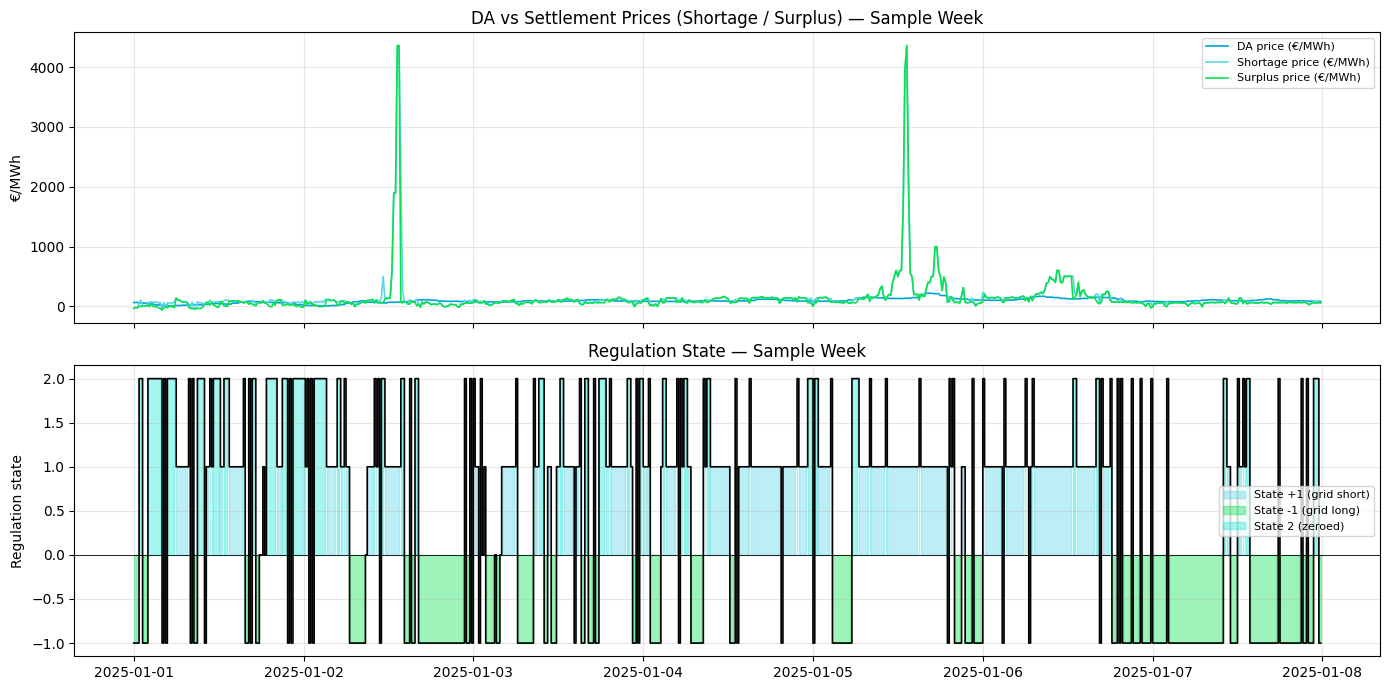

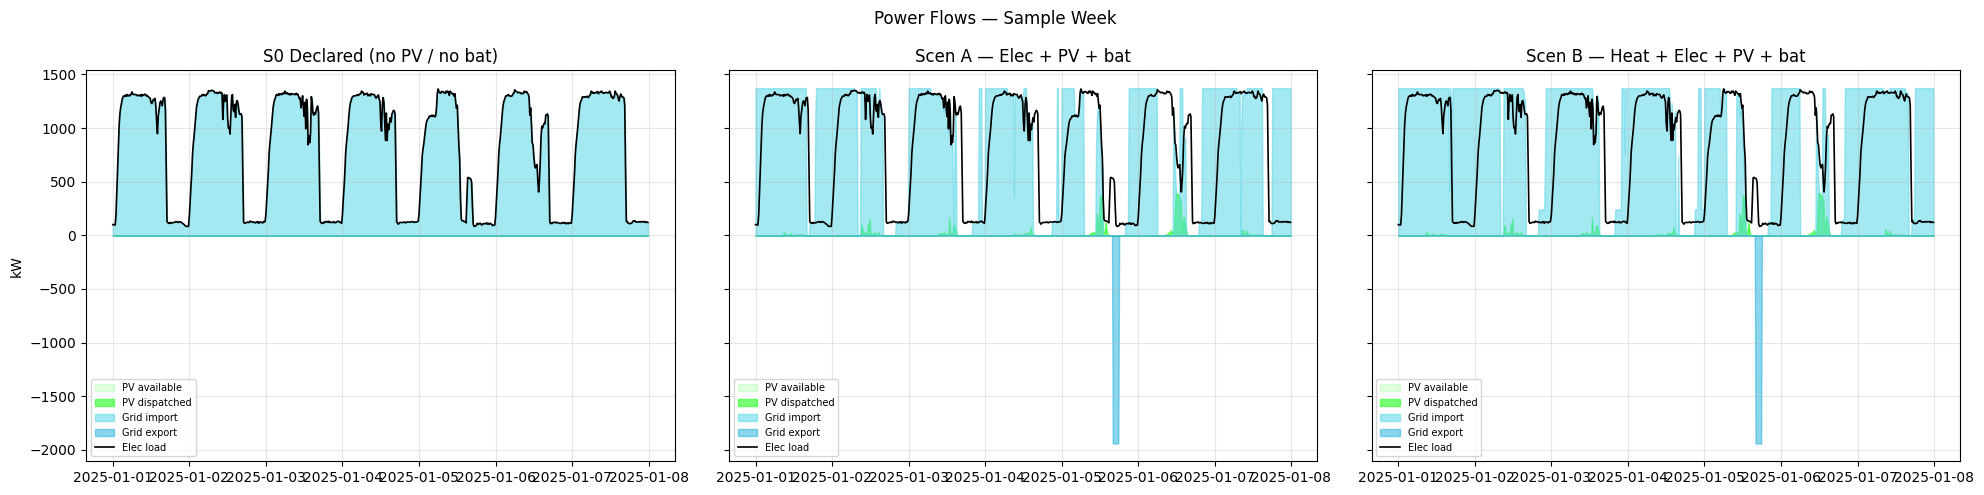

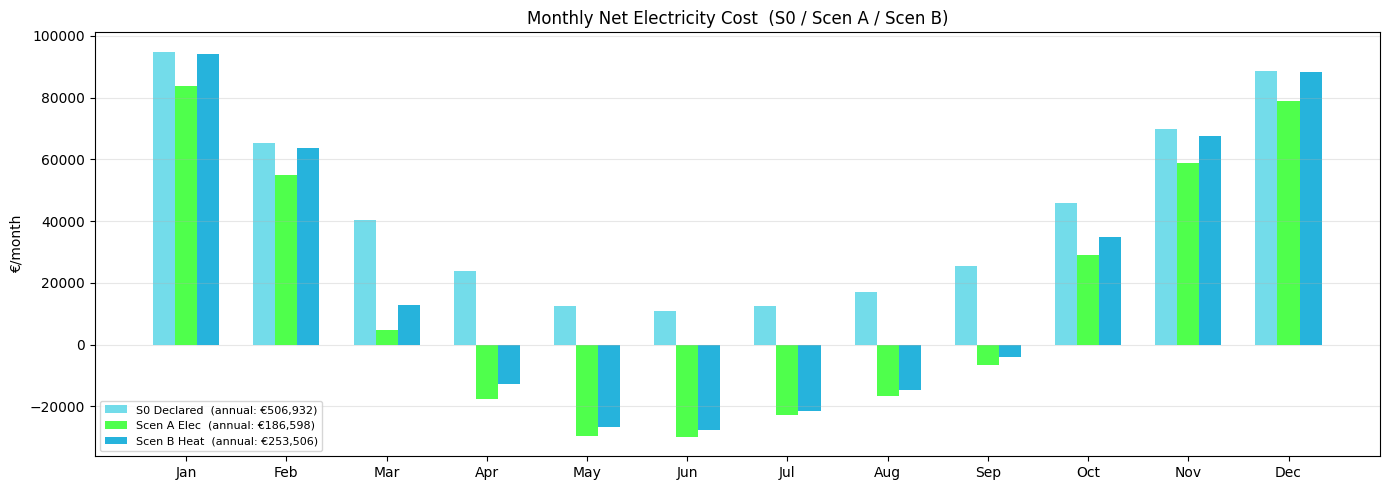

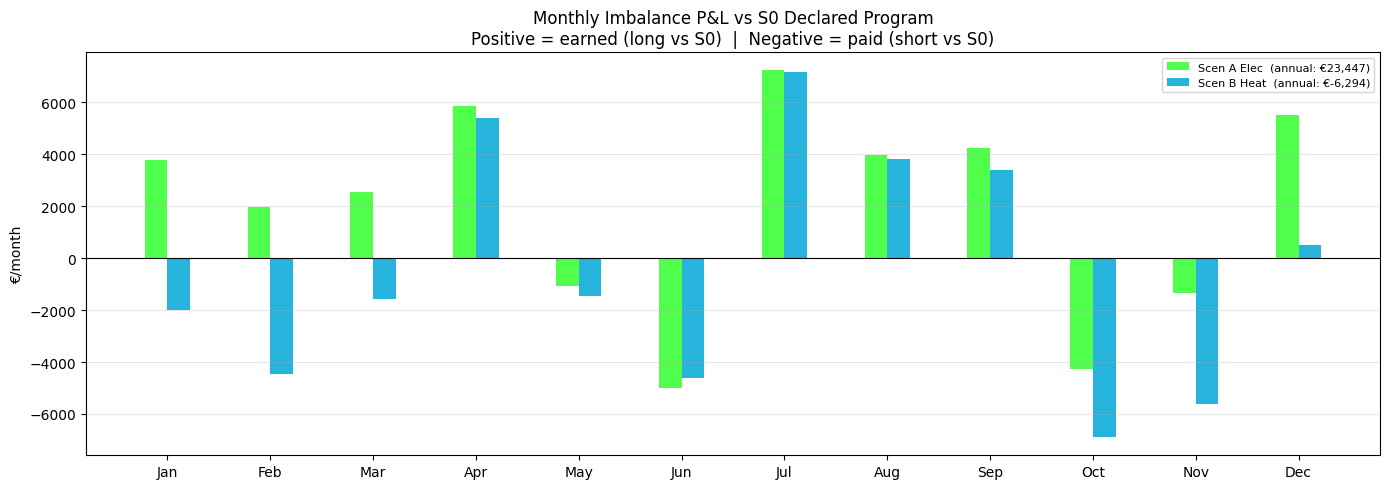

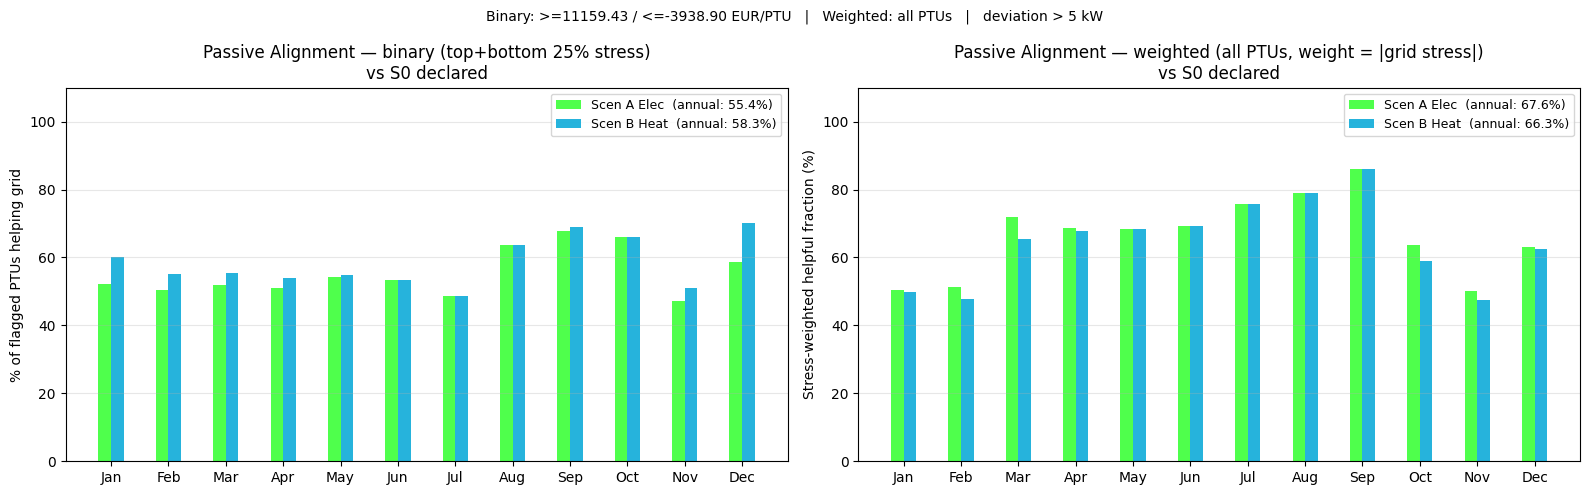

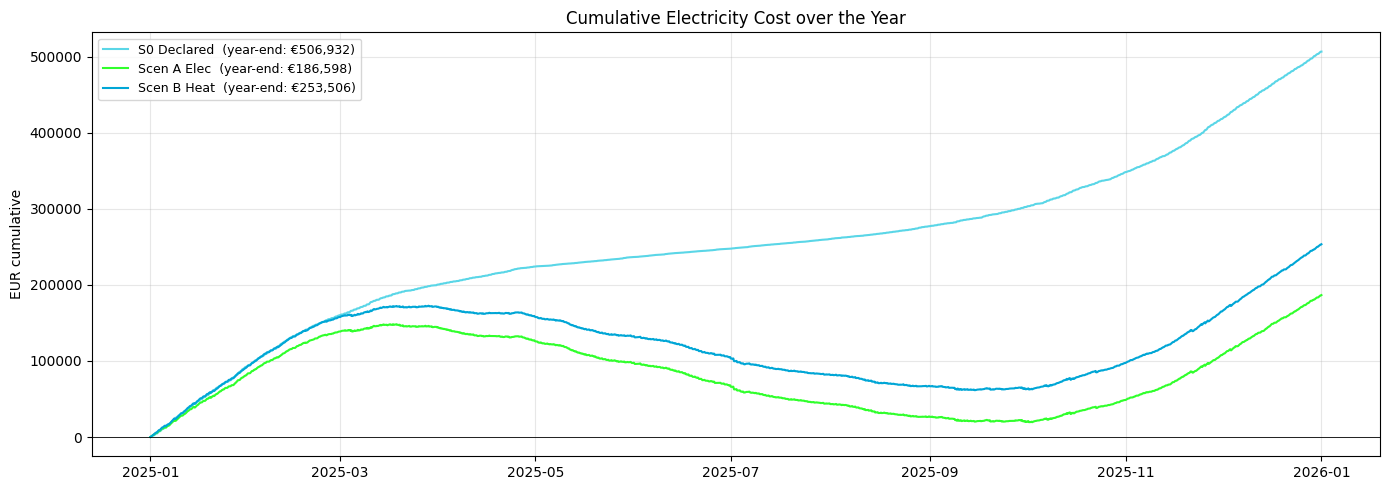

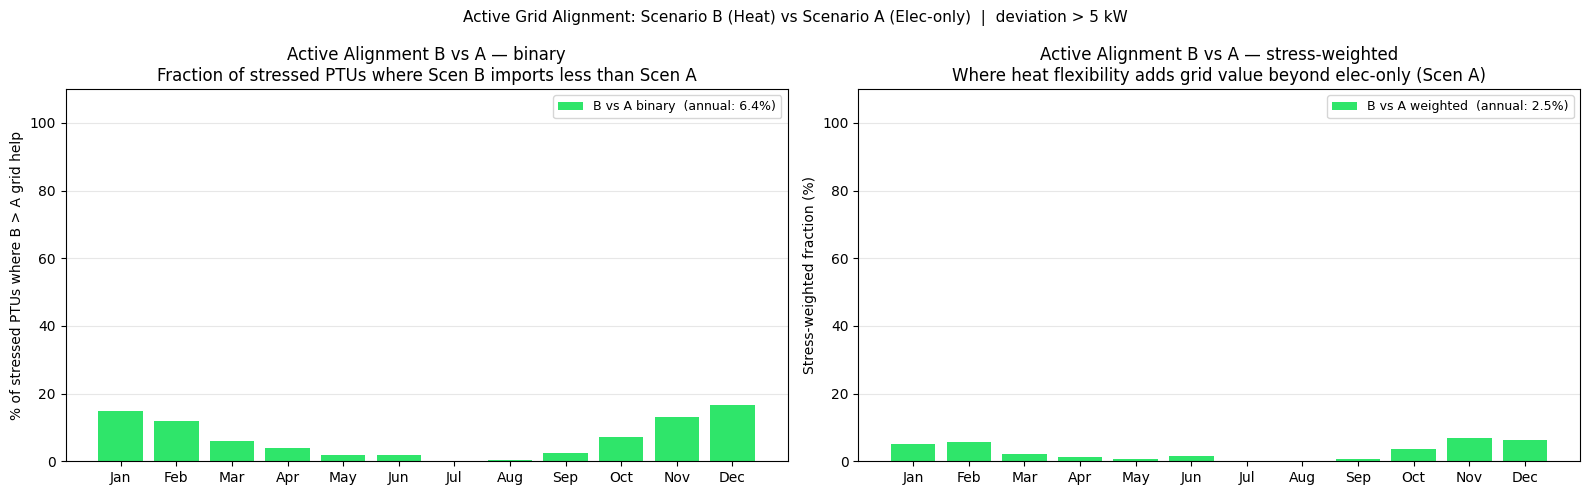

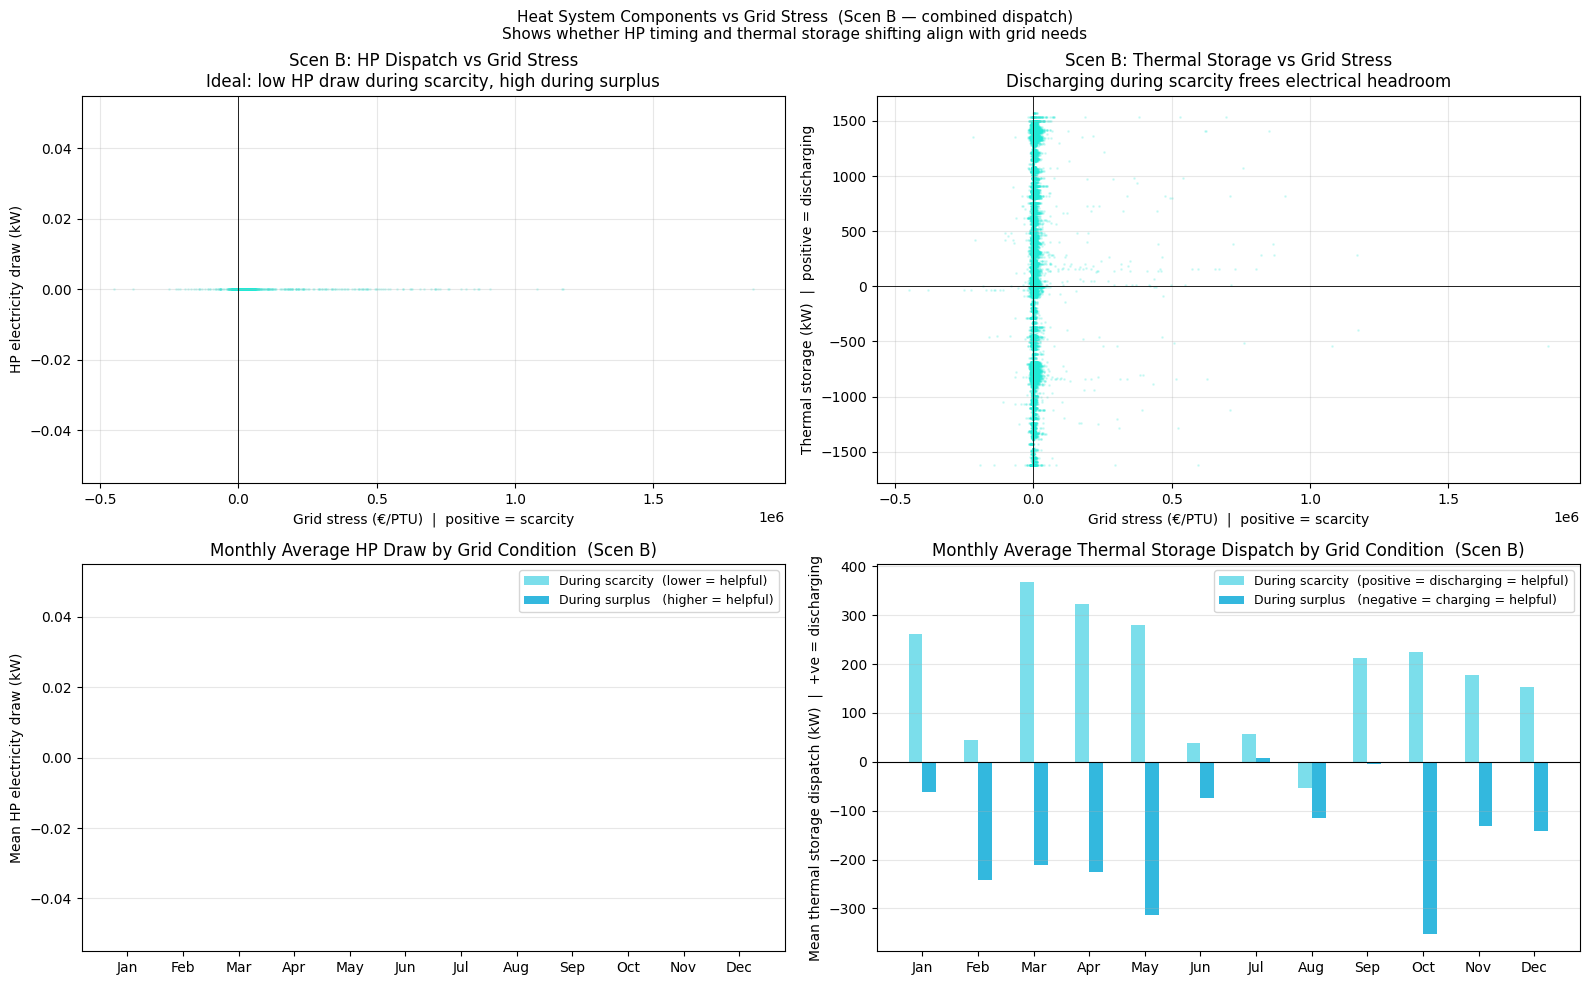

Part II (Grid Alignment Analysis) complete.

╔══ ELECTRICITY (Scen B, 15-min dispatch) ══════════════════════════╗
║  PV production    :     1,447 MWh_e                         ║
║  PV curtailment   :       4.8 MWh_e  (0.3%)                  ║
║  Grid import      :     4,180 MWh_e                         ║
║  Grid export      :     1,674 MWh_e                         ║
║    PV direct→grid :       144 MWh_e  €  15,419/yr        ║
║    PV via battery :       650 MWh_e  €  89,753/yr        ║
║    Grid via batt. :       879 MWh_e  € 127,680/yr        ║
║  Battery charged  :     3,213 MWh_e                         ║
║  Battery dischgd  :     3,052 MWh_e                         ║
║  Battery cycles/yr:       238                                ║
║  Heat pump        :         0 MWh_e                         ║
║  Geothermal aux   :       511 MWh_e                         ║
║  SC simple (PV absorbed locally) :    91.7%                       ║
║  SC load-only (PV to load)       :    41.6%         

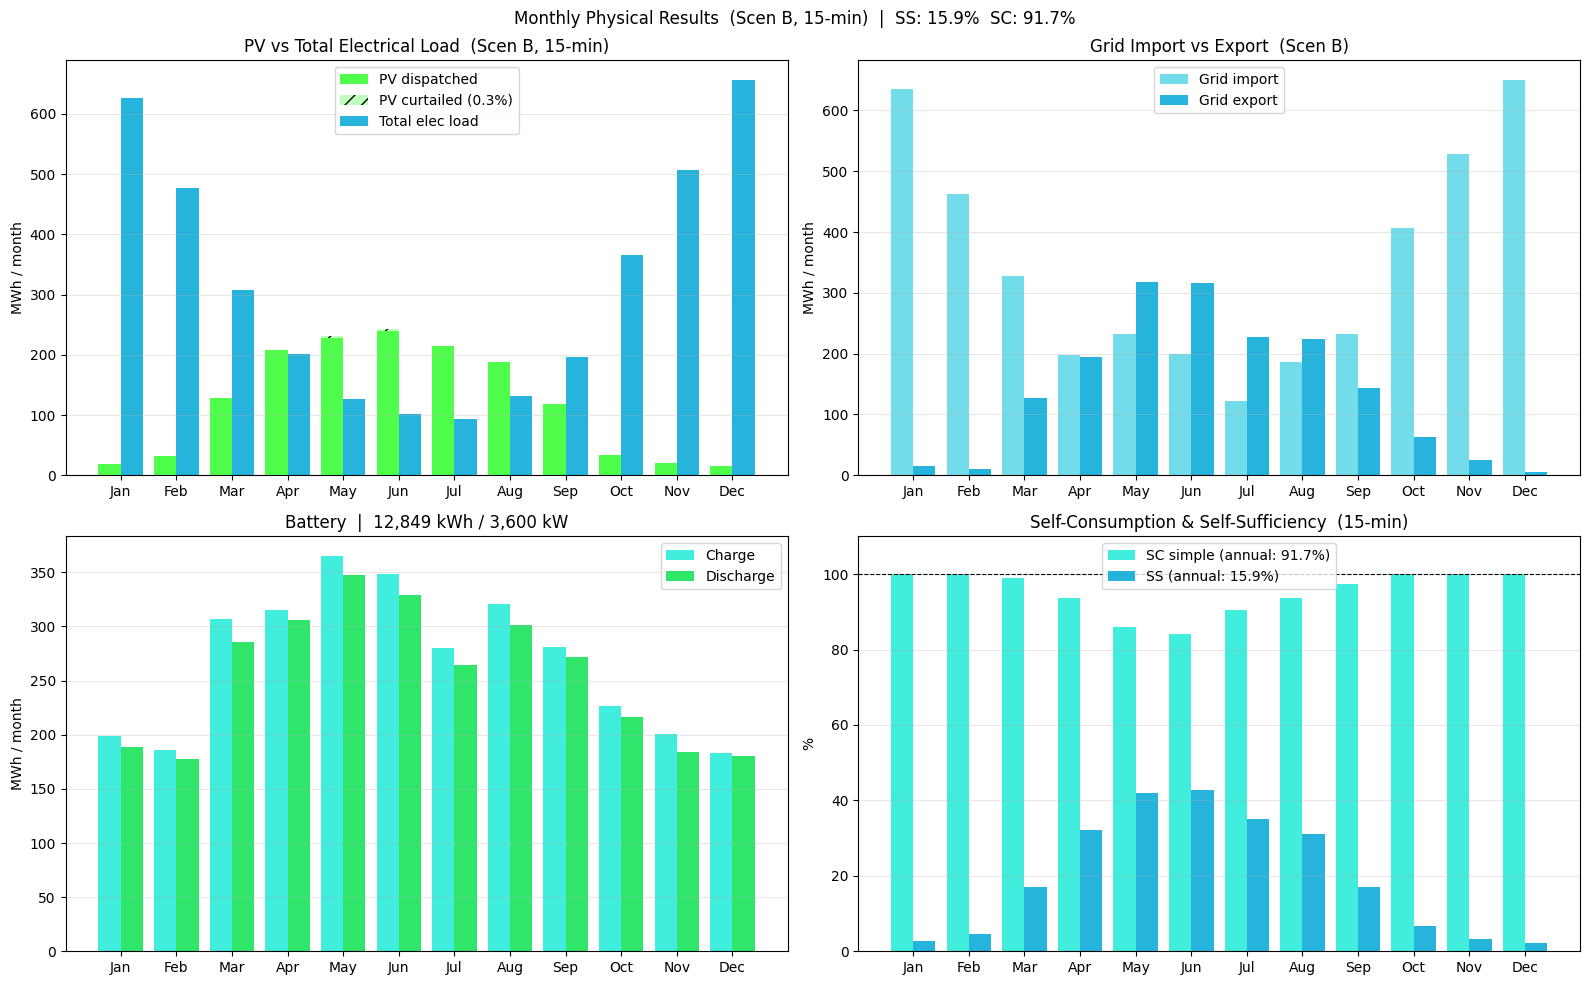

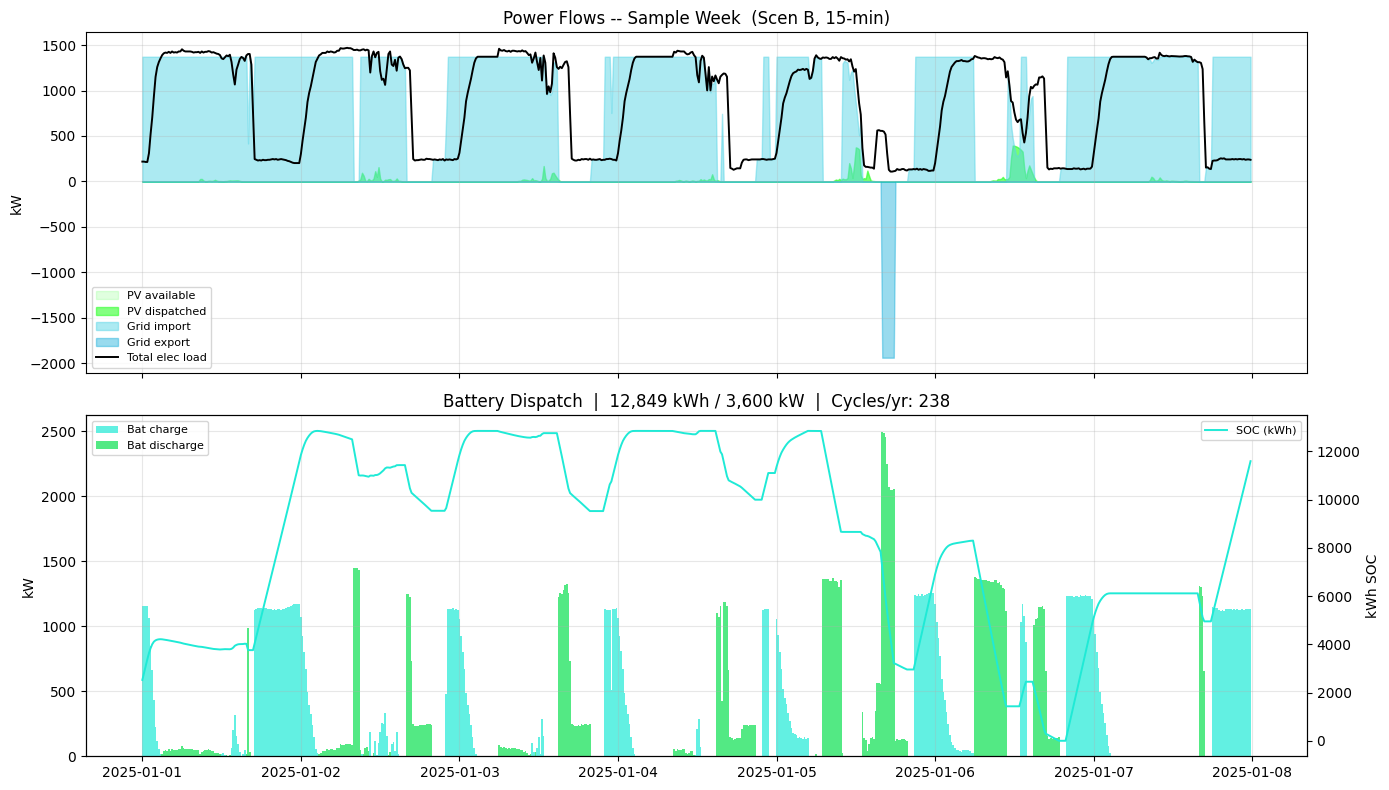

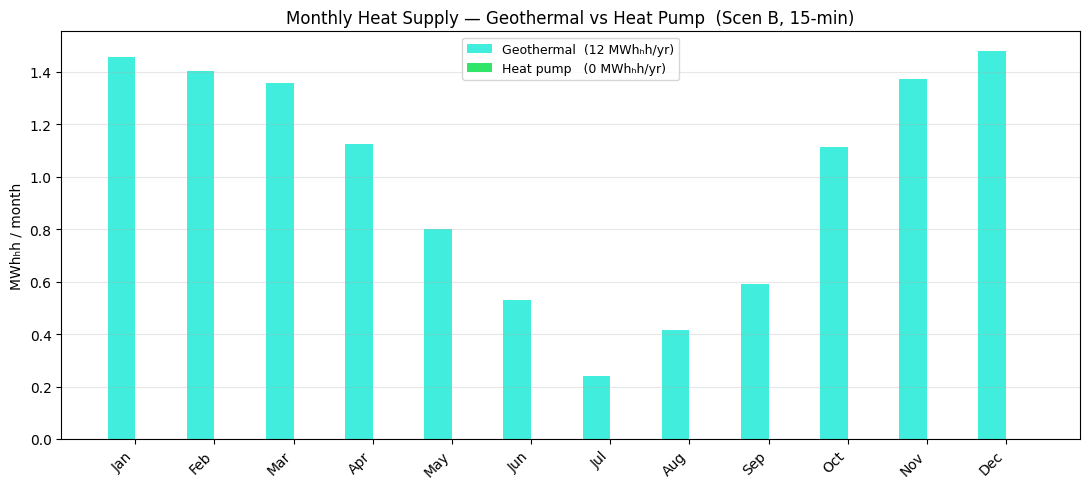

Physical dispatch analysis complete (Scen B, 15-min).


In [102]:
# ════════════════════════════════════════════════════════════════════════════
# PART II  —  GRID ALIGNMENT ANALYSIS  (Combined Heat + Electricity)
# ════════════════════════════════════════════════════════════════════════════
# Requires Part I (cell above) to have run first.
#
# Three scenarios:
#   S0 declared  No optimisation — grid_import = load_kw (baseline / declared program)
#   Scen A elec  Elec + PV + battery  (eo_bat_e_kwh / eo_bat_p_kw from n_elec)
#   Scen B heat  Heat + Elec + PV + battery  (bat_e_kwh, bat_p_kw, hp_p_nom_e,
#                ts_p_nom_kw from n_comb)
#
# Passive alignment (A, B vs S0): fraction of top-25% stress PTUs where scenario
#   reduces grid import vs S0.
# Active alignment (B vs A): how much more B aligns with grid than A.
# Imbalance P&L: deviation from S0 declared, settled at TenneT prices.
# ════════════════════════════════════════════════════════════════════════════

# ─── IMBALANCE CONFIGURATION ─────────────────────────────────────────────────

COL_SHORTAGE_PRICE   = "Price Shortage  (EUR/MWh)"
COL_SURPLUS_PRICE    = "Price Surplus  (EUR/MWh)"
COL_REGULATION_STATE = "Regulation State"

STRESS_ALIGN_QUANTILE = 0.75    # top/bottom fraction: 0.75 = top+bottom 25%
RESPONSE_THRESHOLD_KW = 5.0     # kW — min deviation to count as "responding"

# ─── LOAD IMBALANCE DATA & DERIVE GRID STRESS ────────────────────────────────

shortage_price   = df[COL_SHORTAGE_PRICE].fillna(0)  / 1000 if COL_SHORTAGE_PRICE   in df.columns else pd.Series(0.0, index=df.index)
surplus_price    = df[COL_SURPLUS_PRICE].fillna(0)   / 1000 if COL_SURPLUS_PRICE    in df.columns else pd.Series(0.0, index=df.index)
regulation_state = df[COL_REGULATION_STATE].fillna(0).astype(int) if COL_REGULATION_STATE in df.columns else pd.Series(0, index=df.index)

imb_volume_kwh = df[COL_IMBALANCE_VOL].fillna(0)

direction = regulation_state.map({1: 1, -1: -1, 0: 0, 2: 0}).astype(float)

price_severity = pd.Series(0.0, index=df.index)
price_severity[regulation_state == 1]  = shortage_price[regulation_state == 1]
price_severity[regulation_state == -1] = surplus_price[regulation_state == -1].abs()

grid_stress = direction * price_severity * imb_volume_kwh.abs()

_pos_gs   = grid_stress[grid_stress > 0]
_neg_gs   = grid_stress[grid_stress < 0]
_scar_thr = float(_pos_gs.quantile(STRESS_ALIGN_QUANTILE)) if len(_pos_gs) >= 4 else  float('inf')
_surp_thr = float(_neg_gs.quantile(1 - STRESS_ALIGN_QUANTILE)) if len(_neg_gs) >= 4 else -float('inf')

_has_imb = bool((shortage_price != 0).any() or (surplus_price != 0).any())
_has_vol = bool((imb_volume_kwh  >  0).any())

print("=== IMBALANCE DATA STATUS ===")
print(f"  Settlement prices : {'loaded' if _has_imb else 'EMPTY — fill Excel columns before running Part II'}")
print(f"  Imbalance volume  : {'loaded' if _has_vol else 'EMPTY — fill Excel column'}")
if _has_imb:
    state_counts = regulation_state.value_counts().sort_index()
    print(f"  Regulation states : {dict(state_counts)}")
    state2_pct = (regulation_state == 2).mean() * 100
    print(f"  State 2 (zeroed)  : {state2_pct:.1f}% of PTUs")
if _has_vol:
    print(f"  Grid stress range : {grid_stress.min():.4f} – {grid_stress.max():.4f}")
    _sig_all = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    print(f"  Scarcity thr (75th pct of +ve): {_scar_thr:.4f}")
    print(f"  Surplus  thr (25th pct of -ve): {_surp_thr:.4f}")
    print(f"  Flagged PTUs : {_sig_all.sum()} / {len(grid_stress)} = {_sig_all.mean()*100:.1f}%")
print()

# ─── FIXED CAPACITIES AND OUTAGE PROFILES FROM CELL 1 ────────────────────────
# n_comb is HOURLY (Cell 1 resamples to 'h' before storing).
# Dispatch networks run at 15-min (df.index). Reindex via ffill so outage
# windows cover all four 15-min slots inside each hour.
_snaps_15m  = df.index
_geo_max_pu = (n_comb.links_t.p_max_pu["geothermal"].reindex(_snaps_15m, method="ffill")
               if "geothermal" in n_comb.links_t.p_max_pu.columns
               else pd.Series(1.0, index=_snaps_15m))
_geo_min_pu = (n_comb.links_t.p_min_pu["geothermal"].reindex(_snaps_15m, method="ffill")
               if "geothermal" in n_comb.links_t.p_min_pu.columns
               else pd.Series(GEO_MIN_LOAD, index=_snaps_15m))
_hp_max_pu  = (n_comb.links_t.p_max_pu["heat_pump"].reindex(_snaps_15m, method="ffill")
               if "heat_pump"  in n_comb.links_t.p_max_pu.columns
               else pd.Series(1.0, index=_snaps_15m))

# Battery dispatch max_pu: OUTAGE_WEEKS scheduled in the lowest mean-load month
_bat_outage_steps = int(OUTAGE_WEEKS * 7 * 24 / DT)
_monthly_load     = load_kw.resample("MS").mean()
_lowest_month     = _monthly_load.idxmin()
_bat_max_pu_disp  = pd.Series(1.0, index=_snaps_15m)
_lo_mo_idxs       = _snaps_15m[(_snaps_15m.month == _lowest_month.month) &
                                (_snaps_15m.year  == _lowest_month.year)]
_bat_max_pu_disp.loc[_lo_mo_idxs[:_bat_outage_steps]] = 0.0
print(f"  Battery outage    : {_bat_outage_steps} steps ({OUTAGE_WEEKS:.1f} wks) starting {_lo_mo_idxs[0].strftime('%Y-%m-%d')} (lowest-load month: {_lowest_month.strftime('%B')})")

_hp_cap_kw_th = hp_p_nom_e * HP_COP_ANNUAL_AVG
_ts_e_mwh     = ts_p_nom_kw * _ts_max_h / 1e3

print("Fixed capacities for dispatch scenarios:")
print(f"  Scen A — Elec-only battery : {eo_bat_e_kwh:,.0f} kWh / {eo_bat_p_kw:,.0f} kW  (n_elec)")
print(f"  Scen B — Combined battery  : {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  (n_comb)")
print(f"  Scen B — Heat pump         : {hp_p_nom_e:,.1f} kW_e  ({_hp_cap_kw_th:.1f} kW_th)")
print(f"  Scen B — Thermal storage   : {ts_p_nom_kw:,.1f} kW  ({_ts_e_mwh:.1f} MWh)")
print(f"  Both   — Geo               : {GEO_TARGET_MW*1e3:.0f} kW_th fixed  (min {GEO_MIN_LOAD*100:.0f}%)")
print(f"  Both   — PV                : {_PV_NOM_KW:,.0f} kW_p  (fixed)")
print()


# ════════════════════════════════════════════════════════════════════════════
# DISPATCH SCENARIO FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

def _build_elec_dispatch_network(include_battery=True, include_pv=True):
    """Elec-only dispatch: PV + battery, no heat. Uses eo_bat_e_kwh / eo_bat_p_kw."""
    n = pypsa.Network()
    n.set_snapshots(df.index)
    n.snapshot_weightings.loc[:, :] = DT
    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    if include_pv:
        n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0)
        n.generators_t.p_max_pu["pv"] = _PV_PU
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = load_kw
    n.add("Generator", "grid_import", bus="elec", p_nom=_P_IMPORT_ELEC, marginal_cost=0)
    n.generators_t.marginal_cost["grid_import"] = import_price
    n.add("Generator", "grid_export", bus="elec", p_nom=_P_EXPORT_NOM,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0)
    n.generators_t.marginal_cost["grid_export"] = da_price
    if include_battery:
        _add_battery(n, extendable=False, bat_e=eo_bat_e_kwh, bat_p=eo_bat_p_kw,
                     max_pu=_bat_max_pu_disp)
    n.sanitize()
    return n


def _add_dac_dispatch(n):
    """Add DAC components to a dispatch network with fixed capacities from n_comb."""
    d   = DAC_2030
    a   = d['elec_in_MWh_per_tCO2']
    b   = d['heat_in_MWh_per_tCO2']
    g   = d['heat_out_MWh_per_tCO2']
    dac_p_nom  = float(n_comb.links.p_nom_opt['dac'])
    whr_p_nom  = float(n_comb.links.p_nom_opt['waste_heat_recovery'])
    bst_p_nom  = float(n_comb.links.p_nom_opt['heat_booster'])
    tank_e_nom = max(float(n_comb.stores.at['co2_tank', 'e_nom_opt']), 1.0)
    n.add('Carrier', 'co2');  n.add('Carrier', 'heat_low');  n.add('Carrier', 'heat_high')
    n.add('Bus', 'dac_co2',  carrier='co2')
    n.add('Bus', 'heat_low', carrier='heat_low')
    n.add('Bus', 'heat_high',carrier='heat_high')
    annual_tco2 = CO2_DEMAND['annual_tCO2_per_ha'] * CO2_DEMAND['hectares']
    co2_prof = _co2_demand_profile(
        _PV_PU, df.index, annual_tco2,
        CO2_DEMAND['profile_source'], CO2_DEMAND['latitude_deg'])
    n.add('Load', 'co2_demand', bus='dac_co2')
    n.loads_t.p_set['co2_demand'] = co2_prof
    n.add('Generator', 'heat_low_vent', bus='heat_low',
          p_nom=1e6, p_min_pu=-1, p_max_pu=0, marginal_cost=0.0)
    _off_steps = int(d['planned_outage_weeks'] * 7 * 24 / DT)
    dac_pu = pd.Series(1.0 - d['forced_outage_frac'], index=df.index)
    dac_pu.iloc[:_off_steps] = 0.0
    n.add('Link', 'dac',
          bus0='elec', bus1='dac_co2', bus2='heat_high', bus3='heat_low',
          p_nom=dac_p_nom, p_nom_extendable=False,
          efficiency  =  1.0 / (a * 1000),
          efficiency2 = -b   / a,
          efficiency3 =  g   / a,
          marginal_cost=d['vom_eur_per_tCO2'] * a)
    n.links_t.p_max_pu['dac'] = dac_pu
    whr = WASTE_HEAT_RECOVERY['cop']
    n.add('Link', 'waste_heat_recovery',
          bus0='elec', bus1='heat', bus2='heat_low',
          p_nom=whr_p_nom, p_nom_extendable=False,
          efficiency  =  whr,
          efficiency2 = -(whr - 1),
          marginal_cost=0.0)
    _booster_cop = WASTE_HEAT_RECOVERY.get('booster_cop', HP_COP_ANNUAL_AVG)
    n.add('Link', 'heat_booster',
          bus0='elec', bus1='heat_high', bus2='heat',
          p_nom=bst_p_nom, p_nom_extendable=False,
          efficiency  =  _booster_cop,
          efficiency2 = -(_booster_cop - 1),
          marginal_cost=_hp_mc)
    parasitic_MW = TERMINAL_REF['energy_kWh_per_tCO2_per_day'] * tank_e_nom / 24 / 1e3
    n.add('Store', 'co2_tank', bus='dac_co2',
          e_nom=tank_e_nom, e_nom_extendable=False,
          e_cyclic=True, standing_loss=0.0, marginal_cost=0.0)
    n.add('Load', 'co2_tank_refrigeration', bus='elec')
    n.loads_t.p_set['co2_tank_refrigeration'] = pd.Series(parasitic_MW, index=df.index)


def _hp_dispatch_ef(n, snapshots):
    """HP + WHR + booster cannot exceed HP p_nom at any timestep."""
    required = {'heat_pump', 'waste_heat_recovery', 'heat_booster'}
    if not required.issubset(n.links.index):
        return
    m = n.model
    if "Link-p" not in m.variables:
        return
    p = m.variables['Link-p']
    p_dim = [d for d in p.dims if d != 'snapshot'][0]
    link_vals = list(p.coords[p_dim].values)
    if not all(lk in link_vals for lk in ['heat_pump', 'waste_heat_recovery', 'heat_booster']):
        return
    hp_cap = float(n.links.at['heat_pump', 'p_nom'])
    p_sum  = (p.sel({p_dim: 'heat_pump'}) +
              p.sel({p_dim: 'waste_heat_recovery'}) +
              p.sel({p_dim: 'heat_booster'}))
    n.model.add_constraints(p_sum <= hp_cap, name='hp_shared_cap')


def _build_combined_dispatch_network(include_battery=True, include_pv=True, participation_weight=0.0):
    """Combined dispatch: PV + battery + HP + geo + thermal storage.
    Uses bat_e_kwh, bat_p_kw, hp_p_nom_e, ts_p_nom_kw from Cell 1."""
    n = pypsa.Network()
    n.set_snapshots(df.index)
    n.snapshot_weightings.loc[:, :] = DT
    n.add("Carrier", "electricity")
    n.add("Bus", "elec", carrier="electricity")
    if include_pv:
        n.add("Generator", "pv", bus="elec", p_nom=_PV_NOM_KW, marginal_cost=0)
        n.generators_t.p_max_pu["pv"] = _PV_PU
    n.add("Load", "elec_load", bus="elec")
    n.loads_t.p_set["elec_load"] = load_kw
    n.add("Generator", "grid_import", bus="elec", p_nom=_P_IMPORT_ELEC, marginal_cost=0)
    n.generators_t.marginal_cost["grid_import"] = import_price
    n.add("Generator", "grid_export", bus="elec", p_nom=_P_EXPORT_NOM,
          p_min_pu=-1, p_max_pu=0, marginal_cost=0)
    n.generators_t.marginal_cost["grid_export"] = da_price
    if include_battery:
        _add_battery(n, extendable=False, bat_e=bat_e_kwh, bat_p=bat_p_kw,
                     max_pu=_bat_max_pu_disp)
    n.add("Carrier", "heat")
    n.add("Bus", "heat", carrier="heat")
    _hp_p_nom = max(float(hp_p_nom_e), 0.0)
    n.add("Link", "heat_pump",
          bus0="elec", bus1="heat",
          p_nom=_hp_p_nom,
          efficiency=HP_COP_ANNUAL_AVG,
          marginal_cost=_hp_mc)
    n.links_t.p_max_pu["heat_pump"] = _hp_max_pu
    geo_p_nom_e = GEO_TARGET_MW * 1e3 * GEO_AUX_ELEC_FRAC
    n.add("Link", "geothermal",
          bus0="elec", bus1="heat",
          p_nom=geo_p_nom_e,
          efficiency=1.0 / GEO_AUX_ELEC_FRAC,
          p_min_pu=0.0,
          marginal_cost=_geo_mc)
    n.links_t.p_max_pu["geothermal"] = _geo_max_pu
    n.links_t.p_min_pu["geothermal"] = _geo_min_pu
    n.add("StorageUnit", "heat_storage",
          bus="heat",
          p_nom=ts_p_nom_kw, p_nom_extendable=False,
          max_hours=_ts_max_h,
          efficiency_store=1.0, efficiency_dispatch=1.0,
          standing_loss=TS_LOSS_PER_HOUR,
          cyclic_state_of_charge=True,
          marginal_cost=0.0)
    # Absorb excess heat. p_max_pu=0 → can only absorb. Negative MC makes
    # absorption a cost in the objective (p<0, mc<0 → p*mc > 0).
    n.add("Generator", "heat_curtail",
          bus="heat",
          p_nom=float(heat_load_mw.max() * 1e3) + GEO_TARGET_MW * 1e3,
          p_min_pu=-1.0, p_max_pu=0.0,
          marginal_cost=-_curtail_mc)
    n.add("Generator", "heat_supply_slack",
          bus="heat",
          p_nom=float(heat_load_mw.max() * 1e3),
          p_min_pu=0.0, p_max_pu=1.0,
          marginal_cost=_curtail_mc * 10)
    n.add("Load", "heat_load", bus="heat")
    n.loads_t.p_set["heat_load"] = heat_load_mw * 1e3
    if DAC_CONFIG.get('add_dac', False):
        _add_dac_dispatch(n)
    n.sanitize()
    return n


def _extract_dispatch(n):
    _zeros   = pd.Series(0.0, index=n.snapshots)
    _gp      = n.generators_t.p
    _lp0     = n.links_t.p0
    _lp1     = n.links_t.p1
    _has_bat = "battery_store" in n.stores_t.e.columns
    _has_ts  = "heat_storage"  in n.storage_units_t.p.columns
    _pv_p    = _gp["pv"] if "pv" in _gp.columns else _zeros
    return pd.DataFrame({
        "pv":            _pv_p,
        "pv_curtailed":  ((_PV_PU.reindex(n.snapshots) * _PV_NOM_KW) - _pv_p).clip(lower=0),
        "load":          n.loads_t.p_set["elec_load"],
        "grid_import":   _gp["grid_import"] if "grid_import" in _gp.columns else _zeros,
        "grid_export":   -_gp["grid_export"] if "grid_export" in _gp.columns else _zeros,
        "bat_charge":    _lp0["bat_charge"]       if _has_bat and "bat_charge"    in _lp0.columns else _zeros,
        "bat_discharge": -_lp1["bat_discharge"]   if _has_bat and "bat_discharge" in _lp1.columns else _zeros,
        "bat_soc":       n.stores_t.e["battery_store"]              if _has_bat else _zeros,
        "hp_elec":       _lp0["heat_pump"]  if "heat_pump"  in _lp0.columns else _zeros,
        "geo_elec":      _lp0["geothermal"] if "geothermal" in _lp0.columns else _zeros,
        "dac_elec":      _lp0["dac"]        if "dac"        in _lp0.columns else _zeros,
        "ts_dispatch":   n.storage_units_t.p["heat_storage"]            if _has_ts else _zeros,
        "ts_soc":        n.storage_units_t.state_of_charge["heat_storage"] if _has_ts else _zeros,
        "heat_curtail":  (-_gp["heat_curtail"] if "heat_curtail" in _gp.columns else _zeros),
    }, index=n.snapshots)


def _pv_ss_flows(pv_kw, gi_kw, ge_kw, bc_kw, bd_kw, soc_kwh, load_kw, dt=None):
    """PV self-sufficiency via proportional bus-flow allocation."""
    dt = dt if dt is not None else DT_H
    pv_arr = pv_kw.values;  gi_arr = gi_kw.values;  ge_arr = ge_kw.values
    bc_arr = bc_kw.values;  bd_arr = bd_kw.values;  soc_arr = soc_kwh.values
    lk_arr = load_kw.values
    pv_to_load = 0.0;  pv_in_bat = 0.0;  prev_soc = 0.0
    for t in range(len(pv_arr)):
        pv = pv_arr[t]; gi = gi_arr[t]; ge = ge_arr[t]
        bc = bc_arr[t]; bd = bd_arr[t]; soc_end = soc_arr[t]; lk = lk_arr[t]
        total_supply = pv + gi + bd
        total_demand = lk + bc + ge
        if total_supply < 1e-9 or total_demand < 1e-9:
            prev_soc = soc_end;  continue
        bat_pv_frac = min(pv_in_bat / prev_soc, 1.0) if prev_soc > 0 else 0.0
        pv_origin = pv + bd * bat_pv_frac
        pv_to_load += pv_origin * (lk / total_demand) * dt
        if bc > 0:
            pv_in_bat += (pv / total_supply) * bc * BATTERY_EFFICIENCY_STORE * dt
        if bd > 0 and prev_soc > 0:
            pv_in_bat = max(pv_in_bat - bat_pv_frac * (bd / BATTERY_EFFICIENCY_DISPATCH) * dt, 0.0)
        pv_in_bat = min(pv_in_bat, soc_end);  prev_soc = soc_end
    total_load_kwh = float((load_kw * dt).sum())
    total_pv_kwh   = float((pv_kw  * dt).sum())
    ss      = (pv_to_load / total_load_kwh * 100) if total_load_kwh > 0 else 0.0
    sc_load = (pv_to_load / total_pv_kwh  * 100) if total_pv_kwh  > 0 else 0.0
    return ss, sc_load


def _compute_ss(res_df):
    total_consumed = res_df["load"] + res_df["hp_elec"] + res_df["geo_elec"]
    ss, _ = _pv_ss_flows(
        res_df["pv"], res_df["grid_import"], res_df["grid_export"],
        res_df["bat_charge"], res_df["bat_discharge"], res_df["bat_soc"],
        total_consumed, dt=DT)
    return ss


def _compute_ss_simple(res_df):
    total_consumed = res_df["load"] + res_df["hp_elec"] + res_df["geo_elec"]
    total_load = float((total_consumed * DT).sum())
    if total_load < 1e-9:
        return 0.0
    direct = (res_df["pv"].clip(upper=total_consumed) * DT).sum()
    return float(direct) / total_load * 100


def _compute_sc_load(res_df):
    total_consumed = res_df["load"] + res_df["hp_elec"] + res_df["geo_elec"]
    _, sc = _pv_ss_flows(
        res_df["pv"], res_df["grid_import"], res_df["grid_export"],
        res_df["bat_charge"], res_df["bat_discharge"], res_df["bat_soc"],
        total_consumed, dt=DT)
    return sc


def _compute_sc_simple(res_df):
    total_pv = float((res_df["pv"] * DT).sum())
    if total_pv < 1e-9:
        return 0.0
    total_consumed = res_df["load"] + res_df["hp_elec"] + res_df["geo_elec"]
    local = (res_df["pv"].clip(upper=(total_consumed + res_df["bat_charge"])) * DT).sum()
    return float(local) / total_pv * 100


def _calc_imb_pnl(scenario_import_kw, declared_import_kw):
    """Imbalance P&L vs declared program (positive = revenue, negative = cost)."""
    dev_kw = declared_import_kw - scenario_import_kw
    return dev_kw.clip(lower=0) * surplus_price * DT + dev_kw.clip(upper=0) * shortage_price * DT


def _calc_alignment(scenario_import_kw, baseline_import_kw):
    """Passive binary alignment: fraction of top-stress PTUs where scenario is grid-helpful vs baseline."""
    dev  = scenario_import_kw - baseline_import_kw
    sig  = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    helping = (
        ((grid_stress >= _scar_thr) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress <= _surp_thr) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    n_sig   = sig.sum()
    n_help  = (helping & sig).sum()
    annual  = (n_help / n_sig * 100) if n_sig > 0 else 0.0
    vol_mwh = (dev.abs() * DT / 1000).sum()
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = sig.index.month == _m
        _n_s  = sig[_mask].sum()
        _n_h  = (helping & sig)[_mask].sum()
        monthly[_m] = (_n_h / _n_s * 100) if _n_s > 0 else 0.0
    return annual, monthly, vol_mwh


def _calc_active_alignment(scenario_import_kw, reference_import_kw):
    """Active binary alignment: fraction of stressed PTUs where scenario is MORE grid-helpful than reference."""
    dev  = scenario_import_kw - reference_import_kw
    sig  = (grid_stress >= _scar_thr) | (grid_stress <= _surp_thr)
    helping = (
        ((grid_stress >= _scar_thr) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress <= _surp_thr) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    n_sig  = sig.sum()
    n_help = (helping & sig).sum()
    annual  = (n_help / n_sig * 100) if n_sig > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = sig.index.month == _m
        _n_s  = sig[_mask].sum()
        _n_h  = (helping & sig)[_mask].sum()
        monthly[_m] = (_n_h / _n_s * 100) if _n_s > 0 else 0.0
    return annual, monthly


def _calc_alignment_weighted(scenario_import_kw, baseline_import_kw):
    """Stress-weighted passive alignment: all nonzero-stress PTUs, weight = |grid_stress|."""
    dev        = scenario_import_kw - baseline_import_kw
    stress_abs = grid_stress.abs()
    nonzero    = stress_abs > 0
    helping    = (
        ((grid_stress > 0) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress < 0) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    w_total = stress_abs[nonzero].sum()
    w_help  = stress_abs[nonzero & helping].sum()
    annual  = (w_help / w_total * 100) if w_total > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = nonzero.index.month == _m
        _wt   = stress_abs[nonzero & _mask].sum()
        _wh   = stress_abs[nonzero & helping & _mask].sum()
        monthly[_m] = (_wh / _wt * 100) if _wt > 0 else 0.0
    return annual, monthly


def _calc_active_alignment_weighted(scenario_import_kw, reference_import_kw):
    """Stress-weighted active alignment: scenario vs reference, weight = |grid_stress|."""
    dev        = scenario_import_kw - reference_import_kw
    stress_abs = grid_stress.abs()
    nonzero    = stress_abs > 0
    helping    = (
        ((grid_stress > 0) & (dev < -RESPONSE_THRESHOLD_KW)) |
        ((grid_stress < 0) & (dev >  RESPONSE_THRESHOLD_KW))
    )
    w_total = stress_abs[nonzero].sum()
    w_help  = stress_abs[nonzero & helping].sum()
    annual  = (w_help / w_total * 100) if w_total > 0 else 0.0
    monthly = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mask = nonzero.index.month == _m
        _wt   = stress_abs[nonzero & _mask].sum()
        _wh   = stress_abs[nonzero & helping & _mask].sum()
        monthly[_m] = (_wh / _wt * 100) if _wt > 0 else 0.0
    return annual, monthly


# ════════════════════════════════════════════════════════════════════════════
# RUN SCENARIOS
# ════════════════════════════════════════════════════════════════════════════

# S0 declared — no optimisation, grid supplies all electrical load
_zeros_s0 = pd.Series(0.0, index=df.index)
declared_import_kw = load_kw.copy()
res_S0 = pd.DataFrame({
    "pv": _zeros_s0, "pv_curtailed": _zeros_s0,
    "load": load_kw,
    "grid_import": load_kw,
    "grid_export": _zeros_s0,
    "bat_charge": _zeros_s0, "bat_discharge": _zeros_s0, "bat_soc": _zeros_s0,
    "hp_elec": _zeros_s0, "geo_elec": _zeros_s0, "dac_elec": _zeros_s0,
    "ts_dispatch": _zeros_s0, "ts_soc": _zeros_s0,
    "heat_curtail": _zeros_s0,
}, index=df.index)

print("Running Scenario A — Elec + PV + battery (eo_bat_e_kwh / eo_bat_p_kw) ...")
_n_A = _build_elec_dispatch_network(include_battery=True, include_pv=True)
_st_A, _ = _n_A.optimize(solver_name="highs", log_to_console=False)
if _st_A not in ("ok", "warning"):
    raise RuntimeError(f"Scenario A optimisation failed: {_st_A}")
res_A = _extract_dispatch(_n_A)

print("Running Scenario B — Heat + Elec + PV + battery (combined system) ...")
_n_B = _build_combined_dispatch_network(include_battery=True, include_pv=True)
_st_B, _ = _n_B.optimize(solver_name="highs", log_to_console=False, extra_functionality=_hp_dispatch_ef)
if _st_B not in ("ok", "warning"):
    raise RuntimeError(f"Scenario B optimisation failed: {_st_B}")
res_B = _extract_dispatch(_n_B)
res2  = res_B   # alias for Cell 3 compatibility

print("All dispatch scenarios complete.")
print(f"  S0 grid_import : total={declared_import_kw.sum()*DT/1e3:.1f} MWh/yr  mean={declared_import_kw.mean():.1f} kW")
print(f"  Scen A import  : total={res_A['grid_import'].sum()*DT/1e3:.1f} MWh/yr  pv_mean={res_A['pv'].mean():.1f} kW  bat_chg={res_A['bat_charge'].mean():.1f} kW")
print(f"  Scen B import  : total={res_B['grid_import'].sum()*DT/1e3:.1f} MWh/yr  hp_mean={res_B['hp_elec'].mean():.1f} kW  ts_dis={res_B['ts_dispatch'].mean():.1f} kW")
print()


# ════════════════════════════════════════════════════════════════════════════
# POST-PROCESSING: COSTS, P&L, ALIGNMENT
# ════════════════════════════════════════════════════════════════════════════

def _scenario_net_cost(res_df):
    return ((res_df["grid_import"] * import_price - res_df["grid_export"] * da_price) * DT).sum()

s0_net_cost = _scenario_net_cost(res_S0)
sA_net_cost = _scenario_net_cost(res_A)
sB_net_cost = _scenario_net_cost(res_B)

ss_A     = _compute_ss(res_A)
ss_B     = _compute_ss(res_B)
ss_sim_A = _compute_ss_simple(res_A)
ss_sim_B = _compute_ss_simple(res_B)
sc_sim_A = _compute_sc_simple(res_A)
sc_sim_B = _compute_sc_simple(res_B)
sc_lod_A = _compute_sc_load(res_A)
sc_lod_B = _compute_sc_load(res_B)

# Imbalance P&L vs S0 declared
if _has_vol:
    imb_pnl_A = _calc_imb_pnl(res_A["grid_import"], declared_import_kw)
    imb_pnl_B = _calc_imb_pnl(res_B["grid_import"], declared_import_kw)
    imb_A_eur = float(imb_pnl_A.sum())
    imb_B_eur = float(imb_pnl_B.sum())
else:
    imb_pnl_A = imb_pnl_B = pd.Series(0.0, index=df.index)
    imb_A_eur = imb_B_eur = 0.0

# Passive alignment vs S0 declared
if _has_vol:
    alA,  alA_m,  volA = _calc_alignment(res_A["grid_import"], declared_import_kw)
    alB,  alB_m,  volB = _calc_alignment(res_B["grid_import"], declared_import_kw)
    walA, walA_m        = _calc_alignment_weighted(res_A["grid_import"], declared_import_kw)
    walB, walB_m        = _calc_alignment_weighted(res_B["grid_import"], declared_import_kw)
    # Active alignment: B vs A (how much more B aligns than A)
    act_BA,  act_BA_m  = _calc_active_alignment(res_B["grid_import"], res_A["grid_import"])
    wact_BA, wact_BA_m = _calc_active_alignment_weighted(res_B["grid_import"], res_A["grid_import"])
else:
    alA = alB = volA = volB = walA = walB = 0.0
    act_BA = wact_BA = 0.0
    alA_m = alB_m = walA_m = walB_m = pd.Series(0.0, index=range(1, 13))
    act_BA_m = wact_BA_m = pd.Series(0.0, index=range(1, 13))


# ════════════════════════════════════════════════════════════════════════════
# MONTHLY BREAKDOWN
# ════════════════════════════════════════════════════════════════════════════

def _mg(ts):
    return ts.groupby(ts.index.month).sum()

def _ss_monthly(res_df):
    pv_gen  = res_df["pv"]
    bat_dis = res_df["bat_discharge"].clip(lower=0)
    imp     = res_df["grid_import"]
    total   = (pv_gen + bat_dis + imp).where(lambda x: x > 0, np.nan)
    own_frac = ((pv_gen + bat_dis) / total).fillna(1).clip(0, 1)
    total_consumed = (res_df["load"] + res_df["hp_elec"] + res_df["geo_elec"]) * DT
    lmk = total_consumed.groupby(total_consumed.index.month).sum()
    lfo = total_consumed * own_frac
    return lfo.groupby(lfo.index.month).sum() / lmk * 100

s0_cost_m = _mg(res_S0["grid_import"] * import_price * DT) - _mg(res_S0["grid_export"] * da_price * DT)
sA_cost_m = _mg(res_A["grid_import"]  * import_price * DT) - _mg(res_A["grid_export"]  * da_price * DT)
sB_cost_m = _mg(res_B["grid_import"]  * import_price * DT) - _mg(res_B["grid_export"]  * da_price * DT)

imb_A_m = _mg(imb_pnl_A)
imb_B_m = _mg(imb_pnl_B)

ssA_m = _ss_monthly(res_A)
ssB_m = _ss_monthly(res_B)


# ════════════════════════════════════════════════════════════════════════════
# KPI SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════

W = 78
print("=" * W)
print(f"  {'KPI':<38} {'S0 declared':>11} {'Scen A elec':>11} {'Scen B heat':>11}")
print("=" * W)
print(f"  {'Net electricity cost (€/yr)':<38} {s0_net_cost:>11,.0f} {sA_net_cost:>11,.0f} {sB_net_cost:>11,.0f}")
print("-" * W)
print(f"  {'Self-sufficiency simple (%)':<38} {'—':>11} {ss_sim_A:>10.1f}% {ss_sim_B:>10.1f}%")
print(f"  {'Self-sufficiency load-only (%)':<38} {'—':>11} {ss_A:>10.1f}% {ss_B:>10.1f}%")
print("-" * W)
print(f"  {'Self-consumption simple (%)':<38} {'—':>11} {sc_sim_A:>10.1f}% {sc_sim_B:>10.1f}%")
print(f"  {'Self-consumption load-only (%)':<38} {'—':>11} {sc_lod_A:>10.1f}% {sc_lod_B:>10.1f}%")
if _has_vol:
    print("-" * W)
    print(f"  {'Imbalance P&L vs S0 declared (€/yr)':<38} {'—':>11} {imb_A_eur:>11,.0f} {imb_B_eur:>11,.0f}")
    print(f"  {'Passive align — binary top25% (%)':<38} {'—':>11} {alA:>10.1f}% {alB:>10.1f}%")
    print(f"  {'Passive align — weighted all (%)':<38} {'—':>11} {walA:>10.1f}% {walB:>10.1f}%")
    print(f"  {'Active align B vs A — binary (%)':<38} {'—':>11} {'—':>11} {act_BA:>10.1f}%")
    print(f"  {'Active align B vs A — weighted (%)':<38} {'—':>11} {'—':>11} {wact_BA:>10.1f}%")
    print(f"  {'Deviation from S0 (MWh/yr)':<38} {'—':>11} {volA:>11.1f} {volB:>11.1f}")
print("=" * W)
print()

print("=== MONTHLY BREAKDOWN ===")
print(f"{'Month':<6} {'S0 cost €':>10} {'A cost €':>10} {'B cost €':>10} {'A SS%':>7} {'B SS%':>7}")
print("-" * 56)
for i, m in enumerate(MONTHS, 1):
    print(f"{m:<6} {s0_cost_m[i]:>10,.0f} {sA_cost_m[i]:>10,.0f} {sB_cost_m[i]:>10,.0f} "
          f"{ssA_m[i]:>6.1f}% {ssB_m[i]:>6.1f}%")
print("-" * 56)
print(f"{'TOTAL':<6} {s0_net_cost:>10,.0f} {sA_net_cost:>10,.0f} {sB_net_cost:>10,.0f} "
      f"{ss_A:>6.1f}% {ss_B:>6.1f}%")
print()

# ════════════════════════════════════════════════════════════════════════════
# CURTAILMENT SUMMARY TABLE
# ════════════════════════════════════════════════════════════════════════════

_pv_pot_mwh   = float((_PV_PU * _PV_NOM_KW * DT / 1e3).sum())
_pv_curt_s0   = float(res_S0["pv_curtailed"].sum() * DT / 1e3)
_pv_curt_A    = float(res_A["pv_curtailed"].sum()  * DT / 1e3)
_pv_curt_B    = float(res_B["pv_curtailed"].sum()  * DT / 1e3)
_ht_curt_B    = float(res_B["heat_curtail"].sum()  * DT / 1e3)
_geo_heat_mwh = float(res_B["geo_elec"].sum()      * DT / 1e3 / GEO_AUX_ELEC_FRAC)
_ht_pct_B     = (_ht_curt_B / _geo_heat_mwh * 100) if _geo_heat_mwh > 0 else 0.0

print("=== CURTAILMENT SUMMARY ===")
print(f"  {'':38} {'S0 declared':>11} {'Scen A elec':>11} {'Scen B heat':>11}")
print("-" * W)
print(f"  {'PV curtailed (MWh/yr)':<38} {_pv_curt_s0:>11.0f} {_pv_curt_A:>11.0f} {_pv_curt_B:>11.0f}")
print(f"  {'PV curtailed (% of potential)':<38} {_pv_curt_s0/_pv_pot_mwh*100:>10.1f}% {_pv_curt_A/_pv_pot_mwh*100:>10.1f}% {_pv_curt_B/_pv_pot_mwh*100:>10.1f}%")
print(f"  {'Heat curtailed (MWh/yr)':<38} {'—':>11} {'—':>11} {_ht_curt_B:>11.0f}")
print(f"  {'Heat curtailed (% of geo output)':<38} {'—':>11} {'—':>11} {_ht_pct_B:>10.1f}%")
print("=" * W)
print()


# ════════════════════════════════════════════════════════════════════════════
# CELL 4 (MGA) COMPATIBILITY ALIASES  — old S2 names → new Scen B names
# ════════════════════════════════════════════════════════════════════════════

s2_net_cost = sB_net_cost
ss2         = ss_B
al2         = alB
wal2        = walB
al2_m       = alB_m
s2_cost_m   = sB_cost_m
MGA_SLACK   = 0.05   # matches MGA_SLACK_5 used in run_mga calls
pv_kw       = _PV_PU * _PV_NOM_KW          # potential PV profile (kW)
STRESS_THRESHOLD_KWH = 0.0                  # placeholder for plot label only


# ════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════

_SAMPLE = slice(0, 7 * 24 * 4)
_x_wk   = res_A.index[_SAMPLE]
_x12    = np.arange(12)
_w      = 0.22

# ── Plot IMB-1: Price signals — sample week ─────────────────────────────────
if _has_imb:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(_x_wk, da_price[_SAMPLE]       * 1000, color="#00A6D6", lw=1.2, label="DA price (€/MWh)")
    axes[0].plot(_x_wk, shortage_price[_SAMPLE] * 1000, color="#5AD6E7", lw=1.2, label="Shortage price (€/MWh)")
    axes[0].plot(_x_wk, surplus_price[_SAMPLE]  * 1000, color="#0AE150", lw=1.2, label="Surplus price (€/MWh)")
    axes[0].set_ylabel("€/MWh")
    axes[0].set_title("DA vs Settlement Prices (Shortage / Surplus) — Sample Week")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
    _reg_w = regulation_state[_SAMPLE]
    axes[1].step(_x_wk, _reg_w, color="black", lw=1.2, where="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == 1),  alpha=0.4, color="#5AD6E7", label="State +1 (grid short)", step="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == -1), alpha=0.4, color="#0AE150", label="State -1 (grid long)",  step="post")
    axes[1].fill_between(_x_wk, _reg_w, 0, where=(_reg_w == 2),  alpha=0.4, color="#1FEAD6", label="State 2 (zeroed)",      step="post")
    axes[1].axhline(0, color="black", lw=0.6)
    axes[1].set_ylabel("Regulation state")
    axes[1].set_title("Regulation State — Sample Week")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("nl_imb_price_signals.png", dpi=150)
    plt.show()

# ── Plot IMB-2: Power flows — S0 / Scen A / Scen B sample week ──────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
for col, (res_df, title) in enumerate([
    (res_S0, "S0 Declared (no PV / no bat)"),
    (res_A,  "Scen A — Elec + PV + bat"),
    (res_B,  "Scen B — Heat + Elec + PV + bat"),
]):
    ax = axes[col]
    ax.fill_between(_x_wk, (res_df["pv"] + res_df["pv_curtailed"])[_SAMPLE],
                    alpha=0.15, color="#30FF2C", label="PV available")
    ax.fill_between(_x_wk, res_df["pv"][_SAMPLE],           alpha=0.65, color="#30FF2C", label="PV dispatched")
    ax.fill_between(_x_wk, res_df["grid_import"][_SAMPLE],  alpha=0.55, color="#5AD6E7", label="Grid import")
    ax.fill_between(_x_wk, -res_df["grid_export"][_SAMPLE], alpha=0.45, color="#00A6D6", label="Grid export")
    ax.plot(_x_wk, res_df["load"][_SAMPLE], color="black", lw=1.2, label="Elec load")
    ax.set_ylabel("kW" if col == 0 else "")
    ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Power Flows — Sample Week", fontsize=12)
plt.tight_layout()
plt.savefig("nl_imb_dispatch_comparison.png", dpi=150)
plt.show()

# ── Plot IMB-3: Monthly electricity cost — S0 / A / B ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(_x12 - _w, s0_cost_m.values, _w,
       label=f"S0 Declared  (annual: €{s0_net_cost:,.0f})", color="#5AD6E7", alpha=0.85)
ax.bar(_x12,      sA_cost_m.values, _w,
       label=f"Scen A Elec  (annual: €{sA_net_cost:,.0f})", color="#30FF2C", alpha=0.85)
ax.bar(_x12 + _w, sB_cost_m.values, _w,
       label=f"Scen B Heat  (annual: €{sB_net_cost:,.0f})", color="#00A6D6", alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("€/month")
ax.set_title("Monthly Net Electricity Cost  (S0 / Scen A / Scen B)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_imb_monthly_cost.png", dpi=150)
plt.show()

# ── Plot IMB-4: Monthly imbalance P&L vs S0 declared ────────────────────────
if _has_vol:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(_x12 - _w/2, imb_A_m.values, _w,
           label=f"Scen A Elec  (annual: €{imb_A_eur:,.0f})", color="#30FF2C", alpha=0.85)
    ax.bar(_x12 + _w/2, imb_B_m.values, _w,
           label=f"Scen B Heat  (annual: €{imb_B_eur:,.0f})", color="#00A6D6", alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("€/month")
    ax.set_title("Monthly Imbalance P&L vs S0 Declared Program\n"
                 "Positive = earned (long vs S0)  |  Negative = paid (short vs S0)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("nl_imb_monthly_pnl.png", dpi=150)
    plt.show()

# ── Plot IMB-5: Passive alignment vs S0 — binary and weighted ────────────────
if _has_vol:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax = axes[0]
    ax.bar(_x12 - _w/2, alA_m.values, _w, color="#30FF2C", alpha=0.85,
           label=f"Scen A Elec  (annual: {alA:.1f}%)")
    ax.bar(_x12 + _w/2, alB_m.values, _w, color="#00A6D6", alpha=0.85,
           label=f"Scen B Heat  (annual: {alB:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("% of flagged PTUs helping grid")
    ax.set_title(f"Passive Alignment — binary (top+bottom {100*(1-STRESS_ALIGN_QUANTILE):.0f}% stress)\nvs S0 declared")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 110)
    ax = axes[1]
    ax.bar(_x12 - _w/2, walA_m.values, _w, color="#30FF2C", alpha=0.85,
           label=f"Scen A Elec  (annual: {walA:.1f}%)")
    ax.bar(_x12 + _w/2, walB_m.values, _w, color="#00A6D6", alpha=0.85,
           label=f"Scen B Heat  (annual: {walB:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Stress-weighted helpful fraction (%)")
    ax.set_title("Passive Alignment — weighted (all PTUs, weight = |grid stress|)\nvs S0 declared")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 110)
    fig.suptitle(
        f"Binary: >={_scar_thr:.2f} / <={_surp_thr:.2f} EUR/PTU   |   "
        f"Weighted: all PTUs   |   deviation > {RESPONSE_THRESHOLD_KW:.0f} kW",
        fontsize=10)
    plt.tight_layout()
    plt.savefig("nl_imb_alignment_monthly.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Plot IMB-6: Cumulative electricity cost ──────────────────────────────────
s0_cost_ts = res_S0["grid_import"] * import_price * DT - res_S0["grid_export"] * da_price * DT
sA_cost_ts = res_A["grid_import"]  * import_price * DT - res_A["grid_export"]  * da_price * DT
sB_cost_ts = res_B["grid_import"]  * import_price * DT - res_B["grid_export"]  * da_price * DT
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(res_S0.index, s0_cost_ts.cumsum(), color="#5AD6E7", lw=1.5,
        label=f"S0 Declared  (year-end: €{s0_cost_ts.sum():,.0f})")
ax.plot(res_A.index,  sA_cost_ts.cumsum(), color="#30FF2C", lw=1.5,
        label=f"Scen A Elec  (year-end: €{sA_cost_ts.sum():,.0f})")
ax.plot(res_B.index,  sB_cost_ts.cumsum(), color="#00A6D6", lw=1.5,
        label=f"Scen B Heat  (year-end: €{sB_cost_ts.sum():,.0f})")
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("EUR cumulative")
ax.set_title("Cumulative Electricity Cost over the Year")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_imb_cumulative_cost.png", dpi=150)
plt.show()

# ── Plot IMB-7: Active alignment B vs A — monthly ────────────────────────────
if _has_vol:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax = axes[0]
    ax.bar(_x12, act_BA_m.values, color="#0AE150", alpha=0.85,
           label=f"B vs A binary  (annual: {act_BA:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("% of stressed PTUs where B > A grid help")
    ax.set_title("Active Alignment B vs A — binary\nFraction of stressed PTUs where Scen B imports less than Scen A")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 110)
    ax = axes[1]
    ax.bar(_x12, wact_BA_m.values, color="#0AE150", alpha=0.85,
           label=f"B vs A weighted  (annual: {wact_BA:.1f}%)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Stress-weighted fraction (%)")
    ax.set_title("Active Alignment B vs A — stress-weighted\nWhere heat flexibility adds grid value beyond elec-only (Scen A)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 110)
    fig.suptitle(
        "Active Grid Alignment: Scenario B (Heat) vs Scenario A (Elec-only)  |  "
        f"deviation > {RESPONSE_THRESHOLD_KW:.0f} kW",
        fontsize=11)
    plt.tight_layout()
    plt.savefig("nl_imb_active_alignment.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Plot IMB-8: Heat system dispatch vs grid stress (Scen B only) ─────────────
if _has_vol:
    _hp_disp   = res_B["hp_elec"]
    _ts_disp   = res_B["ts_dispatch"]
    _scar_ptus = grid_stress > 0
    _surp_ptus = grid_stress < 0
    _hp_scar_m = pd.Series(index=range(1, 13), dtype=float)
    _hp_surp_m = pd.Series(index=range(1, 13), dtype=float)
    _ts_scar_m = pd.Series(index=range(1, 13), dtype=float)
    _ts_surp_m = pd.Series(index=range(1, 13), dtype=float)
    for _m in range(1, 13):
        _mm = res_B.index.month == _m
        _hp_scar_m[_m] = _hp_disp[_scar_ptus & _mm].mean() if (_scar_ptus & _mm).any() else 0.0
        _hp_surp_m[_m] = _hp_disp[_surp_ptus & _mm].mean() if (_surp_ptus & _mm).any() else 0.0
        _ts_scar_m[_m] = _ts_disp[_scar_ptus & _mm].mean() if (_scar_ptus & _mm).any() else 0.0
        _ts_surp_m[_m] = _ts_disp[_surp_ptus & _mm].mean() if (_surp_ptus & _mm).any() else 0.0
    _w3 = 0.25
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    ax = axes[0, 0]
    ax.scatter(grid_stress, _hp_disp, s=1, alpha=0.15, color="#1FEAD6")
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("Grid stress (€/PTU)  |  positive = scarcity")
    ax.set_ylabel("HP electricity draw (kW)")
    ax.set_title("Scen B: HP Dispatch vs Grid Stress\n"
                 "Ideal: low HP draw during scarcity, high during surplus")
    ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.scatter(grid_stress, _ts_disp, s=1, alpha=0.15, color="#1FEAD6")
    ax.axhline(0, color="black", lw=0.6); ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("Grid stress (€/PTU)  |  positive = scarcity")
    ax.set_ylabel("Thermal storage (kW)  |  positive = discharging")
    ax.set_title("Scen B: Thermal Storage vs Grid Stress\n"
                 "Discharging during scarcity frees electrical headroom")
    ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    ax.bar(_x12 - _w3/2, _hp_scar_m.values, _w3, color="#5AD6E7",  alpha=0.80,
           label="During scarcity  (lower = helpful)")
    ax.bar(_x12 + _w3/2, _hp_surp_m.values, _w3, color="#00A6D6",  alpha=0.80,
           label="During surplus   (higher = helpful)")
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Mean HP electricity draw (kW)")
    ax.set_title("Monthly Average HP Draw by Grid Condition  (Scen B)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    ax = axes[1, 1]
    ax.bar(_x12 - _w3/2, _ts_scar_m.values, _w3, color="#5AD6E7",  alpha=0.80,
           label="During scarcity  (positive = discharging = helpful)")
    ax.bar(_x12 + _w3/2, _ts_surp_m.values, _w3, color="#00A6D6",  alpha=0.80,
           label="During surplus   (negative = charging = helpful)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Mean thermal storage dispatch (kW)  |  +ve = discharging")
    ax.set_title("Monthly Average Thermal Storage Dispatch by Grid Condition  (Scen B)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    fig.suptitle("Heat System Components vs Grid Stress  (Scen B — combined dispatch)\n"
                 "Shows whether HP timing and thermal storage shifting align with grid needs",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("nl_imb_heat_alignment.png", dpi=150, bbox_inches="tight")
    plt.show()


print("Part II (Grid Alignment Analysis) complete.")

# ============================================================================
# PART II.B  --  15-MIN PHYSICAL DISPATCH ANALYSIS  (Scen B)
# ============================================================================
# Uses res_B (Scen B = Heat + Elec + PV + battery) from the scenario runs above.
# ss_B, ss_sim_B, sc_sim_B, sc_lod_B already computed by _compute_ss / _compute_sc above.

# ── Extract dispatch series ──────────────────────────────────────────────────
pv_kw_15   = res_B["pv"]
ei_kw_15   = res_B["grid_import"]
ee_kw_15   = res_B["grid_export"]
bc_kw_15   = res_B["bat_charge"]
bd_kw_15   = res_B["bat_discharge"]
soc_kwh_15 = res_B["bat_soc"]
hp_kw_15   = res_B["hp_elec"]
geo_kw_15  = res_B["geo_elec"]
dac_kw_15  = res_B["dac_elec"]
# total electrical load (building + heat pump + geothermal aux + DAC if present)
_elec_tot_kw_15 = res_B["load"] + hp_kw_15 + geo_kw_15 + dac_kw_15

pv_avail_kw_15     = (_PV_PU * _PV_NOM_KW).reindex(res_B.index)
pv_curtailed_kw_15 = (pv_avail_kw_15 - pv_kw_15).clip(lower=0)

# ── Physical energy totals ────────────────────────────────────────────────────
pv_mwh_15         = float((pv_kw_15 * DT).sum()) / 1000
pv_avail_mwh_15   = float((pv_avail_kw_15 * DT).sum()) / 1000
pv_curt_mwh_15    = float((pv_curtailed_kw_15 * DT).sum()) / 1000
pv_curtail_pct_15 = pv_curt_mwh_15 / pv_avail_mwh_15 * 100 if pv_avail_mwh_15 > 0 else 0.0
ei_mwh_15   = float((ei_kw_15 * DT).sum()) / 1000
ee_mwh_15   = float((ee_kw_15 * DT).sum()) / 1000
bc_mwh_15   = float((bc_kw_15 * DT).sum()) / 1000
bd_mwh_15   = float((bd_kw_15 * DT).sum()) / 1000
bd_cycles_15 = (bd_mwh_15 * 1000) / bat_e_kwh if bat_e_kwh > 0 else 0.0
hp_mwh_15   = float((hp_kw_15 * DT).sum()) / 1000
geo_mwh_15  = float((geo_kw_15 * DT).sum()) / 1000
dac_mwh_15  = float((dac_kw_15 * DT).sum()) / 1000

# ── Export attribution (15-min, dt=DT) ───────────────────────────────────────
_exp15 = _attr_export(pv_kw_15, ei_kw_15, ee_kw_15, bc_kw_15, bd_kw_15,
                      soc_kwh_15, da_price, dt=DT)
_epd_mwh, _epb_mwh, _egb_mwh = _exp15[0], _exp15[1], _exp15[2]
_epd_eur, _epb_eur, _egb_eur  = _exp15[3], _exp15[4], _exp15[5]

# ── ELECTRICITY print box ─────────────────────────────────────────────────────
print(f"\n╔══ ELECTRICITY (Scen B, 15-min dispatch) ══════════════════════════╗")
print(f"║  PV production    : {pv_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  PV curtailment   : {pv_curt_mwh_15:>9,.1f} MWh_e  ({pv_curtail_pct_15:.1f}%)                  ║")
print(f"║  Grid import      : {ei_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Grid export      : {ee_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║    PV direct→grid : {_epd_mwh:>9,.0f} MWh_e  €{_epd_eur:>8,.0f}/yr        ║")
print(f"║    PV via battery : {_epb_mwh:>9,.0f} MWh_e  €{_epb_eur:>8,.0f}/yr        ║")
print(f"║    Grid via batt. : {_egb_mwh:>9,.0f} MWh_e  €{_egb_eur:>8,.0f}/yr        ║")
print(f"║  Battery charged  : {bc_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Battery dischgd  : {bd_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Battery cycles/yr: {bd_cycles_15:>9,.0f}                                ║")
print(f"║  Heat pump        : {hp_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  Geothermal aux   : {geo_mwh_15:>9,.0f} MWh_e                         ║")
if dac_mwh_15 > 0.1:
    print(f"║  DAC electricity  : {dac_mwh_15:>9,.0f} MWh_e                         ║")
print(f"║  SC simple (PV absorbed locally) : {sc_sim_B:>7.1f}%                       ║")
print(f"║  SC load-only (PV to load)       : {sc_lod_B:>7.1f}%                       ║")
print(f"║  SS simple (direct PV to load)   : {ss_sim_B:>7.1f}%                       ║")
print(f"║  SS load-only (PV self-suff.)    : {ss_B:>7.1f}%                       ║")
print(f"╚═══════════════════════════════════════════════════════════════════╝")
print()

# ── Monthly aggregates ────────────────────────────────────────────────────────
def _m15(ts):
    return ts.groupby(ts.index.month).sum() * DT / 1000  # kW * h -> MWh

pv_m15        = _m15(pv_kw_15)
pv_avail_m15  = _m15(pv_avail_kw_15)
pv_curt_m15   = _m15(pv_curtailed_kw_15)
ei_m15        = _m15(ei_kw_15)
ee_m15        = _m15(ee_kw_15)
bc_m15        = _m15(bc_kw_15)
bd_m15        = _m15(bd_kw_15)
heat_elec_m15 = _m15(hp_kw_15 + geo_kw_15 + dac_kw_15)
etot_m15      = _m15(_elec_tot_kw_15)
# PTU-level clip before monthly aggregation (correct under grid arbitrage)
_pv_local_m15   = _m15(pv_kw_15.clip(upper=(_elec_tot_kw_15 + bc_kw_15)))
_pv_to_load_m15 = _m15(pv_kw_15.clip(upper=_elec_tot_kw_15))
sc_m15 = _pv_local_m15   / pv_m15.clip(lower=1e-9)     * 100
ss_m15 = _pv_to_load_m15 / etot_m15.clip(lower=1e-6)   * 100

print("=== MONTHLY RESULTS (15-min dispatch, Scen B) ===")
print(f"{'Month':<6} {'PV MWh':>8} {'Elec MWh':>9} {'Import MWh':>11} {'Export MWh':>11} {'Heat MWh':>9} {'SC%':>6} {'SS%':>6}")
print("-" * 76)
for i, m in enumerate(MONTHS, 1):
    print(f"{m:<6} {pv_m15[i]:>8.1f} {etot_m15[i]:>9.1f}"
          f" {ei_m15[i]:>11.1f} {ee_m15[i]:>11.1f}"
          f" {heat_elec_m15[i]:>9.1f} {sc_m15[i]:>5.1f}% {ss_m15[i]:>5.1f}%")
print("-" * 76)
print(f"{'TOTAL':<6} {pv_m15.sum():>8.1f} {etot_m15.sum():>9.1f}"
      f" {ei_m15.sum():>11.1f} {ee_m15.sum():>11.1f}"
      f" {heat_elec_m15.sum():>9.1f} {sc_sim_B:>5.1f}% {ss_B:>5.1f}%")
print()

# ── 4-panel monthly chart ─────────────────────────────────────────────────────
fig_d1, axes_d = plt.subplots(2, 2, figsize=(16, 10))

ax = axes_d[0, 0]
ax.bar(_x12 - 0.2, pv_m15.values, 0.4, color="#30FF2C", alpha=0.85, label="PV dispatched")
ax.bar(_x12 - 0.2, pv_curt_m15.values, 0.4, bottom=pv_m15.values,
       color="#30FF2C", alpha=0.3, hatch="//", label=f"PV curtailed ({pv_curtail_pct_15:.1f}%)")
ax.bar(_x12 + 0.2, etot_m15.values, 0.4, color="#00A6D6", alpha=0.85, label="Total elec load")
ax.set_ylabel("MWh / month"); ax.set_title("PV vs Total Electrical Load  (Scen B, 15-min)")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[0, 1]
ax.bar(_x12 - 0.2, ei_m15.values, 0.4, color="#5AD6E7", alpha=0.85, label="Grid import")
ax.bar(_x12 + 0.2, ee_m15.values, 0.4, color="#00A6D6", alpha=0.85, label="Grid export")
ax.set_ylabel("MWh / month"); ax.set_title("Grid Import vs Export  (Scen B)")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[1, 0]
ax.bar(_x12 - 0.2, bc_m15.values, 0.4, color="#1FEAD6", alpha=0.85, label="Charge")
ax.bar(_x12 + 0.2, bd_m15.values, 0.4, color="#0AE150", alpha=0.85, label="Discharge")
ax.set_ylabel("MWh / month"); ax.set_title(f"Battery  |  {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

ax = axes_d[1, 1]
ax.bar(_x12 - 0.2, sc_m15.values, 0.4, color="#1FEAD6", alpha=0.85,
       label=f"SC simple (annual: {sc_sim_B:.1f}%)")
ax.bar(_x12 + 0.2, ss_m15.values, 0.4, color="#00A6D6", alpha=0.85,
       label=f"SS (annual: {ss_B:.1f}%)")
ax.set_ylabel("%"); ax.set_title("Self-Consumption & Self-Sufficiency  (15-min)")
ax.set_ylim(0, 110); ax.axhline(100, color="black", lw=0.8, ls="--")
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Monthly Physical Results  (Scen B, 15-min)  |  SS: {ss_B:.1f}%  SC: {sc_sim_B:.1f}%",
             fontsize=12)
plt.tight_layout()
plt.savefig("nl_heat_monthly_15min.png", dpi=150)
plt.show()

# ── Sample week dispatch ──────────────────────────────────────────────────────
_S15 = slice(0, 7 * 24 * 4)
_xw  = res_B.index[_S15]

fig_d2, axes_d2 = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes_d2[0]
ax.fill_between(_xw, pv_avail_kw_15[_S15], alpha=0.15, color="#30FF2C", label="PV available")
ax.fill_between(_xw, pv_kw_15[_S15],       alpha=0.60, color="#30FF2C", label="PV dispatched")
ax.fill_between(_xw, ei_kw_15[_S15],       alpha=0.50, color="#5AD6E7", label="Grid import")
ax.fill_between(_xw, -ee_kw_15[_S15],      alpha=0.40, color="#00A6D6", label="Grid export")
ax.plot(_xw, _elec_tot_kw_15[_S15], color="black", lw=1.4, label="Total elec load")
ax.set_ylabel("kW"); ax.set_title("Power Flows -- Sample Week  (Scen B, 15-min)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes_d2[1]
ax.bar(_xw, bc_kw_15[_S15], color="#1FEAD6", alpha=0.7, label="Bat charge",
       width=pd.Timedelta("15min"))
ax.bar(_xw, bd_kw_15[_S15], color="#0AE150", alpha=0.7, label="Bat discharge",
       width=pd.Timedelta("15min"))
ax2 = ax.twinx()
ax2.plot(_xw, soc_kwh_15[_S15], color="#1FEAD6", lw=1.4, label="SOC (kWh)")
ax.set_ylabel("kW"); ax2.set_ylabel("kWh SOC")
ax.set_title(f"Battery Dispatch  |  {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  |  Cycles/yr: {bd_cycles_15:.0f}")
ax.legend(fontsize=8, loc="upper left"); ax2.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("nl_heat_week_dispatch_15min.png", dpi=150)
plt.show()


# ── Monthly heat sources: geothermal vs heat pump ───────────────────────────
_hp_heat_kw_15  = hp_kw_15  * HP_COP_ANNUAL_AVG   # kW_th from HP
_geo_heat_kw_15 = geo_kw_15 / GEO_AUX_ELEC_FRAC   # kW_th from geothermal

_hp_heat_m15  = _m15(_hp_heat_kw_15)  / 1000       # MWh_th / month
_geo_heat_m15 = _m15(_geo_heat_kw_15) / 1000       # MWh_th / month

_x12h = np.arange(1, 13)
_w = 0.35
fig_hs, ax_hs = plt.subplots(figsize=(11, 5))
ax_hs.bar(_x12h - _w/2, _geo_heat_m15.values, _w,
          color="#1FEAD6", alpha=0.85,
          label=f"Geothermal  ({_geo_heat_m15.sum():.0f} MWh\u2095h/yr)")
ax_hs.bar(_x12h + _w/2, _hp_heat_m15.values,  _w,
          color="#0AE150", alpha=0.85,
          label=f"Heat pump   ({_hp_heat_m15.sum():.0f} MWh\u2095h/yr)")
ax_hs.set_xticks(_x12h)
ax_hs.set_xticklabels(MONTHS, rotation=45, ha="right")
ax_hs.set_ylabel("MWh\u2095h / month")
ax_hs.set_title("Monthly Heat Supply \u2014 Geothermal vs Heat Pump  (Scen B, 15-min)")
ax_hs.legend(fontsize=9)
ax_hs.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("nl_heat_monthly_sources.png", dpi=150)
plt.show()

print("Physical dispatch analysis complete (Scen B, 15-min).")

MGA reference: Scen B DA-optimal cost = €253,641/yr
Battery  : 12,849 kWh / 3,600 kW  (from combined optimisation)

Running MGA-SS  5%  (max self-sufficiency,  5% budget) ...


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 67.90it/s]


  → OK
Running MGA-SS 10%  (max self-sufficiency, 10% budget) ...


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 66.86it/s]


  → OK
Running MGA-GS  5%  (max grid support,      5% budget) ...


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 54.21it/s]


  → OK
Running MGA-GS 10%  (max grid support,     10% budget) ...


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 60.37it/s]


  → OK

  MGA RESULTS  (all metrics vs Scen B reference)
  KPI                                          Scen B MGA-SS  5% MGA-SS 10% MGA-GS  5% MGA-GS 10%
  Net elec. cost (€/yr)                       253,506    266,270    278,952    266,270    278,952
  Cost vs Scen B (%)                            -0.1%      +5.0%     +10.0%      +5.0%     +10.0%
-----------------------------------------------------------------------------------------------
  Total grid import (MWh/yr)                  4,180.4    2,663.1    2,596.4    4,441.9    4,614.9
-----------------------------------------------------------------------------------------------
  Self-sufficiency simple (%)                   11.0%      10.0%      10.0%      10.0%      10.0%
  Self-sufficiency load-only (%)                15.9%      25.8%      26.6%      13.6%      13.1%
-----------------------------------------------------------------------------------------------
  Self-consumption simple (%)                   91.7%      98.1%   

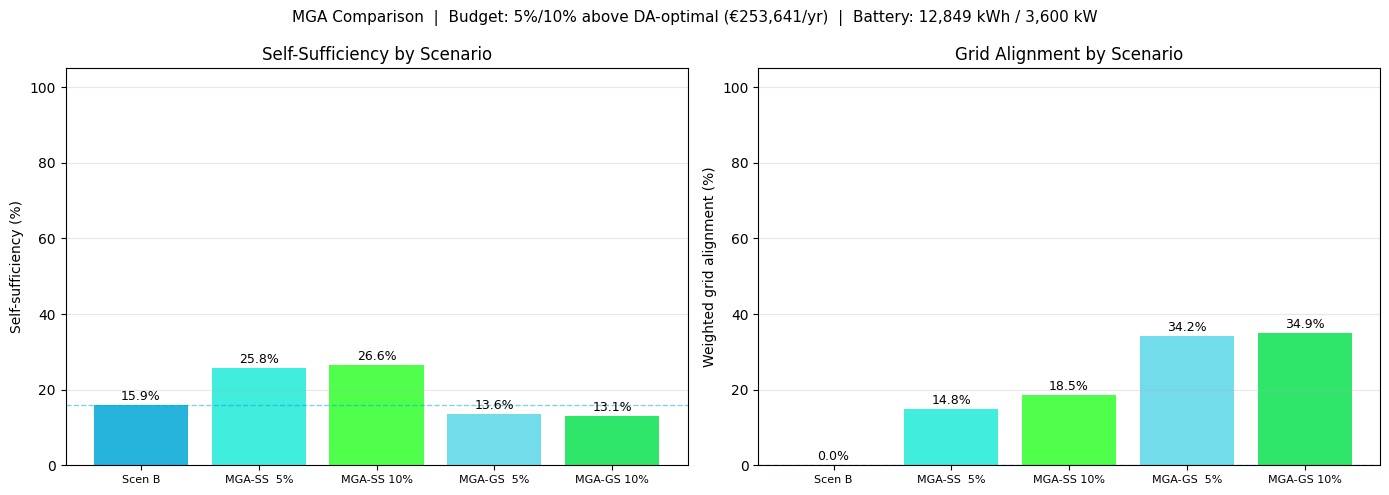

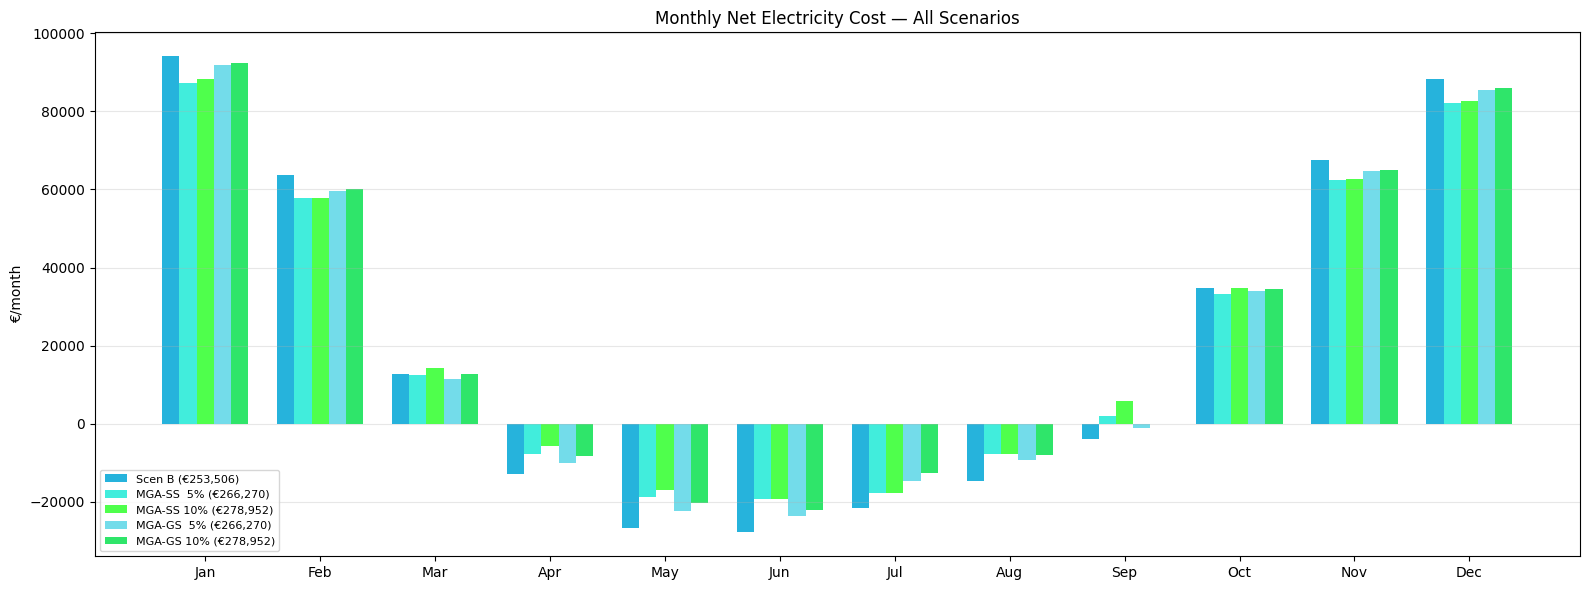

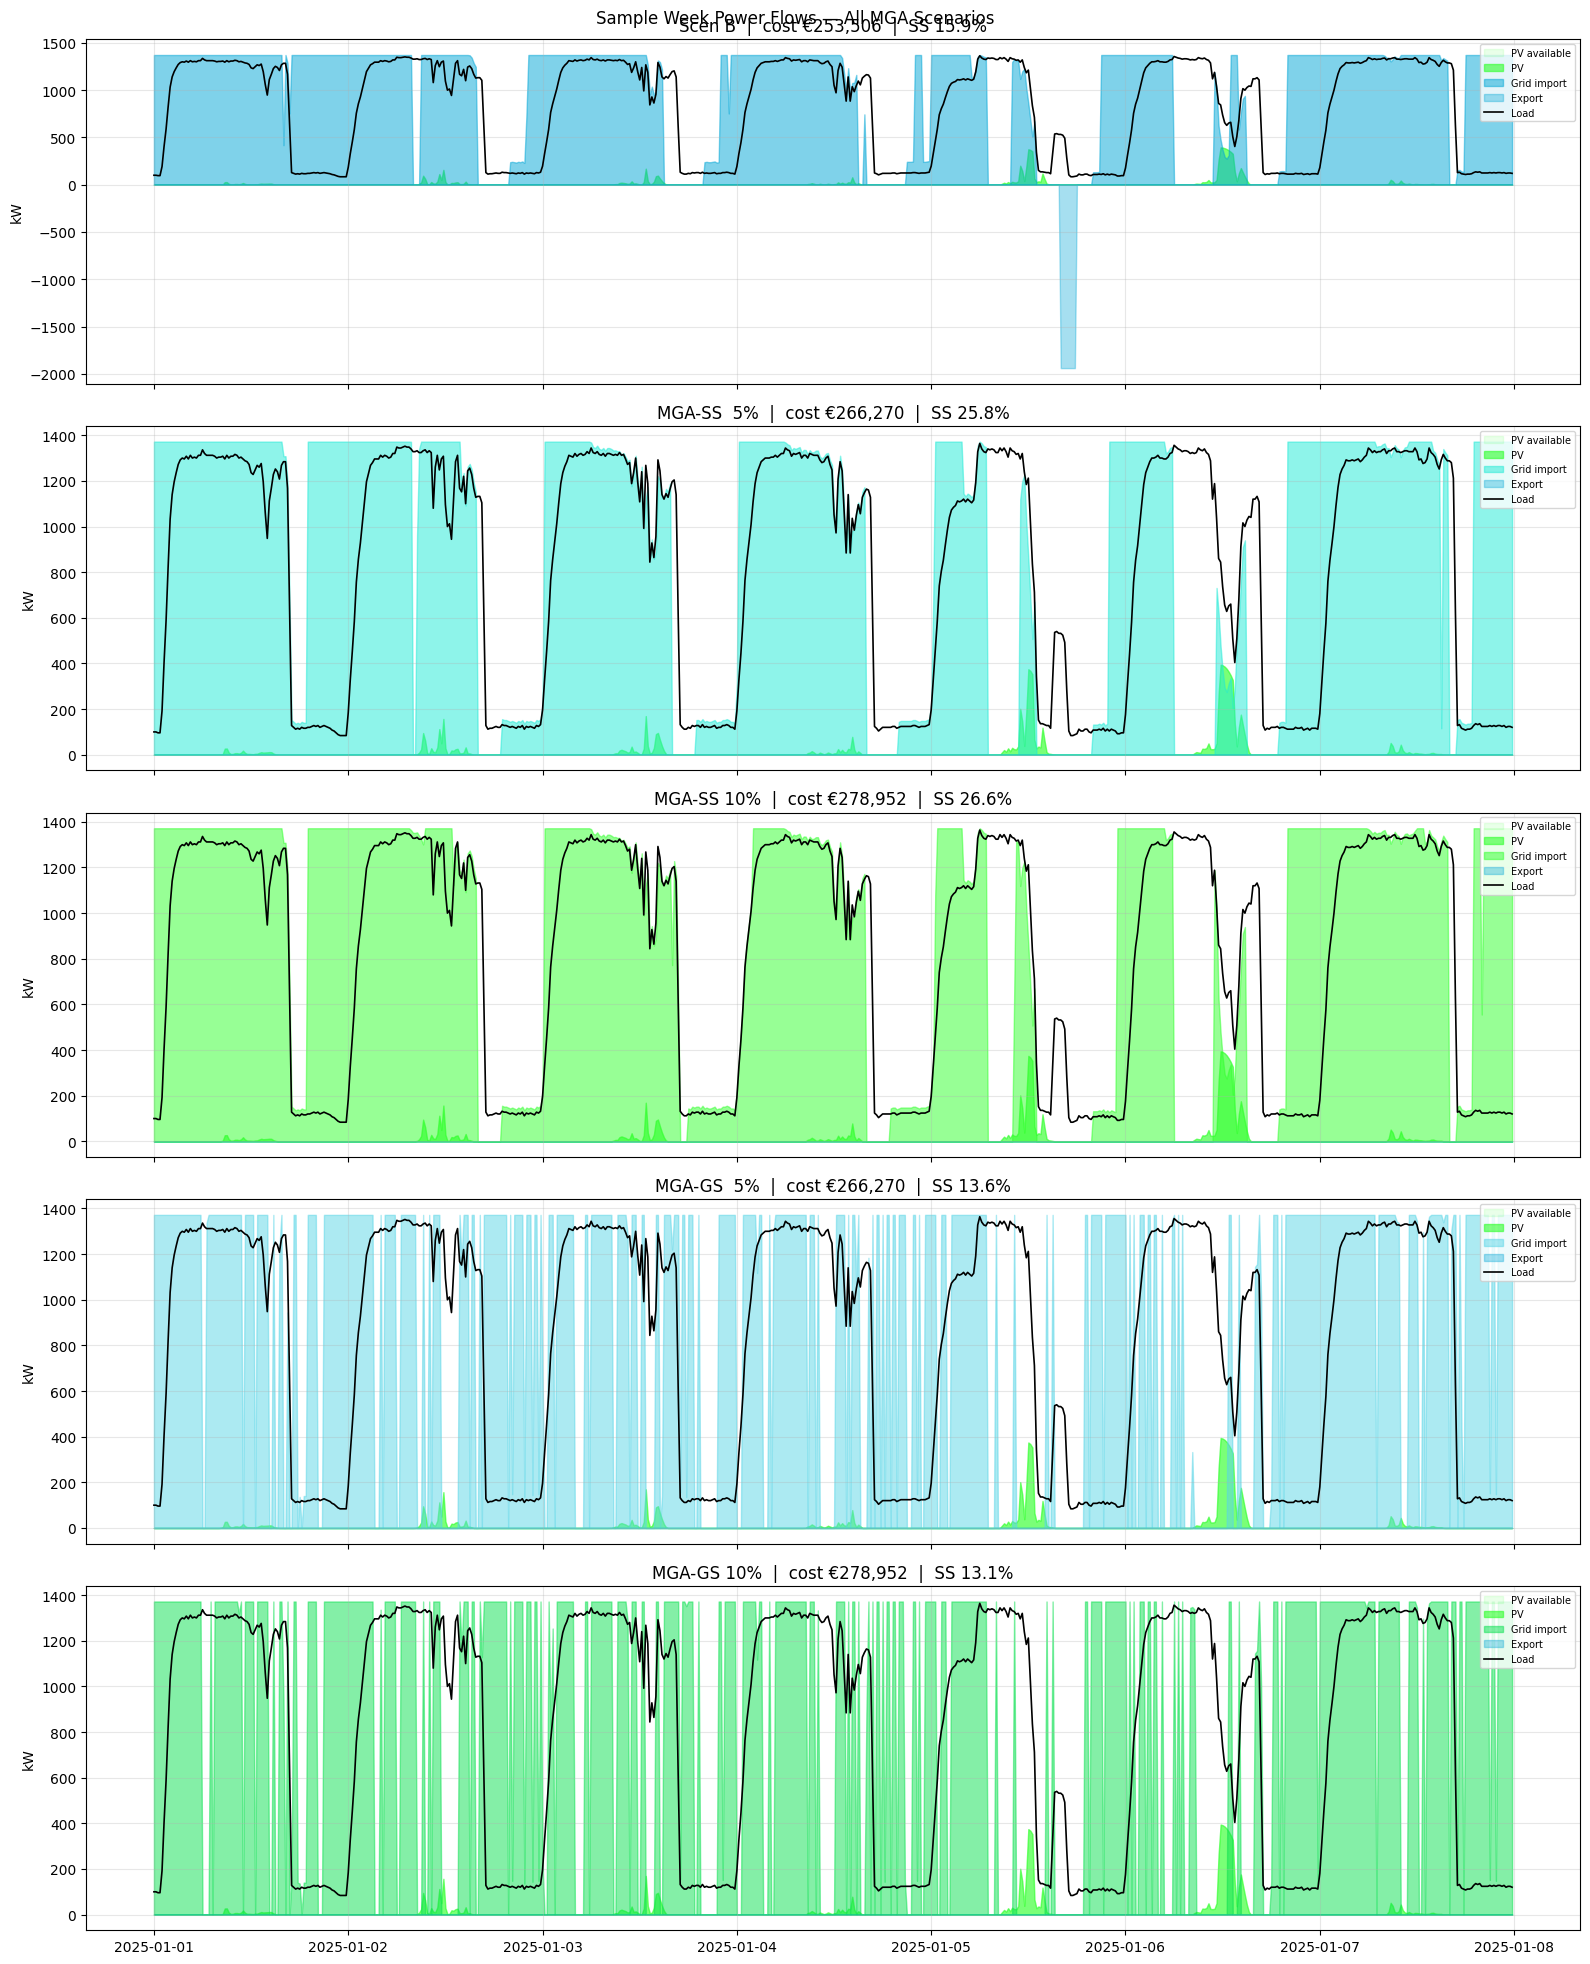

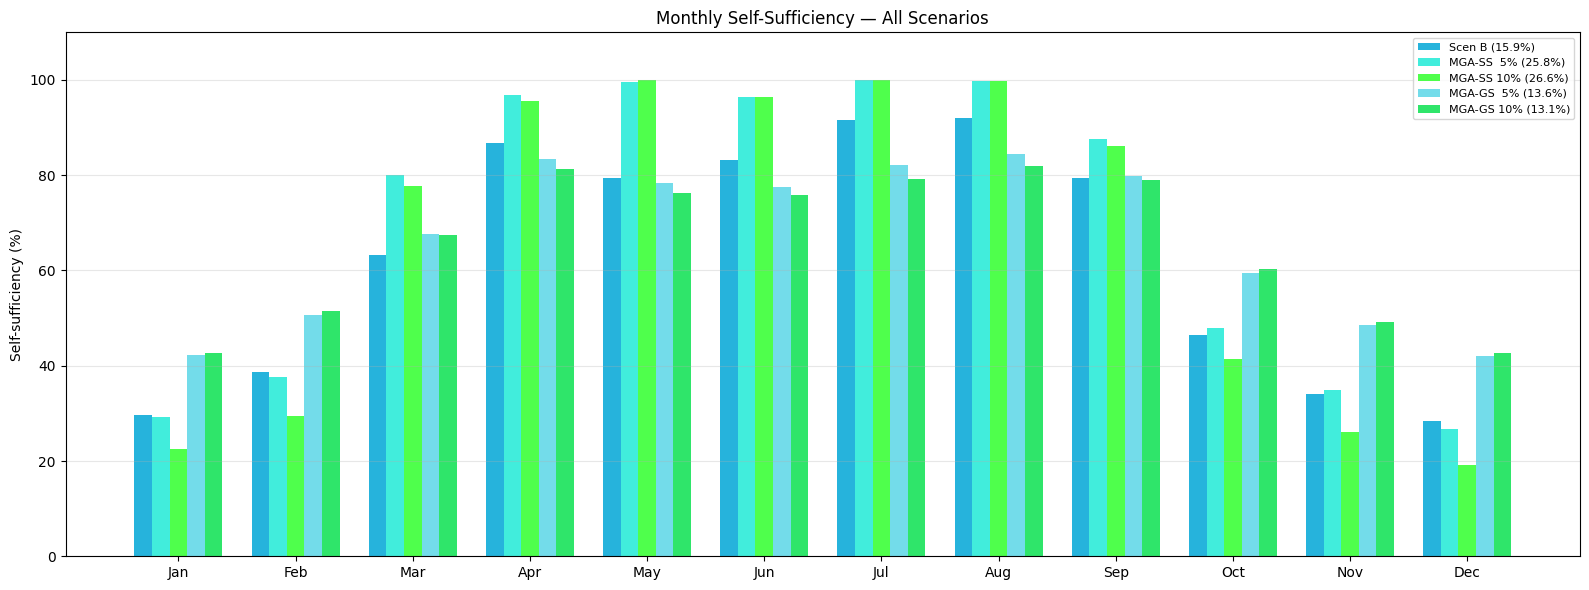

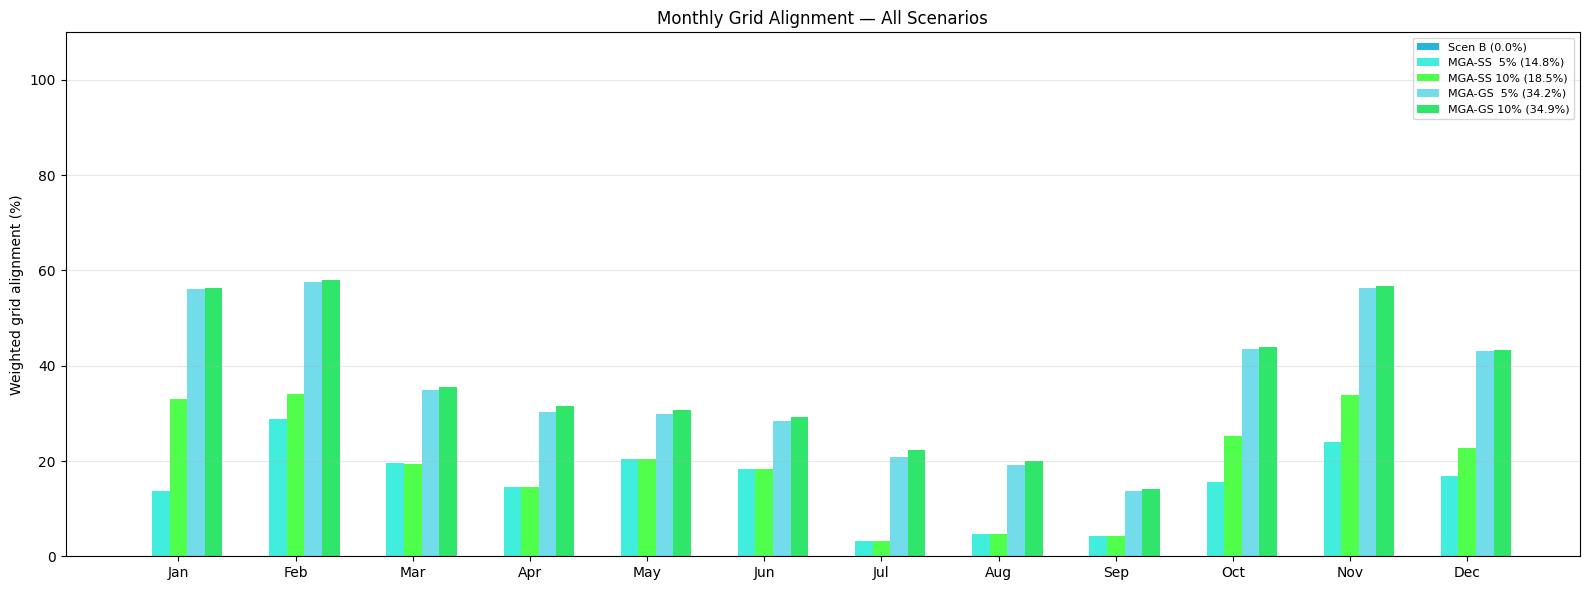

Part III (MGA) complete.
  Scenario          Cost €/yr   vs DA  Import MWh    SS%  Grid align%
  ----------------------------------------------------------------------
  Scen B              253,506   -0.1%     4,180.4  15.9%    0.0%
  MGA-SS  5%          266,270    5.0%     2,663.1  25.8%   14.8%
  MGA-SS 10%          278,952   10.0%     2,596.4  26.6%   18.5%
  MGA-GS  5%          266,270    5.0%     4,441.9  13.6%   34.2%
  MGA-GS 10%          278,952   10.0%     4,614.9  13.1%   34.9%

Battery flows — Scen B  (MWh)
------------------------------------------------------------
  Month        PV→bat     Grid→bat     Bat→load   Bat→export
------------------------------------------------------------
  Jan             4.6        194.4        172.2         16.1
  Feb            16.5        169.3        167.7          9.7
  Mar            91.2        215.5        158.5        127.6
  Apr           144.6        171.0        124.1        181.4
  May           158.1        206.9         64.2  

In [103]:
# ════════════════════════════════════════════════════════════════════════════
# PART III  —  MODELLING TO GENERATE ALTERNATIVES  (MGA)
# ════════════════════════════════════════════════════════════════════════════
# Requires Part I (Cell 1) + Part II (Cell 2) to have run first.
#
# Finds the best achievable Self-Sufficiency (SS) and Grid Support (GS)
# within 5% and 10% cost budget above the DA-optimal baseline (Scen B).
# Each objective × each budget = 4 MGA runs, all compared against Scen B.
#
# Objectives:
#   SS  — maximise self-sufficiency: shift import to PV-peak hours
#   GS  — maximise grid support: align import with grid stress signal
#
# Cost budget = Scen B DA-optimal full cost × (1 + slack)
# ════════════════════════════════════════════════════════════════════════════

import xarray as xr
import logging
logging.getLogger('pypsa').setLevel(logging.WARNING)
logging.getLogger('linopy').setLevel(logging.WARNING)

MGA_SLACK_5  = 0.05   # 5%  cost tolerance above DA-optimal
MGA_SLACK_10 = 0.10   # 10% cost tolerance above DA-optimal

# ── Grid-alignment proxy weight vector (stress-proportional) ────────────────
_gs_max  = grid_stress.abs().max()
_align_w = (grid_stress / _gs_max) if _gs_max > 0 else pd.Series(0.0, index=df.index)


def _scenario_full_cost(res_df):
    """Electricity net cost + HP and geo variable O&M — matches MGA cost_lhs."""
    return (_scenario_net_cost(res_df)
            + float((res_df["hp_elec"]  * _hp_mc  * DT).sum())
            + float((res_df["geo_elec"] * _geo_mc * DT).sum()))


def _bat_monthly_flows(res_df):
    """Monthly battery flow breakdown (MWh) using proportional bus allocation."""
    pv = res_df["pv"];  gi = res_df["grid_import"];  ge = res_df["grid_export"]
    bc = res_df["bat_charge"];  bd = res_df["bat_discharge"];  lk = res_df["load"]
    total_supply = (pv + gi + bd).clip(lower=1e-9)
    total_demand = (lk + bc + ge).clip(lower=1e-9)
    months = pv.index.month
    def _mg_sum(s): return s.groupby(months).sum() * DT / 1e3
    return {
        "PV→bat":     _mg_sum(pv / total_supply * bc),
        "Grid→bat":   _mg_sum(gi / total_supply * bc),
        "Bat→load":   _mg_sum(bd * lk / total_demand),
        "Bat→export": _mg_sum(bd * ge / total_demand),
    }


def run_mga(objective_name, slack):
    """
    MGA optimisation within slack of the DA-optimal full cost.
    objective_name : 'SS' | 'GS'
    slack          : 0.05 or 0.10
    Returns extracted dispatch DataFrame.
    """
    ref_cost = _scenario_full_cost(res2)
    budget   = ref_cost + abs(ref_cost) * slack

    n = _build_combined_dispatch_network(participation_weight=0.0, include_battery=True)
    n.optimize.create_model()
    m  = n.model
    sn = n.snapshots

    gen_var  = m.variables["Generator-p"]
    snap_dim = [d for d in gen_var.dims if d.lower() == "snapshot"][0]

    wts   = xr.DataArray(n.snapshot_weightings["generators"].values,
                         dims=[snap_dim], coords={snap_dim: sn})
    imp_p = xr.DataArray(import_price.values, dims=[snap_dim], coords={snap_dim: sn})
    da_p  = xr.DataArray(da_price.values,     dims=[snap_dim], coords={snap_dim: sn})

    try:
        p_imp = gen_var.sel(Generator="grid_import")
        p_exp = gen_var.sel(Generator="grid_export")
    except (KeyError, ValueError):
        _gen_dim = [d for d in gen_var.dims if d.lower() != "snapshot"][0]
        p_imp = gen_var.sel({_gen_dim: "grid_import"})
        p_exp = gen_var.sel({_gen_dim: "grid_export"})

    link_var = m.variables["Link-p"]
    _lnk_dim = [d for d in link_var.dims if d != snap_dim][0]
    p_hp  = link_var.sel({_lnk_dim: "heat_pump"})
    p_geo = link_var.sel({_lnk_dim: "geothermal"})

    cost_lhs = (p_imp * imp_p * wts + p_exp * da_p * wts
               + p_hp * _hp_mc * wts + p_geo * _geo_mc * wts).sum()
    m.add_constraints(cost_lhs <= budget, name="mga_cost_budget")

    if objective_name == "SS":
        m.objective = (p_imp * wts).sum()
    elif objective_name == "GS":
        al_w = xr.DataArray(_align_w.values, dims=[snap_dim], coords={snap_dim: sn})
        m.objective = (p_imp * al_w * wts).sum()

    status, cond = n.optimize.solve_model(solver_name="highs", log_to_console=False)
    if status not in ("ok", "warning"):
        raise RuntimeError(f"MGA-{objective_name}@{slack*100:.0f}% failed: {status} / {cond}")
    return _extract_dispatch(n)


# ── Run all 4 MGA scenarios ──────────────────────────────────────────────────
_s2_ref_cost = _scenario_full_cost(res2)
print(f"MGA reference: Scen B DA-optimal cost = €{_s2_ref_cost:,.0f}/yr")
print(f"Battery  : {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW  (from combined optimisation)")
print()

print("Running MGA-SS  5%  (max self-sufficiency,  5% budget) ...")
res_mga_ss_5  = run_mga("SS", MGA_SLACK_5);  print("  → OK")

print("Running MGA-SS 10%  (max self-sufficiency, 10% budget) ...")
res_mga_ss_10 = run_mga("SS", MGA_SLACK_10); print("  → OK")

print("Running MGA-GS  5%  (max grid support,      5% budget) ...")
res_mga_gs_5  = run_mga("GS", MGA_SLACK_5);  print("  → OK")

print("Running MGA-GS 10%  (max grid support,     10% budget) ...")
res_mga_gs_10 = run_mga("GS", MGA_SLACK_10); print("  → OK")
print()


# ════════════════════════════════════════════════════════════════════════════
# POST-PROCESSING
# ════════════════════════════════════════════════════════════════════════════

_mga_results = {
    "Scen B":      res2,
    "MGA-SS  5%":  res_mga_ss_5,
    "MGA-SS 10%":  res_mga_ss_10,
    "MGA-GS  5%":  res_mga_gs_5,
    "MGA-GS 10%":  res_mga_gs_10,
}

def _mga_stats(res_df, ref_cost):
    cost       = _scenario_net_cost(res_df)
    ss         = _compute_ss(res_df)
    ss_sim     = _compute_ss_simple(res_df)
    sc_sim     = _compute_sc_simple(res_df)
    sc_load    = _compute_sc_load(res_df)
    import_mwh = float((res_df["grid_import"] * DT).sum()) / 1e3
    pnl        = _calc_imb_pnl(res_df["grid_import"], res2["grid_import"]).sum()
    over       = (cost - ref_cost) / abs(ref_cost) * 100 if ref_cost != 0 else 0.0
    dev_mwh    = float((res_df["grid_import"] - res2["grid_import"]).abs().sum() * DT / 1e3)
    if _has_vol:
        al_w, _ = _calc_alignment_weighted(res_df["grid_import"], res2["grid_import"])
        al_b, _, _ = _calc_alignment(res_df["grid_import"], res2["grid_import"])
    else:
        al_w = al_b = 0.0
    return {"cost": cost, "ss": ss, "ss_sim": ss_sim,
            "sc_sim": sc_sim, "sc_load": sc_load,
            "import_mwh": import_mwh,
            "imb_pnl": pnl, "cost_over_pct": over,
            "al_w": al_w, "al_b": al_b, "dev_mwh": dev_mwh}

_stats = {k: _mga_stats(v, _s2_ref_cost) for k, v in _mga_results.items()}


# ── KPI Summary Table ────────────────────────────────────────────────────────
W = 95
print("=" * W)
print(f"  MGA RESULTS  (all metrics vs Scen B reference)")
hdr = f"  {'KPI':<40}"
for k in _mga_results: hdr += f" {k:>10}"
print(hdr)
print("=" * W)

def _row(label, key, fmt):
    r = f"  {label:<40}"
    for k in _mga_results:
        r += f" {fmt.format(_stats[k][key]):>10}"
    return r

print(_row("Net elec. cost (€/yr)",           "cost",          "{:,.0f}"))
print(_row("Cost vs Scen B (%)",               "cost_over_pct", "{:+.1f}%"))
print("-" * W)
print(_row("Total grid import (MWh/yr)",       "import_mwh",    "{:,.1f}"))
print("-" * W)
print(_row("Self-sufficiency simple (%)",      "ss_sim",        "{:.1f}%"))
print(_row("Self-sufficiency load-only (%)",   "ss",            "{:.1f}%"))
print("-" * W)
print(_row("Self-consumption simple (%)",      "sc_sim",        "{:.1f}%"))
print(_row("Self-consumption load-only (%)",   "sc_load",       "{:.1f}%"))
print("-" * W)
print(_row("Imb. P&L vs Scen B (€/yr)",        "imb_pnl",       "{:+,.0f}"))
if _has_vol:
    print(_row("Passive align binary top25% (%)","al_b",         "{:.1f}%"))
    print(_row("Passive align weighted (%)",     "al_w",         "{:.1f}%"))
print(_row("Deviation from Scen B (MWh/yr)",   "dev_mwh",       "{:.1f}"))
print("=" * W)
print()


# ════════════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════════════

_labels  = list(_mga_results.keys())
_colors  = ["#00A6D6", "#1FEAD6", "#30FF2C", "#5AD6E7", "#0AE150"]
_x_bars  = np.arange(len(_labels))
_x12     = np.arange(12)
_w3      = 0.15

# ── Plot MGA-1: SS and grid alignment bar comparison ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ss_vals = [_stats[k]["ss"] for k in _labels]
bars = ax.bar(_x_bars, ss_vals, color=_colors, alpha=0.85)
ax.axhline(_stats["Scen B"]["ss"], color="#00A6D6", lw=1, ls="--", alpha=0.5)
for bar, v in zip(bars, ss_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(_x_bars); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("Self-sufficiency (%)"); ax.set_title("Self-Sufficiency by Scenario")
ax.set_ylim(0, 105); ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
if _has_vol:
    al_vals = [_stats[k]["al_w"] for k in _labels]
    bars = ax.bar(_x_bars, al_vals, color=_colors, alpha=0.85)
    ax.axhline(_stats["Scen B"]["al_w"], color="#00A6D6", lw=1, ls="--", alpha=0.5)
    for bar, v in zip(bars, al_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Weighted grid alignment (%)"); ax.set_title("Grid Alignment by Scenario")
    ax.set_ylim(0, 105)
else:
    cost_vals = [_stats[k]["cost"] for k in _labels]
    bars = ax.bar(_x_bars, cost_vals, color=_colors, alpha=0.85)
    for bar, v in zip(bars, cost_vals):
        ax.text(bar.get_x() + bar.get_width()/2, v*1.01, f"€{v:,.0f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Net electricity cost (€/yr)"); ax.set_title("Net Cost by Scenario")
ax.set_xticks(_x_bars); ax.set_xticklabels(_labels, fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    f"MGA Comparison  |  Budget: 5%/10% above DA-optimal (€{_s2_ref_cost:,.0f}/yr)  |  "
    f"Battery: {bat_e_kwh:,.0f} kWh / {bat_p_kw:,.0f} kW", fontsize=11)
plt.tight_layout()
plt.savefig("nl_heat_mga_comparison.png", dpi=150)
plt.show()


# ── Plot MGA-2: Monthly cost comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
_offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
    cost_m = (_mg(res_df["grid_import"] * import_price * DT) -
              _mg(res_df["grid_export"] * da_price * DT))
    ax.bar(_x12 + offset, cost_m.values, _w3, label=f"{label} (€{cost_m.sum():,.0f})",
           color=color, alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("€/month"); ax.set_title("Monthly Net Electricity Cost — All Scenarios")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("nl_heat_mga_monthly_cost.png", dpi=150)
plt.show()


# ── Plot MGA-3: Sample week dispatch (all 5 scenarios) ───────────────────────
_SAMPLE = slice(0, 7 * 24 * 4)
_x_wk   = res2.index[_SAMPLE]

fig, axes = plt.subplots(len(_mga_results), 1, figsize=(16, 4*len(_mga_results)), sharex=True)
for ax, (label, res_df), color in zip(axes, _mga_results.items(), _colors):
    ax.fill_between(_x_wk, (res_df["pv"]+res_df["pv_curtailed"])[_SAMPLE],
                    alpha=0.1, color="#30FF2C", label="PV available")
    ax.fill_between(_x_wk, res_df["pv"][_SAMPLE],           alpha=0.6, color="#30FF2C",  label="PV")
    ax.fill_between(_x_wk, res_df["grid_import"][_SAMPLE],  alpha=0.5, color=color,      label="Grid import")
    ax.fill_between(_x_wk, -res_df["grid_export"][_SAMPLE], alpha=0.35, color="#00A6D6", label="Export")
    ax.plot(_x_wk, res_df["load"][_SAMPLE], color="black", lw=1.2, label="Load")
    ax.set_ylabel("kW")
    ax.set_title(f"{label}  |  cost €{_stats[label]['cost']:,.0f}  |  SS {_stats[label]['ss']:.1f}%")
    ax.legend(fontsize=7, loc="upper right"); ax.grid(True, alpha=0.3)

plt.suptitle("Sample Week Power Flows — All MGA Scenarios", fontsize=12)
plt.tight_layout()
plt.savefig("nl_heat_mga_week_dispatch.png", dpi=150)
plt.show()


# ── Plot MGA-4: Monthly self-sufficiency ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
_offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
    ss_m = _ss_monthly(res_df)
    ax.bar(_x12 + offset, ss_m.values, _w3,
           label=f"{label} ({_stats[label]['ss']:.1f}%)", color=color, alpha=0.85)
ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
ax.set_ylabel("Self-sufficiency (%)"); ax.set_title("Monthly Self-Sufficiency — All Scenarios")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("nl_heat_mga_monthly_ss.png", dpi=150)
plt.show()


# ── Plot MGA-5: Grid alignment monthly (if data available) ───────────────────
if _has_vol:
    fig, ax = plt.subplots(figsize=(16, 6))
    _offsets = np.linspace(-2*_w3, 2*_w3, len(_labels))
    for (label, res_df), offset, color in zip(_mga_results.items(), _offsets, _colors):
        _, al_m = _calc_alignment_weighted(res_df["grid_import"], res2["grid_import"])
        ax.bar(_x12 + offset, al_m.values, _w3,
               label=f"{label} ({_stats[label]['al_w']:.1f}%)", color=color, alpha=0.85)
    ax.set_xticks(_x12); ax.set_xticklabels(MONTHS)
    ax.set_ylabel("Weighted grid alignment (%)")
    ax.set_title("Monthly Grid Alignment — All Scenarios")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.savefig("nl_heat_mga_monthly_alignment.png", dpi=150)
    plt.show()


print("Part III (MGA) complete.")
print(f"  {'Scenario':<14} {'Cost €/yr':>12} {'vs DA':>7} {'Import MWh':>11} {'SS%':>6}" +
      ("  Grid align%" if _has_vol else ""))
print("  " + "-" * (56 + (14 if _has_vol else 0)))
for k in _labels:
    s = _stats[k]
    row = (f"  {k:<14} {s['cost']:>12,.0f} {s['cost_over_pct']:>6.1f}%"
           f" {s['import_mwh']:>11,.1f} {s['ss']:>5.1f}%")
    if _has_vol: row += f"  {s['al_w']:>5.1f}%"
    print(row)


# ════════════════════════════════════════════════════════════════════════════
# BATTERY MONTHLY FLOW TABLES  (proportional bus allocation, MWh)
# ════════════════════════════════════════════════════════════════════════════

for _scen_name, _scen_res in _mga_results.items():
    _flows = _bat_monthly_flows(_scen_res)
    _col_w = 12
    _hdr   = f"  {'Month':<6}" + "".join(f" {c:>{_col_w}}" for c in _flows)
    _sep   = "-" * (8 + (1 + _col_w) * len(_flows))
    print(f"\nBattery flows — {_scen_name}  (MWh)")
    print(_sep); print(_hdr); print(_sep)
    for _mi in range(1, 13):
        _row_s = f"  {MONTHS[_mi-1]:<6}"
        for _col in _flows:
            _row_s += f" {_flows[_col][_mi]:>{_col_w}.1f}"
        print(_row_s)
    print(_sep)
    _row_s = f"  {'Total':<6}"
    for _col in _flows:
        _row_s += f" {_flows[_col].sum():>{_col_w}.1f}"
    print(_row_s); print(_sep)


  ECONOMIC RESULTS | Full System Payback

  ANNUAL BASELINE COST (no system)
  Electricity (load from grid)         : €  506,932/yr
  Heat (gas boiler)                    : €  578,394/yr  (1,285,320 m³ gas)
  CO2 purchase                         : €  117,000/yr  (1300 tCO2 @ €90/t)
  ───────────────────────────────────────────────────────
  Total baseline                       : €1,202,326/yr

  SYSTEM ANNUAL OPEX
  Net electricity cost                 : €  252,757/yr
  PV O&M                               : €   22,620/yr
  Battery O&M                          : €   29,160/yr
  Heat system O&M                      : €   65,773/yr
  DAC FOM                              : €        0/yr
  ───────────────────────────────────────────────────────
  Total OPEX                           : €  370,310/yr
  Annual benefit vs baseline           : € +832,016/yr

  CAPEX SUMMARY
  PV                                   : €3,393,000   (1885 kWp STC × €1800/kWp  |  real peak 1178 kW)
  Battery          

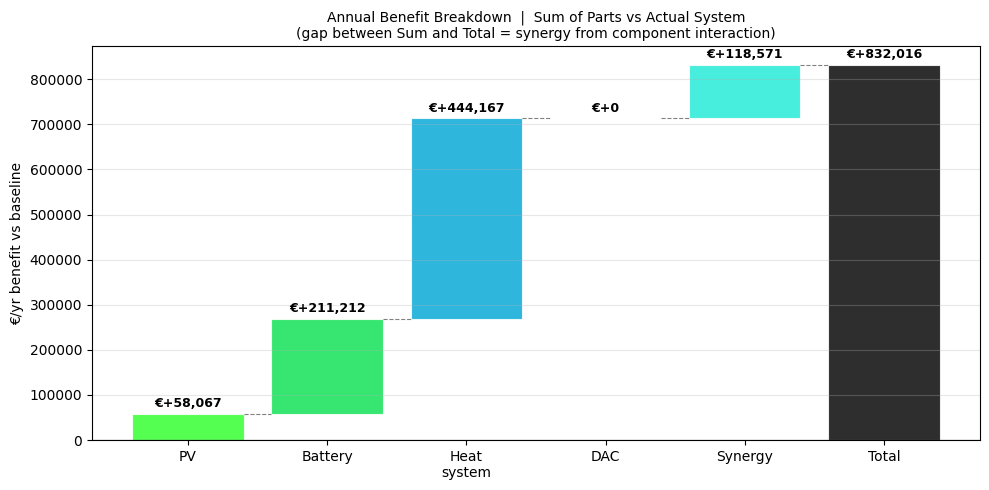


  EFFECTIVE UNIT PRICES  (before vs after system)
  ────────────────────────────────────────────────────────────────────────
  Energy carrier         Unit               Before           After    Change
  ────────────────────────────────────────────────────────────────────────
  Electricity (base load) EUR/MWh            154.5           77.0    -50.1%
  Heat (gas boiler → HP) EUR/MWh_th          49.5            5.9    -88.2%
  CO2 (purchase → DAC)   EUR/tCO2            90.0            n/a         n/a
  ────────────────────────────────────────────────────────────────────────
  Notes:
    Electricity: 'After' = net annual elec cost / greenhouse base-load MWh.
      Includes HP & DAC electricity in numerator; PV+battery offset subtracted.
    Heat: 'After' = HP + geothermal pump elec cost per MWh_th delivered.
      Excludes heat-system O&M and CAPEX (those appear in the payback table).
    CO2: 'After' = LCCO2 = (CAPEX/20yr + FOM + elec) / tCO2/yr.
      DAC: 20 yr economic life assumed.

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 112.31it/s]


No-PV dispatch: import 4909 MWh, export 981 MWh, net cost €409,154/yr  (was €252,757/yr with PV)

  TRUE PV MARGINAL VALUE  (full system, fixed sizes, PV zeroed)
  ────────────────────────────────────────────────────────────
  Full system net elec cost  (with PV)       : €  252,757/yr
  Full system net elec cost  (no PV)         : €  409,154/yr
  ────────────────────────────────────────────────────────────
  Electricity saving from PV                 : € +156,397/yr
  PV O&M                                     : €  -22,620/yr
  Net PV benefit (true marginal)             : € +133,777/yr
  PV CAPEX                                   : €3,393,000
  Simple payback                             :      25.4 yr
  ────────────────────────────────────────────────────────────
  Compare: standalone PV benefit (Cell-0 dispatch) = €+58,067/yr  (58.4 yr)
  Difference = synergy effect of battery/heat system on PV value


Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 142.41it/s]
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible



No-bat dispatch: import 4187 MWh, export 1683 MWh, net cost €252,757/yr  (was €252,757/yr with battery)

  TRUE BATTERY MARGINAL VALUE  (full system, fixed sizes, battery zeroed)
  ────────────────────────────────────────────────────────────
  Full system net elec cost  (with battery)  : €  252,757/yr
  Full system net elec cost  (no battery)    : €  252,757/yr
  ────────────────────────────────────────────────────────────
  Electricity saving from battery            : €       +0/yr
  Battery O&M                                : €  -29,160/yr
  Net battery benefit (true marginal)        : €  -29,160/yr
  Battery CAPEX                              : €1,781,291   (12849 kWh / 3600 kW)
  Simple payback                             :       inf yr
  ────────────────────────────────────────────────────────────
  Compare: standalone battery benefit (LP marginal) = €+211,212/yr  (8.4 yr)
  Difference = synergy effect of heat system / DAC on battery value


In [149]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Full System Economics & Payback
# Baseline : grid electricity + condensing gas boiler + purchased liquid CO2
# Reference: gas-engine CHP delivering equivalent heat + CO2 as byproduct
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np

# ─── Parameters — Dutch greenhouse 2024 (all adjustable) ────────────────────
GAS_PRICE_EUR_M3   = 0.45    # €/m³  (H-gas, greenhouse contract ≈ TTF + distribution)
GAS_LHV_KWH_M3    = 9.77    # kWh/m³ LHV  (H-gas, NL grid post-Groningen)
GAS_BOILER_EFF     = 0.93    # condensing gas boiler thermal efficiency

CHP_ELEC_EFF       = 0.41    # gas-engine CHP electrical efficiency
CHP_HEAT_EFF       = 0.44    # gas-engine CHP thermal efficiency
CHP_CO2_KG_M3      = 1.80    # kg CO2 per m³ gas (purified flue gas enrichment)
CHP_CAPEX_EUR_KW_E = 1_100   # €/kW_e all-in installed (Jenbacher class)
CHP_LIFETIME_YR    = 15      # operational years
CHP_OM_EUR_MWH_E   = 20.0   # €/MWh_e variable O&M
CHP_LOAD_FACTOR    = 0.75    # annual capacity factor

PV_CAPEX_EUR_KWP   = 1_800   # €/kWp  (€1.8/Wp, 145 Wp/module)
PV_OM_EUR_KW_YR    = 12.0   # €/kWp/yr fixed O&M
PV_LIFETIME_YR     = 25      # years

CO2_PURCHASE_EUR_T = 90 # €/tCO2 liquid CO2 supply (greenhouse enrichment)
WACC               = 0.07    # discount rate for NPV

# ─── Grid-only baseline annual costs ────────────────────────────────────────
elec_baseline   = float(_no_pv_import_cost)                             # €/yr — grid-only (DT=0.25, from Cell 0)
gas_m3_heat     = heat_dem_mwh * 1e3 / GAS_LHV_KWH_M3 / GAS_BOILER_EFF
heat_baseline   = gas_m3_heat * GAS_PRICE_EUR_M3                       # €/yr — gas boiler
co2_annual_t    = (CO2_DEMAND.get('annual_tCO2_per_ha', 250)
                   * CO2_DEMAND.get('hectares', GREENHOUSE_HA))
co2_baseline    = co2_annual_t * CO2_PURCHASE_EUR_T                    # €/yr — liquid CO2
total_baseline  = elec_baseline + heat_baseline + co2_baseline

_PV_KWP_STC     = PV_MODULES * MODULE_WP / 1000            # installed kWp (STC nameplate)
# ─── System annual OPEX (no CAPEX) ──────────────────────────────────────────
sys_om_pv       = PV_OM_EUR_KW_YR * _PV_KWP_STC
sys_om_bat      = bat_fix_eur
sys_om_heat     = hp_fix_eur + geo_fix_eur + ts_fix_eur
_dac_a          = DAC_2030['elec_in_MWh_per_tCO2']
sys_om_dac      = (dac_p_nom_kw * DAC_2030['fom_Meur_per_tCO2h_yr'] * 1e6
                   / _dac_a / 1000) if dac_p_nom_kw > 0 else 0.0
total_sys_opex  = comb_net_cost + sys_om_pv + sys_om_bat + sys_om_heat + sys_om_dac
annual_benefit  = total_baseline - total_sys_opex

# ─── CAPEX by component ─────────────────────────────────────────────────────
pv_capex        = PV_CAPEX_EUR_KWP * _PV_KWP_STC
bat_capex_e     = bat_capex_tot                                        # from gross_capex()
heat_capex_e    = hp_capex_tot + geo_capex_tot + geo_abex_tot + ts_capex_tot
dac_capex_e     = (dac_p_nom_kw * DAC_2030['capex_Meur_per_tCO2h'] * 1e6
                   / _dac_a / 1000) if dac_p_nom_kw > 0 else 0.0
total_capex_e   = pv_capex + bat_capex_e + heat_capex_e + dac_capex_e

# ─── Component benefit attribution ───────────────────────────────────────────
# PV: avoided grid cost vs baseline, net of O&M  (uses _pv_net_cost = PV-only elec cost)
pv_benefit      = elec_baseline - _pv_net_cost - sys_om_pv
# Battery: marginal electricity saving on top of PV-only, net of O&M
bat_benefit     = _pv_net_cost - eo_net_cost - sys_om_bat
# Heat: avoided gas boiler cost minus HP+geo electricity consumed, minus O&M
heat_benefit    = heat_baseline - hp_elec_cost - geo_elec_cost - sys_om_heat
# DAC: avoided CO2 purchase minus DAC electricity cost, minus FOM
dac_elec_eur    = float((dac_elec_kw * import_price * DT_H).sum()) if dac_p_nom_kw > 0 else 0.0
dac_benefit     = (co2_baseline - dac_elec_eur - sys_om_dac) if dac_p_nom_kw > 0 else 0.0

# ─── Simple payback ──────────────────────────────────────────────────────────
def _spb(capex, ben): return capex / ben if ben > 1 else float('inf')

pv_spb   = _spb(pv_capex,      pv_benefit)
bat_spb  = _spb(bat_capex_e,   bat_benefit)
heat_spb = _spb(heat_capex_e,  heat_benefit)
dac_spb  = _spb(dac_capex_e,   dac_benefit)
sys_spb  = _spb(total_capex_e, annual_benefit)

# ─── NPV ─────────────────────────────────────────────────────────────────────
_life_yr = max(BATTERY_LIFE_YR, PV_LIFETIME_YR)
npv_sys  = sum(annual_benefit / (1 + WACC)**yr for yr in range(1, _life_yr + 1)) - total_capex_e

# ─── CHP reference (sized to cover CO2 demand — the binding constraint) ──────
# Dutch greenhouse: CHP driven by CO2 enrichment demand, heat is a byproduct
gas_m3_co2      = co2_annual_t * 1e3 / CHP_CO2_KG_M3                   # m³/yr for CO2
gas_m3_chp_heat = heat_dem_mwh * 1e3 / GAS_LHV_KWH_M3 / CHP_HEAT_EFF  # m³/yr for heat
gas_m3_chp      = max(gas_m3_co2, gas_m3_chp_heat)                      # binding
_chp_driver     = 'CO2' if gas_m3_co2 >= gas_m3_chp_heat else 'heat'
chp_elec_mwh_yr = gas_m3_chp * GAS_LHV_KWH_M3 * CHP_ELEC_EFF / 1e3
chp_heat_mwh_yr = gas_m3_chp * GAS_LHV_KWH_M3 * CHP_HEAT_EFF / 1e3
chp_co2_t_yr    = gas_m3_chp * CHP_CO2_KG_M3 / 1e3
chp_kw_e        = gas_m3_chp * GAS_LHV_KWH_M3 * CHP_ELEC_EFF / (8760 * CHP_LOAD_FACTOR)
chp_capex       = chp_kw_e * CHP_CAPEX_EUR_KW_E
chp_ann_cap     = chp_capex / CHP_LIFETIME_YR
chp_gas_cost    = gas_m3_chp * GAS_PRICE_EUR_M3
chp_om_cost     = chp_elec_mwh_yr * CHP_OM_EUR_MWH_E
chp_elec_rev    = chp_elec_mwh_yr * float(da_price.mean())
chp_net_opex    = chp_gas_cost + chp_om_cost - chp_elec_rev
chp_total_ann   = chp_ann_cap + chp_net_opex
# Heat surplus/deficit when sized for CO2
chp_heat_surplus = chp_heat_mwh_yr - heat_dem_mwh

# ─── Print ───────────────────────────────────────────────────────────────────
W = 68
print(f"{'':=<{W+4}}")
print(f"  ECONOMIC RESULTS | Full System Payback")
print(f"{'':=<{W+4}}")
print(f"\n  ANNUAL BASELINE COST (no system)")
print(f"  {'Electricity (load from grid)':<36} : €{elec_baseline:>9,.0f}/yr")
print(f"  {'Heat (gas boiler)':<36} : €{heat_baseline:>9,.0f}/yr  ({gas_m3_heat:,.0f} m³ gas)")
print(f"  {'CO2 purchase':<36} : €{co2_baseline:>9,.0f}/yr  ({co2_annual_t:.0f} tCO2 @ €{CO2_PURCHASE_EUR_T:.0f}/t)")
print(f"  {'':─<55}")
print(f"  {'Total baseline':<36} : €{total_baseline:>9,.0f}/yr")

print(f"\n  SYSTEM ANNUAL OPEX")
print(f"  {'Net electricity cost':<36} : €{comb_net_cost:>9,.0f}/yr")
print(f"  {'PV O&M':<36} : €{sys_om_pv:>9,.0f}/yr")
print(f"  {'Battery O&M':<36} : €{sys_om_bat:>9,.0f}/yr")
print(f"  {'Heat system O&M':<36} : €{sys_om_heat:>9,.0f}/yr")
print(f"  {'DAC FOM':<36} : €{sys_om_dac:>9,.0f}/yr")
print(f"  {'':─<55}")
print(f"  {'Total OPEX':<36} : €{total_sys_opex:>9,.0f}/yr")
print(f"  {'Annual benefit vs baseline':<36} : €{annual_benefit:>+9,.0f}/yr")

print(f"\n  CAPEX SUMMARY")
print(f"  {'PV':<36} : €{pv_capex:>9,.0f}   ({_PV_KWP_STC:.0f} kWp STC × €{PV_CAPEX_EUR_KWP}/kWp  |  real peak {_PV_NOM_KW:.0f} kW)")
print(f"  {'Battery':<36} : €{bat_capex_e:>9,.0f}   ({bat_e_kwh:.0f} kWh / {bat_p_kw:.0f} kW)")
print(f"  {'Heat system (HP + geo + TS)':<36} : €{heat_capex_e:>9,.0f}")
print(f"  {'DAC':<36} : €{dac_capex_e:>9,.0f}   ({dac_p_nom_kw:.0f} kW_e)")
print(f"  {'':─<55}")
print(f"  {'Total CAPEX':<36} : €{total_capex_e:>9,.0f}")

print(f"\n  SIMPLE PAYBACK BY COMPONENT")
print(f"  {'Component':<18} {'CAPEX':>10}  {'Benefit/yr':>10}  {'Payback':>8}  Note")
print(f"  {'':─<70}")
_inf = lambda x: f'{x:8.1f}' if x < 999 else '     n/a'
print(f"  {'PV':<18} €{pv_capex:>9,.0f}  €{pv_benefit:>+9,.0f}  {_inf(pv_spb)} yr")
print(f"  {'Battery':<18} €{bat_capex_e:>9,.0f}  €{bat_benefit:>+9,.0f}  {_inf(bat_spb)} yr  (marginal vs PV-only)")
print(f"  {'Heat system':<18} €{heat_capex_e:>9,.0f}  €{heat_benefit:>+9,.0f}  {_inf(heat_spb)} yr  (vs gas boiler)")
print(f"  {'DAC':<18} €{dac_capex_e:>9,.0f}  €{dac_benefit:>+9,.0f}  {_inf(dac_spb)} yr  (vs CO2 purchase)")
print(f"  {'':─<70}")
print(f"  {'Full system':<18} €{total_capex_e:>9,.0f}  €{annual_benefit:>+9,.0f}  {_inf(sys_spb)} yr")

print(f"\n  NPV  ({_life_yr} yr @ WACC {WACC*100:.0f}%)")
print(f"  {'System NPV':<36} : €{npv_sys:>+9,.0f}")

print(f"\n  CHP REFERENCE  (sized by {_chp_driver} demand — binding constraint)")
print(f"  {'CHP size':<36} : {chp_kw_e:>6.0f} kW_e")
print(f"  {'CHP CAPEX':<36} : €{chp_capex:>9,.0f}")
print(f"  {'Gas consumption':<36} : {gas_m3_chp:>9,.0f} m³/yr")
print(f"  {'  of which for CO2':<36} : {gas_m3_co2:>9,.0f} m³/yr")
print(f"  {'  of which for heat':<36} : {gas_m3_chp_heat:>9,.0f} m³/yr")
print(f"  {'Gas cost':<36} : €{chp_gas_cost:>9,.0f}/yr")
print(f"  {'O&M cost':<36} : €{chp_om_cost:>9,.0f}/yr")
print(f"  {'Electricity revenue':<36} : €{chp_elec_rev:>9,.0f}/yr  ({chp_elec_mwh_yr:.0f} MWh sold)")
print(f"  {'CO2 delivered':<36} : {chp_co2_t_yr:>9.0f} tCO2/yr  (demand: {co2_annual_t:.0f} t)")
print(f"  {'Heat delivered':<36} : {chp_heat_mwh_yr:>9.0f} MWh_th/yr  (demand: {heat_dem_mwh:.0f} MWh)")
if chp_heat_surplus > 0:
    print(f"  {'Heat surplus (wasted)':<36} : {chp_heat_surplus:>9.0f} MWh_th/yr")
print(f"  {'Net annual cost incl. CAPEX':<36} : €{chp_total_ann:>9,.0f}/yr")
print(f"  {'System benefit vs CHP cost':<36} : €{annual_benefit - chp_total_ann:>+9,.0f}/yr  ",
      "(system better)" if annual_benefit > chp_total_ann else "(CHP cheaper)")
print(f"{'':=<{W+4}}")

# ─── Synergy analysis: sum-of-parts vs actual system benefit ────────────────
component_sum  = pv_benefit + bat_benefit + heat_benefit + dac_benefit
synergy        = annual_benefit - component_sum

print("\n  SYNERGY CHECK  (do the components work better together?)")
print(f"  {'PV benefit':<36} : €{pv_benefit:>+9,.0f}/yr")
print(f"  {'Battery benefit (marginal)':<36} : €{bat_benefit:>+9,.0f}/yr")
print(f"  {'Heat system benefit':<36} : €{heat_benefit:>+9,.0f}/yr")
print(f"  {'DAC benefit':<36} : €{dac_benefit:>+9,.0f}/yr")
print(f"  {'':─<55}")
print(f"  {'Sum of parts':<36} : €{component_sum:>+9,.0f}/yr")
print(f"  {'Actual system benefit':<36} : €{annual_benefit:>+9,.0f}/yr")
print(f"  {'Synergy (actual − sum of parts)':<36} : €{synergy:>+9,.0f}/yr  ",
      f"({synergy/max(abs(annual_benefit),1)*100:+.1f}% of total)")
print(f"  Note: synergy = PV covering HP/geo/DAC electricity in combined system")

# ─── Waterfall chart ─────────────────────────────────────────────────────────
fig_e, ax_e = plt.subplots(figsize=(10, 5))

_labels  = ["PV", "Battery", "Heat\nsystem", "DAC", "Synergy", "Total"]
_vals    = [pv_benefit, bat_benefit, heat_benefit, dac_benefit, synergy, annual_benefit]
_colors  = ["#30FF2C", "#0AE150", "#00A6D6", "#1FEAD6",
            "#1FEAD6" if synergy >= 0 else "#5AD6E7", "black"]

# waterfall: each bar starts where the previous ended; Total is a standalone bar
_running = 0
_bottoms = []
for v in _vals[:-1]:
    _bottoms.append(_running if v >= 0 else _running + v)
    _running += v
_bottoms.append(0)  # Total bar starts at 0

bars = ax_e.bar(_labels, [abs(v) for v in _vals], bottom=_bottoms,
                color=_colors, alpha=0.82, edgecolor="white", linewidth=0.8)

# connector lines between waterfall steps
_run = 0
for i, v in enumerate(_vals[:-1]):
    _run += v
    ax_e.plot([i + 0.4, i + 0.6], [_run, _run], color="grey", lw=0.8, ls="--")

# value labels
for bar, v in zip(bars, _vals):
    y = bar.get_y() + bar.get_height()
    ax_e.text(bar.get_x() + bar.get_width()/2,
              y + max(abs(annual_benefit)*0.01, 50),
              f"€{v:+,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax_e.axhline(0, color="black", lw=0.8)
ax_e.set_ylabel("€/yr benefit vs baseline")
ax_e.set_title("Annual Benefit Breakdown  |  Sum of Parts vs Actual System\n"
               "(gap between Sum and Total = synergy from component interaction)",
               fontsize=10)
ax_e.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("economics_waterfall.png", dpi=150)
plt.show()

# ─── Effective unit-price comparison: before vs after ────────────────────────
DAC_LIFETIME_YR = 20  # years for LCCO2 annualisation

# Electricity — €/MWh of greenhouse base load
_load_mwh        = float((load_kw * DT).sum()) / 1e3          # MWh greenhouse base load (DT=0.25)
_elec_before_mwh = elec_baseline / _load_mwh if _load_mwh > 0 else 0.0
_elec_after_mwh  = comb_net_cost / _load_mwh if _load_mwh > 0 else 0.0

# Heat — €/MWh_th delivered
_heat_before_mwh = heat_baseline / heat_dem_mwh if heat_dem_mwh > 0 else 0.0
_heat_after_mwh  = (hp_elec_cost + geo_elec_cost) / heat_dem_mwh if heat_dem_mwh > 0 else 0.0

# CO2 — €/tCO2  (after = LCCO2 incl. annualised CAPEX + FOM + electricity)
_dac_ann_capex   = dac_capex_e / DAC_LIFETIME_YR if DAC_LIFETIME_YR > 0 else 0.0
_co2_after_t     = ((_dac_ann_capex + sys_om_dac + dac_elec_eur) / co2_annual_t
                    if co2_annual_t > 0 and dac_p_nom_kw > 0 else float('nan'))

print(f"\n  EFFECTIVE UNIT PRICES  (before vs after system)")
print(f"  {'':─<72}")
print(f"  {'Energy carrier':<22} {'Unit':<10} {'Before':>14}  {'After':>14}  {'Change':>8}")
print(f"  {'':─<72}")
print(f"  {'Electricity (base load)':<22} {'EUR/MWh':<10}"
      f" {_elec_before_mwh:>13.1f}  {_elec_after_mwh:>13.1f}"
      f"  {(_elec_after_mwh - _elec_before_mwh) / max(_elec_before_mwh, 1) * 100:>+7.1f}%")
print(f"  {'Heat (gas boiler → HP)':<22} {'EUR/MWh_th':<10}"
      f" {_heat_before_mwh:>13.1f}  {_heat_after_mwh:>13.1f}"
      f"  {(_heat_after_mwh - _heat_before_mwh) / max(_heat_before_mwh, 1) * 100:>+7.1f}%")
_co2_after_str   = f"{_co2_after_t:>13.1f}" if _co2_after_t == _co2_after_t else "          n/a  "
_co2_pct_str     = (f"{(_co2_after_t - CO2_PURCHASE_EUR_T) / CO2_PURCHASE_EUR_T * 100:>+7.1f}%"
                    if _co2_after_t == _co2_after_t else "     n/a")
print(f"  {'CO2 (purchase → DAC)':<22} {'EUR/tCO2':<10}"
      f" {CO2_PURCHASE_EUR_T:>13.1f}  {_co2_after_str}  {_co2_pct_str}")
print(f"  {'':─<72}")
print(f"  Notes:")
print(f"    Electricity: 'After' = net annual elec cost / greenhouse base-load MWh.")
print(f"      Includes HP & DAC electricity in numerator; PV+battery offset subtracted.")
print(f"    Heat: 'After' = HP + geothermal pump elec cost per MWh_th delivered.")
print(f"      Excludes heat-system O&M and CAPEX (those appear in the payback table).")
print(f"    CO2: 'After' = LCCO2 = (CAPEX/{DAC_LIFETIME_YR}yr + FOM + elec) / tCO2/yr.")
print(f"      DAC: {DAC_LIFETIME_YR} yr economic life assumed.")

# ─── PV energy flows: self-use vs export ────────────────────────────────────
# PV-only baseline (Cell 0 simple dispatch, no battery)
_pv_gen_b  = pv_kwh.sum() / 1e3                   # total PV gen, MWh
_pv_self_b = _pv_gen_b - _pv_export_mwh           # self-consumed, MWh
# Full combined system (Cell 1 LP, with battery + heat + DAC)
_pv_gen_c  = pv_kwh_opt_tot / 1e3                 # total PV gen, MWh
_pv_self_c = float((pv_on_site_opt * DT_H).sum()) / 1e3  # self-consumed MWh (hourly clip handles battery arbitrage export)

# Average prices (EUR/MWh)
# Export: actual DA revenue / exported volume
_avg_exp_b = _pv_export_rev / _pv_export_mwh if _pv_export_mwh > 0 else 0.0
_avg_exp_c = elec_rev       / ee_mwh          if ee_mwh          > 0 else 0.0
# Self-consumption: weighted avg import price at hours of PV self-use (= avoided import)
_avg_self_b = (_no_pv_import_cost - _pv_import_cost) / _pv_self_b if _pv_self_b > 0 else 0.0
_avg_self_c = (float((pv_on_site_opt * _import_price_H * DT_H).sum())
               / _pv_self_c if _pv_self_c > 1e-6 else 0.0)  # EUR/MWh avoided import
_self_val_b = _pv_self_b * _avg_self_b
_self_val_c = _pv_self_c * _avg_self_c

print(f"\n  PV ENERGY FLOWS  (MWh/yr  |  avg price EUR/MWh)")
print(f"  {'':─<72}")
print(f"  {'':30}  {'PV only':>19}  {'Full system':>19}")
print(f"  {'':─<72}")
print(f"  {'Total PV generation':<30}  {_pv_gen_b:>8,.0f} MWh       {_pv_gen_c:>8,.0f} MWh")
print(f"  {'':─<72}")
print(f"  {'Self-consumed':<30}  {_pv_self_b:>8,.0f} MWh  "
      f"({_pv_self_b/_pv_gen_b*100 if _pv_gen_b>0 else 0:.0f}%)  "
      f"{_pv_self_c:>8,.0f} MWh  "
      f"({_pv_self_c/_pv_gen_c*100 if _pv_gen_c>0 else 0:.0f}%)")
print(f"  {'  avg avoided import price':<30}  {_avg_self_b:>8.1f} EUR/MWh       "
      f"{_avg_self_c:>8.1f} EUR/MWh")
print(f"  {'  value saved':<30}  €{_self_val_b:>8,.0f}               €{_self_val_c:>8,.0f}")
print(f"  {'Grid export':<30}  {_pv_export_mwh:>8,.0f} MWh  "
      f"({_pv_export_mwh/_pv_gen_b*100 if _pv_gen_b>0 else 0:.0f}%)  "
      f"{ee_mwh:>8,.0f} MWh  "
      f"({ee_mwh/_pv_gen_c*100 if _pv_gen_c>0 else 0:.0f}%)")
print(f"  {'  avg DA export price':<30}  {_avg_exp_b:>8.1f} EUR/MWh       "
      f"{_avg_exp_c:>8.1f} EUR/MWh")
print(f"  {'  revenue':<30}  €{_pv_export_rev:>8,.0f}               €{elec_rev:>8,.0f}")
print(f"  {'':─<72}")
print(f"  Self-consumed + export = total PV; "
      f"export priced at DA only (no tax); self-use at full import price.")

# ─── Scenario build-up: Grid → +PV → +PV+Bat → Full system ─────────────────
# Each row = cumulative system; saving is always vs grid-only elec baseline
_scen_pv_bat = elec_baseline - eo_net_cost - sys_om_pv - sys_om_bat
_scen_pv_only = pv_benefit
_scen_pv_capex = pv_capex
_scen_pvbat_capex = pv_capex + bat_capex_e

_spb2 = lambda cap, sav: cap / sav if sav > 1 else float('inf')
_fmt_spb = lambda x: f'{x:6.1f} yr' if x < 999 else '    n/a '

print(f'\n  SCENARIO BUILD-UP  (vs grid-only electricity baseline €{elec_baseline:,.0f}/yr)')
print(f"  {'':─<76}")
print(f"  {'Scenario':<28} {'CAPEX':>10}  {'Annual saving':>13}  {'Payback':>10}")
print(f"  {'':─<76}")
print(f"  {'Grid only (baseline)':<28} {'€0':>10}  {'€0':>13}  {'—':>10}")
print(f"  {'+ PV only':<28} €{_scen_pv_capex:>9,.0f}  €{_scen_pv_only:>+12,.0f}  {_fmt_spb(_spb2(_scen_pv_capex, _scen_pv_only))}")
print(f"  {'+ PV + Battery':<28} €{_scen_pvbat_capex:>9,.0f}  €{_scen_pv_bat:>+12,.0f}  {_fmt_spb(_spb2(_scen_pvbat_capex, _scen_pv_bat))}")
print(f"  {'Full system':<28} €{total_capex_e:>9,.0f}  €{annual_benefit:>+12,.0f}  {_fmt_spb(sys_spb)}")
print(f"  {'':─<76}")
print(f"  Marginal value of Battery (on top of PV):")
print(f"    CAPEX: €{bat_capex_e:,.0f}   Extra saving: €{bat_benefit:+,.0f}/yr   Payback: {_fmt_spb(_spb2(bat_capex_e, bat_benefit))}")
print(f"  Note: 'PV only' uses Cell-0 simple dispatch; 'PV+Battery' uses LP optimiser.")


# ─── Re-solve: full system WITHOUT PV (dispatch only, fixed capacities) ──────
n_comb.model.solver_model = None  # detach solver so copy() works
_n_no_pv = n_comb.copy()

# Fix all extendable component capacities at their optimised values
for _c in [_n_no_pv.generators, _n_no_pv.links]:
    if 'p_nom_extendable' in _c.columns:
        _ext = _c.index[_c['p_nom_extendable']]
        _c.loc[_ext, 'p_nom'] = _c.loc[_ext, 'p_nom_opt']
        _c.loc[_ext, 'p_nom_extendable'] = False
for _c in [_n_no_pv.stores]:
    if 'e_nom_extendable' in _c.columns:
        _ext = _c.index[_c['e_nom_extendable']]
        _c.loc[_ext, 'e_nom'] = _c.loc[_ext, 'e_nom_opt']
        _c.loc[_ext, 'e_nom_extendable'] = False
for _c in [_n_no_pv.storage_units]:
    if 'p_nom_extendable' in _c.columns:
        _ext = _c.index[_c['p_nom_extendable']]
        _c.loc[_ext, 'p_nom'] = _c.loc[_ext, 'p_nom_opt']
        _c.loc[_ext, 'p_nom_extendable'] = False

# Zero out PV generation
_n_no_pv.generators_t.p_max_pu['pv'] = pd.Series(0.0, index=_n_no_pv.snapshots)

# Dispatch-only solve (all capital_costs irrelevant since nothing is extendable)
_n_no_pv.optimize(solver_name='highs')

# Extract net electricity cost (same formula as comb_net_cost)
_ei_no_pv = _n_no_pv.generators_t.p['grid_import']
_ee_no_pv = -_n_no_pv.generators_t.p['grid_export']
comb_net_cost_no_pv = (float((_ei_no_pv * import_price * DT_H).sum())
                       - float((_ee_no_pv * da_price   * DT_H).sum()))
_ei_mwh_no_pv = float((_ei_no_pv * DT_H).sum() / 1e3)
_ee_mwh_no_pv = float((_ee_no_pv * DT_H).sum() / 1e3)
print(f'No-PV dispatch: import {_ei_mwh_no_pv:.0f} MWh, export {_ee_mwh_no_pv:.0f} MWh, '
      f'net cost \u20ac{comb_net_cost_no_pv:,.0f}/yr  (was \u20ac{comb_net_cost:,.0f}/yr with PV)')
# ─── True PV marginal value in full system ───────────────────────────────────
# Re-solve (Cell 1) kept all sizes fixed and zeroed PV → counterfactual cost
_pv_true_elec_saving = comb_net_cost_no_pv - comb_net_cost     # extra grid cost without PV
_pv_true_marginal    = _pv_true_elec_saving - sys_om_pv        # net of O&M
_pv_true_spb         = pv_capex / _pv_true_marginal if _pv_true_marginal > 1 else float('inf')

print(f'\n  TRUE PV MARGINAL VALUE  (full system, fixed sizes, PV zeroed)')
print(f"  {'':─<60}")
print(f"  {'Full system net elec cost  (with PV)':<42} : €{comb_net_cost:>9,.0f}/yr")
print(f"  {'Full system net elec cost  (no PV)':<42} : €{comb_net_cost_no_pv:>9,.0f}/yr")
print(f"  {'':─<60}")
print(f"  {'Electricity saving from PV':<42} : €{_pv_true_elec_saving:>+9,.0f}/yr")
print(f"  {'PV O&M':<42} : €{-sys_om_pv:>+9,.0f}/yr")
print(f"  {'Net PV benefit (true marginal)':<42} : €{_pv_true_marginal:>+9,.0f}/yr")
print(f"  {'PV CAPEX':<42} : €{pv_capex:>9,.0f}")
print(f"  {'Simple payback':<42} : {_pv_true_spb:>9.1f} yr")
print(f"  {'':─<60}")
print(f"  Compare: standalone PV benefit (Cell-0 dispatch) = €{pv_benefit:+,.0f}/yr  ({pv_spb:.1f} yr)")
print(f"  Difference = synergy effect of battery/heat system on PV value")

# ─── Re-solve: full system WITHOUT BATTERY (dispatch only, fixed capacities) ──
# n_comb.model.solver_model already None from no-PV re-solve above
_n_no_bat = n_comb.copy()

for _c in [_n_no_bat.generators, _n_no_bat.links]:
    if 'p_nom_extendable' in _c.columns:
        _ext = _c.index[_c['p_nom_extendable']]
        _c.loc[_ext, 'p_nom'] = _c.loc[_ext, 'p_nom_opt']
        _c.loc[_ext, 'p_nom_extendable'] = False
for _c in [_n_no_bat.stores]:
    if 'e_nom_extendable' in _c.columns:
        _ext = _c.index[_c['e_nom_extendable']]
        _c.loc[_ext, 'e_nom'] = _c.loc[_ext, 'e_nom_opt']
        _c.loc[_ext, 'e_nom_extendable'] = False
for _c in [_n_no_bat.storage_units]:
    if 'p_nom_extendable' in _c.columns:
        _ext = _c.index[_c['p_nom_extendable']]
        _c.loc[_ext, 'p_nom'] = _c.loc[_ext, 'p_nom_opt']
        _c.loc[_ext, 'p_nom_extendable'] = False

# Zero out battery
_n_no_bat.links.loc['bat_charge',    'p_nom'] = 0.0
_n_no_bat.links.loc['bat_discharge', 'p_nom'] = 0.0
_n_no_bat.stores.loc['battery_store', 'e_nom'] = 0.0

_n_no_bat.optimize(solver_name='highs')

_ei_no_bat = _n_no_bat.generators_t.p['grid_import']
_ee_no_bat = -_n_no_bat.generators_t.p['grid_export']
comb_net_cost_no_bat = (float((_ei_no_bat * import_price * DT_H).sum())
                        - float((_ee_no_bat * da_price   * DT_H).sum()))
_ei_mwh_no_bat = float((_ei_no_bat * DT_H).sum() / 1e3)
_ee_mwh_no_bat = float((_ee_no_bat * DT_H).sum() / 1e3)
print(f'No-bat dispatch: import {_ei_mwh_no_bat:.0f} MWh, export {_ee_mwh_no_bat:.0f} MWh, '
      f'net cost €{comb_net_cost_no_bat:,.0f}/yr  (was €{comb_net_cost:,.0f}/yr with battery)')

# ─── True battery marginal value in full system ──────────────────────────────
_bat_true_elec_saving = comb_net_cost_no_bat - comb_net_cost
_bat_true_marginal    = _bat_true_elec_saving - sys_om_bat
_bat_true_spb         = bat_capex_e / _bat_true_marginal if _bat_true_marginal > 1 else float('inf')

print(f'\n  TRUE BATTERY MARGINAL VALUE  (full system, fixed sizes, battery zeroed)')
print(f"  {'':─<60}")
print(f"  {'Full system net elec cost  (with battery)':<42} : €{comb_net_cost:>9,.0f}/yr")
print(f"  {'Full system net elec cost  (no battery)':<42} : €{comb_net_cost_no_bat:>9,.0f}/yr")
print(f"  {'':─<60}")
print(f"  {'Electricity saving from battery':<42} : €{_bat_true_elec_saving:>+9,.0f}/yr")
print(f"  {'Battery O&M':<42} : €{-sys_om_bat:>+9,.0f}/yr")
print(f"  {'Net battery benefit (true marginal)':<42} : €{_bat_true_marginal:>+9,.0f}/yr")
print(f"  {'Battery CAPEX':<42} : €{bat_capex_e:>9,.0f}   ({bat_e_kwh:.0f} kWh / {bat_p_kw:.0f} kW)")
print(f"  {'Simple payback':<42} : {_bat_true_spb:>9.1f} yr")
print(f"  {'':─<60}")
print(f"  Compare: standalone battery benefit (LP marginal) = €{bat_benefit:+,.0f}/yr  ({bat_spb:.1f} yr)")
print(f"  Difference = synergy effect of heat system / DAC on battery value")


In [150]:
# ─── Electrical-Only PV & BESS Economics ────────────────────────────────────
# Requires: pv_capex, bat_capex_e, sys_om_pv, sys_om_bat,
#           _scen_pv_bat, _pv_true_marginal, PV_LIFETIME_YR, BATTERY_LIFE_YR
# All savings from LP optimisation — no rule-based Cell-0 values used.
# PV  saving = true marginal given battery (LP: system w/ bat vs system w/o PV).
# Bat saving = combined saving − PV marginal (residual; synergy goes to battery).
# ─────────────────────────────────────────────────────────────────────────────
_W, _CW = 74, 14
_sys_capex = pv_capex + bat_capex_e

_pv_net  = _pv_true_marginal               # PV  net saving (LP true marginal, net O&M)
_sys_net = _scen_pv_bat                    # combined net saving (LP, net O&M)
_bat_net = _sys_net - _pv_net              # battery residual net saving

_pv_gross  = _pv_net  + sys_om_pv         # PV  gross saving
_sys_gross = _sys_net + sys_om_pv + sys_om_bat
_bat_gross = _sys_gross - _pv_gross        # battery gross saving (residual)

def _pb(capex, sav):  return capex / sav if sav > 1 else float('inf')
def _pf(v, w=_CW):
    if v is None:         return ' ' * w
    if v == float('inf'): return '\u221e'.rjust(w)
    return f'{v:>{w},.0f}'
def _yf(v, w=_CW):
    if v == float('inf'): return '\u221e'.rjust(w)
    return f'{v:>{w-3}.1f} yr'
def _pr(label, a, b, c, ff=_pf):
    print(f"  {label:<40} {ff(a)} {ff(b)} {ff(c)}")

print()
print('\u2550' * _W)
print(f"  ELECTRICAL ECONOMICS \u2014 PV & BESS  (heat system context, LP values)")
print('\u2550' * _W)
print(f"  {'Metric':<40} {'PV':>{_CW}} {'Battery':>{_CW}} {'PV+BESS':>{_CW}}")
print('\u2500' * _W)
_pr("Gross CAPEX (\u20ac)",             pv_capex,   bat_capex_e,  _sys_capex)
print('\u2500' * _W)
_pr("Gross elec saving (\u20ac/yr)",    _pv_gross,  _bat_gross,   _sys_gross)
_pr("Fixed O&M (\u20ac/yr)",            sys_om_pv,  sys_om_bat,   sys_om_pv + sys_om_bat)
_pr("Net elec saving (\u20ac/yr)",      _pv_net,    _bat_net,     _sys_net)
_pr("Payback",
    _pb(pv_capex,    _pv_net),
    _pb(bat_capex_e, _bat_net),
    _pb(_sys_capex,  _sys_net), ff=_yf)
print('\u2500' * _W)
print(f"  {'Design life':<40} {f'{PV_LIFETIME_YR:.0f} yr':>{_CW}} {f'{BATTERY_LIFE_YR:.0f} yr':>{_CW}} {'\u2014':>{_CW}}")
print('\u2550' * _W)
print(f"  PV  = true marginal (LP): saving from adding PV to the battery system")
print(f"      = \u20ac{_pv_true_marginal:,.0f}/yr net O&M")
print(f"  Bat = residual: combined saving \u2212 PV marginal (synergy attributed to battery)")
print(f"      = \u20ac{_sys_net:,.0f} \u2212 \u20ac{_pv_net:,.0f} = \u20ac{_bat_net:,.0f}/yr net O&M")
print(f"  Combined = electrical-only LP optimum vs grid-only baseline")
print('\u2550' * _W)



══════════════════════════════════════════════════════════════════════════
  ELECTRICAL ECONOMICS — PV & BESS  (heat system context, LP values)
══════════════════════════════════════════════════════════════════════════
  Metric                                               PV        Battery        PV+BESS
──────────────────────────────────────────────────────────────────────────
  Gross CAPEX (€)                               3,393,000      1,781,291      5,174,291
──────────────────────────────────────────────────────────────────────────
  Gross elec saving (€/yr)                        156,397        164,662        321,059
  Fixed O&M (€/yr)                                 22,620         29,160         51,780
  Net elec saving (€/yr)                          133,777        135,502        269,279
  Payback                                         25.4 yr        13.1 yr        19.2 yr
──────────────────────────────────────────────────────────────────────────
  Design life              

In [151]:
# ═══════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — Geothermal Capacity
# Scenarios: −10% (2.52 MW)  −5% (2.66 MW)  Base (2.80 MW)  +5% (2.94 MW)
# For each scenario Scenario B investment is fully re-optimised (PyPSA / HiGHS).
# Δ cost = net electricity cost vs the 2.80 MW baseline (positive = costlier).
# Requires: prior cells already executed (grid_stress, declared_import_kw, etc.)
# ═══════════════════════════════════════════════════════════════════════════

import time as _time

_GEO_BASE_MW = 2.80
_SENS_SCENARIOS = [
    ("-10%  (2.52 MW)", round(_GEO_BASE_MW * 0.90, 3)),
    (" -5%  (2.66 MW)", round(_GEO_BASE_MW * 0.95, 3)),
    ("Base  (2.80 MW)", _GEO_BASE_MW),
    (" +5%  (2.94 MW)", round(_GEO_BASE_MW * 1.05, 3)),
]

# ── save originals to restore after loop ───────────────────────────────────────
_sv = dict(
    GEO_TARGET_MW=GEO_TARGET_MW, GEO_SCALE=GEO_SCALE,
    GEO_HEAT_CAP_SCALED_MW=GEO_HEAT_CAP_SCALED_MW,
    GEO_HEAT_FROM_HP_SCALED=GEO_HEAT_FROM_HP_SCALED,
    GEO_HEAT_FROM_GEO_SCALED=GEO_HEAT_FROM_GEO_SCALED,
    GEO_INJECTION_WELLS_SCALED=GEO_INJECTION_WELLS_SCALED,
    GEO_PRODUCTION_WELLS_SCALED=GEO_PRODUCTION_WELLS_SCALED,
    n_comb=n_comb, bat_e_kwh=bat_e_kwh, bat_p_kw=bat_p_kw,
    hp_p_nom_e=hp_p_nom_e, ts_p_nom_kw=ts_p_nom_kw, ts_e_mwh=ts_e_mwh,
)

_sens_baseline_net_cost = comb_net_cost   # 2.80 MW result from Cell 1 above
_sens_rows = []

for _label, _geo_mw in _SENS_SCENARIOS:
    _t0 = _time.time()
    print(f"\n{chr(8212)*60}\n  Scenario: {_label}\n{chr(8212)*60}")

    # 1. Update GEO globals
    GEO_TARGET_MW            = _geo_mw
    GEO_SCALE                = GEO_TARGET_MW / GEO_HEAT_CAP_MW
    GEO_HEAT_CAP_SCALED_MW   = GEO_TARGET_MW
    GEO_HEAT_FROM_HP_SCALED  = round(GEO_HEAT_FROM_HP_MW  * GEO_SCALE, 3)
    GEO_HEAT_FROM_GEO_SCALED = round(GEO_HEAT_FROM_GEO_MW * GEO_SCALE, 3)
    GEO_INJECTION_WELLS_SCALED  = max(1, round(GEO_INJECTION_WELLS  * GEO_SCALE))
    GEO_PRODUCTION_WELLS_SCALED = max(1, round(GEO_PRODUCTION_WELLS * GEO_SCALE))

    # 2. Build network and optimise (mirrors main Scenario B solve)
    _n = build_combined_network(heat_load_mw, dac_config=DAC_CONFIG, solve=False)
    _st, _cd = _n.optimize(solver_name="highs", log_to_console=False,
                            extra_functionality=_add_all_constraints)
    if _st != "ok":
        print(f"  WARNING: Solver status {_st!r} / {_cd!r} — skipping scenario")
        continue

    # 3. Capacity sizes
    _z      = pd.Series(0.0, index=_n.snapshots)
    _bat_e  = float(_n.stores.e_nom_opt["battery_store"])
    _bat_p  = float(_n.links.p_nom_opt["bat_charge"])
    _hp_kwe = float(_n.links.p_nom_opt["heat_pump"])
    _hp_mwth= _hp_kwe * HP_COP_ANNUAL_AVG / 1e3
    _ts_kw  = float(_n.storage_units.p_nom_opt["heat_storage"])
    _ts_mwh = _ts_kw * _ts_max_h / 1e3

    # 4. Dispatch flows from the hourly investment solve
    _lp0, _lp1 = _n.links_t.p0, _n.links_t.p1
    _hp_e  = _lp0["heat_pump"]       if "heat_pump"     in _lp0.columns else _z
    _hp_h  = -_lp1["heat_pump"]      if "heat_pump"     in _lp1.columns else _z
    _geo_e = _lp0["geothermal"]      if "geothermal"    in _lp0.columns else _z
    _dac_e = _lp0["dac"]             if "dac"           in _lp0.columns else _z
    _bat_c = _lp0["bat_charge"]      if "bat_charge"    in _lp0.columns else _z
    _bat_d = -_lp1["bat_discharge"]  if "bat_discharge" in _lp1.columns else _z
    _curt  = (_n.generators_t.p["heat_curtail"]
              if "heat_curtail" in _n.generators_t.p.columns else _z)
    _ei    = (_n.generators_t.p["grid_import"]
              if "grid_import"  in _n.generators_t.p.columns else _z)
    _ee    = -(_n.generators_t.p["grid_export"]
               if "grid_export" in _n.generators_t.p.columns else _z)
    _pv    = (_n.generators_t.p["pv"]
              if "pv"           in _n.generators_t.p.columns else _z)
    _soc   = (_n.stores_t.e["battery_store"]
              if "battery_store" in _n.stores_t.e.columns else _z)

    # 5. Annual energy totals
    _hp_e_mwh = float((_hp_e  * DT_H).sum() / 1e3)
    _hp_h_mwh = float((_hp_h  * DT_H).sum() / 1e3)
    _curt_mwh = float((_curt  * DT_H).sum() / 1e3)

    # 6. Economic
    _e_cost   = float((_ei * _import_price_H * DT_H).sum())
    _e_rev    = float((_ee * _da_price_H     * DT_H).sum())
    _net_cost = _e_cost - _e_rev
    _delta    = _net_cost - _sens_baseline_net_cost   # positive = costlier than 2.80 MW

    # 7. Self-sufficiency
    _ss = _pv_bat_ss(_pv, _ei, _load_kw_H + _hp_e + _geo_e + _dac_e,
                     _bat_c, _bat_d, _soc)

    # 8. Grid alignment (hourly ei reindexed to 15-min for stress calc)
    try:
        _ei_15m = _ei.reindex(grid_stress.index, method="ffill")
        _al_w, _ = _calc_alignment_weighted(_ei_15m, declared_import_kw)
        _al_pct = round(_al_w, 1)
    except NameError:
        _al_pct = float("nan")
        print("  Alignment skipped: grid_stress not defined (run Part II dispatch cell first)")
    except Exception as _exc:
        _al_pct = float("nan")
        print(f"  Alignment error: {_exc}")

    _sens_rows.append({
        "Scenario":              _label.strip(),
        "Geo cap (MW)":          _geo_mw,
        "Curtail (MWh/yr)":      round(_curt_mwh, 1),
        "BESS energy (kWh)":     round(_bat_e, 0),
        "BESS power (kW)":       round(_bat_p, 0),
        "TS power (kW)":         round(_ts_kw, 0),
        "TS energy (MWh)":       round(_ts_mwh, 2),
        "HP size (kW_e)":        round(_hp_kwe, 0),
        "HP heat cap (MW_th)":   round(_hp_mwth, 3),
        "HP elec (MWh_e/yr)":    round(_hp_e_mwh, 0),
        "HP heat (MWh_th/yr)":   round(_hp_h_mwh, 0),
        "Net elec cost (EUR/yr)": round(_net_cost, 0),
        "Delta cost vs base (EUR/yr)": round(_delta, 0),
        "Self-suff (%)":         round(_ss, 1),
        "Grid align (%)":        _al_pct,
    })
    print(f"  Done {_time.time()-_t0:.0f}s | "
          f"BESS {_bat_e:,.0f} kWh | HP {_hp_kwe:,.0f} kW_e | "
          f"TS {_ts_mwh:.1f} MWh | curt {_curt_mwh:.0f} MWh | "
          f"delta {_delta:+,.0f} EUR | SS {_ss:.1f}% | GA {_al_pct}%")

# ── restore originals ─────────────────────────────────────────────────────
GEO_TARGET_MW            = _sv["GEO_TARGET_MW"]
GEO_SCALE                = _sv["GEO_SCALE"]
GEO_HEAT_CAP_SCALED_MW   = _sv["GEO_HEAT_CAP_SCALED_MW"]
GEO_HEAT_FROM_HP_SCALED  = _sv["GEO_HEAT_FROM_HP_SCALED"]
GEO_HEAT_FROM_GEO_SCALED = _sv["GEO_HEAT_FROM_GEO_SCALED"]
GEO_INJECTION_WELLS_SCALED  = _sv["GEO_INJECTION_WELLS_SCALED"]
GEO_PRODUCTION_WELLS_SCALED = _sv["GEO_PRODUCTION_WELLS_SCALED"]
n_comb      = _sv["n_comb"]
bat_e_kwh   = _sv["bat_e_kwh"]
bat_p_kw    = _sv["bat_p_kw"]
hp_p_nom_e  = _sv["hp_p_nom_e"]
ts_p_nom_kw = _sv["ts_p_nom_kw"]
ts_e_mwh    = _sv["ts_e_mwh"]

# ── Summary table ────────────────────────────────────────────────────────────
_df_sens = pd.DataFrame(_sens_rows).set_index("Scenario")
print("\n" + "=" * 80)
print("  SENSITIVITY — Geothermal Capacity  (Delta = vs 2.80 MW baseline)")
print("=" * 80)
print(_df_sens.T.to_string())


————————————————————————————————————————————————————————————
  Scenario: -10%  (2.52 MW)
————————————————————————————————————————————————————————————
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 185.76it/s]


  Done 21s | BESS 12,830 kWh | HP -0 kW_e | TS 98.0 MWh | curt -92 MWh | delta +151 EUR | SS 37.3% | GA 66.8%

————————————————————————————————————————————————————————————
  Scenario:  -5%  (2.66 MW)
————————————————————————————————————————————————————————————
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 183.94it/s]


  Done 18s | BESS 12,845 kWh | HP -0 kW_e | TS 98.0 MWh | curt -127 MWh | delta +13 EUR | SS 37.3% | GA 66.7%

————————————————————————————————————————————————————————————
  Scenario: Base  (2.80 MW)
————————————————————————————————————————————————————————————
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 177.73it/s]


  Done 19s | BESS 12,849 kWh | HP -0 kW_e | TS 98.0 MWh | curt -168 MWh | delta +0 EUR | SS 37.3% | GA 66.7%

————————————————————————————————————————————————————————————
  Scenario:  +5%  (2.94 MW)
————————————————————————————————————————————————————————————
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 173.91it/s]
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible




  SENSITIVITY — Geothermal Capacity  (Delta = vs 2.80 MW baseline)
Scenario                     -10%  (2.52 MW)  -5%  (2.66 MW)  Base  (2.80 MW)
Geo cap (MW)                            2.52            2.66             2.80
Curtail (MWh/yr)                      -92.00         -126.70          -168.00
BESS energy (kWh)                   12830.00        12845.00         12849.00
BESS power (kW)                      3600.00         3600.00          3600.00
TS power (kW)                        1623.00         1623.00          1623.00
TS energy (MWh)                        97.96           97.96            97.96
HP size (kW_e)                         -0.00           -0.00            -0.00
HP heat cap (MW_th)                    -0.00           -0.00            -0.00
HP elec (MWh_e/yr)                      0.00            0.00             0.00
HP heat (MWh_th/yr)                     0.00            0.00             0.00
Net elec cost (EUR/yr)             252909.00       252770.00        252757

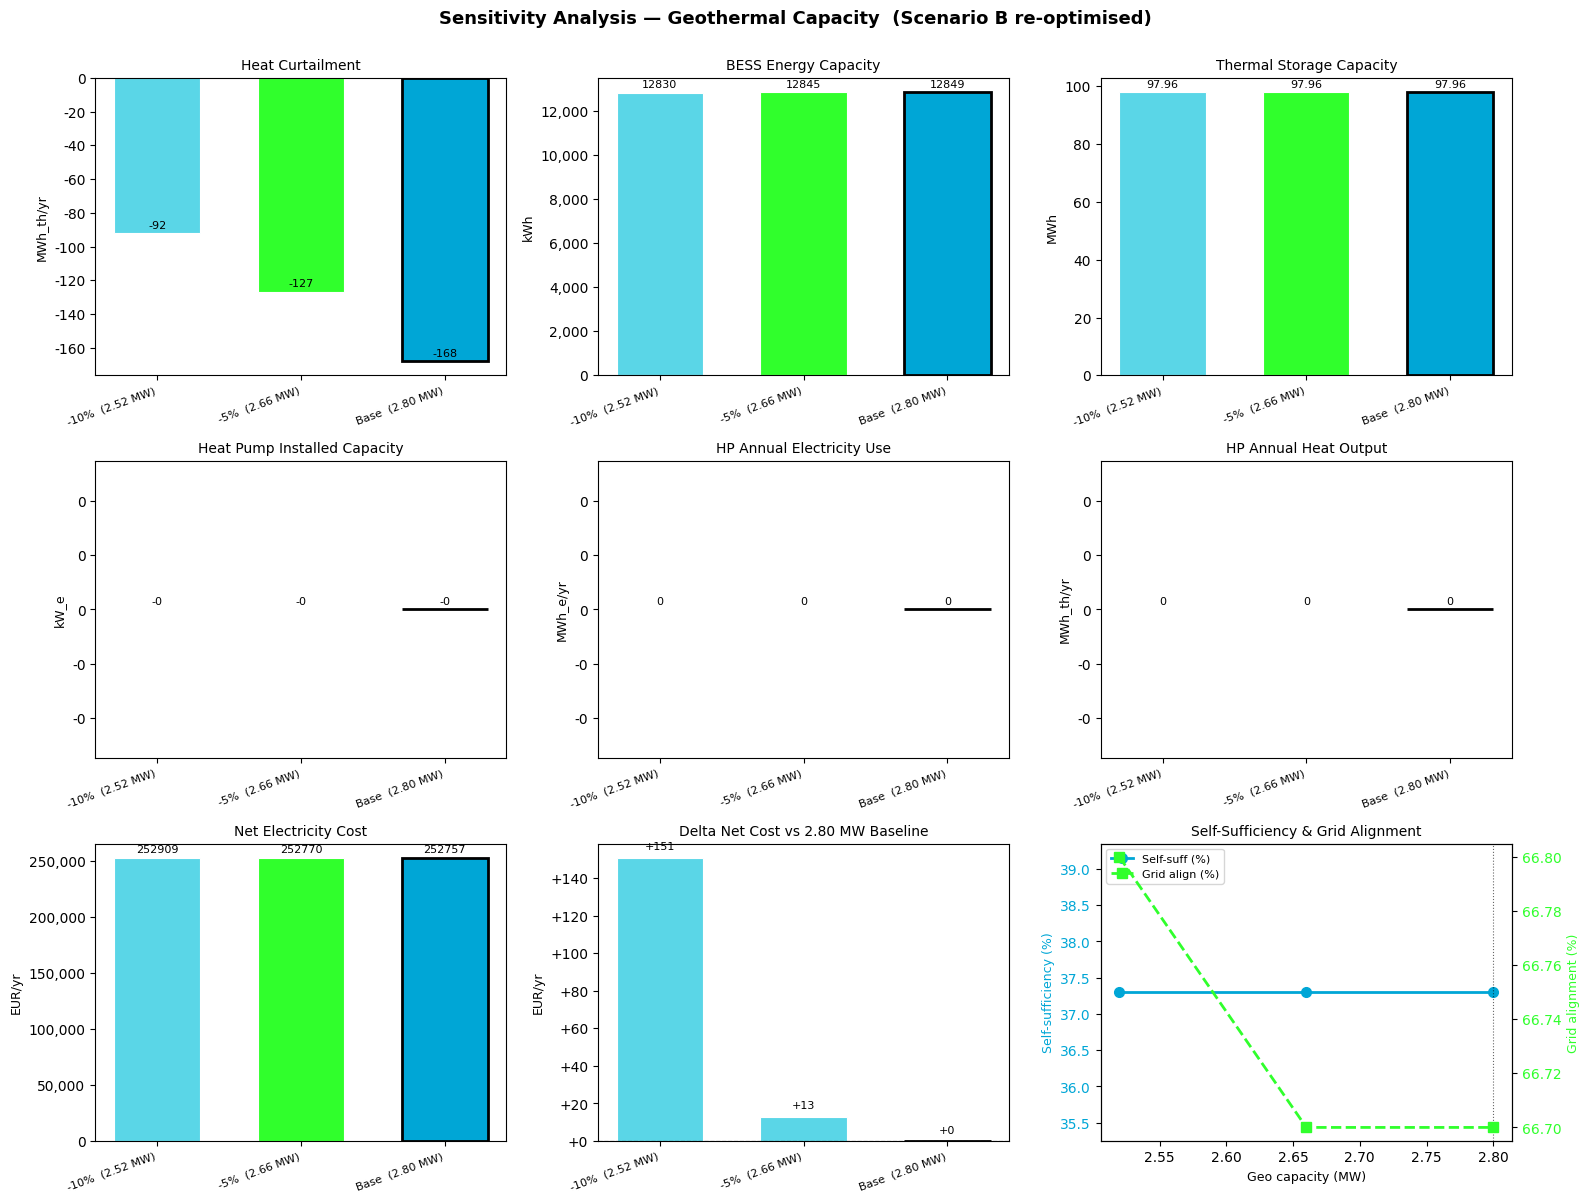

Saved: geo_sensitivity.png


In [152]:
# ═══════════════════════════════════════════════════════════════════════════
# SENSITIVITY CHARTS — Geothermal Capacity
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as _mticker

_labels  = _df_sens.index.tolist()
_x       = np.arange(len(_labels))
_geo_mws = _df_sens["Geo cap (MW)"].values
_bar_clr = ["#5AD6E7", "#30FF2C", "#00A6D6", "#0AE150"]   # red  orange  blue  green

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(
    "Sensitivity Analysis — Geothermal Capacity  (Scenario B re-optimised)",
    fontsize=13, fontweight="bold", y=0.998)

def _bar_panel(ax, vals, ylabel, title, fmt="{:.0f}", show_base=True):
    bars = ax.bar(_x, vals, color=_bar_clr, edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_xticks(_x)
    ax.set_xticklabels(_labels, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(_mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    if show_base:
        bars[2].set_edgecolor("black"); bars[2].set_linewidth(2.0)
    _ylim = ax.get_ylim()
    _yrange = _ylim[1] - _ylim[0]
    for bar, val in zip(bars, vals):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + _yrange * 0.01,
                    fmt.format(val), ha="center", va="bottom", fontsize=8)

# Row 1: Curtailment | BESS energy | TS energy
_bar_panel(axes[0, 0], _df_sens["Curtail (MWh/yr)"].values,
           "MWh_th/yr", "Heat Curtailment")
_bar_panel(axes[0, 1], _df_sens["BESS energy (kWh)"].values,
           "kWh", "BESS Energy Capacity")
_bar_panel(axes[0, 2], _df_sens["TS energy (MWh)"].values,
           "MWh", "Thermal Storage Capacity", fmt="{:.2f}")

# Row 2: HP installed size | HP annual electricity use | HP annual heat output
_bar_panel(axes[1, 0], _df_sens["HP size (kW_e)"].values,
           "kW_e", "Heat Pump Installed Capacity")
_bar_panel(axes[1, 1], _df_sens["HP elec (MWh_e/yr)"].values,
           "MWh_e/yr", "HP Annual Electricity Use")
_bar_panel(axes[1, 2], _df_sens["HP heat (MWh_th/yr)"].values,
           "MWh_th/yr", "HP Annual Heat Output")

# Row 3: Net cost | Delta cost vs baseline | SS + Grid alignment (twin axis)
_bar_panel(axes[2, 0], _df_sens["Net elec cost (EUR/yr)"].values,
           "EUR/yr", "Net Electricity Cost")

_dv     = _df_sens["Delta cost vs base (EUR/yr)"].values
_dc_clr = ["#5AD6E7" if v > 0 else ("#0AE150" if v < 0 else "#1FEAD6") for v in _dv]
_dbars  = axes[2, 1].bar(_x, _dv, color=_dc_clr, edgecolor="white", linewidth=0.8, width=0.6)
axes[2, 1].axhline(0, color="black", lw=0.8, ls="--")
axes[2, 1].set_xticks(_x)
axes[2, 1].set_xticklabels(_labels, rotation=20, ha="right", fontsize=8)
axes[2, 1].set_ylabel("EUR/yr", fontsize=9)
axes[2, 1].set_title("Delta Net Cost vs 2.80 MW Baseline", fontsize=10)
axes[2, 1].yaxis.set_major_formatter(_mticker.FuncFormatter(lambda v, _: f"{v:+,.0f}"))
_dbars[2].set_edgecolor("black"); _dbars[2].set_linewidth(2.0)
_dy_range = axes[2, 1].get_ylim()[1] - axes[2, 1].get_ylim()[0]
for bar, val in zip(_dbars, _dv):
    if not np.isnan(float(val)):
        axes[2, 1].text(bar.get_x() + bar.get_width() / 2,
                         val + (_dy_range * 0.02 if val >= 0 else -_dy_range * 0.02),
                         f"{val:+,.0f}", ha="center",
                         va="bottom" if val >= 0 else "top", fontsize=8)

_ax_ss = axes[2, 2]
_ax_ga = _ax_ss.twinx()
_l1, = _ax_ss.plot(_geo_mws, _df_sens["Self-suff (%)"].values,
                    "o-", color="#00A6D6", lw=2.0, ms=7, label="Self-suff (%)")
_l2, = _ax_ga.plot(_geo_mws, _df_sens["Grid align (%)"].values,
                    "s--", color="#30FF2C", lw=2.0, ms=7, label="Grid align (%)")
_ax_ss.set_xlabel("Geo capacity (MW)", fontsize=9)
_ax_ss.set_ylabel("Self-sufficiency (%)", color="#00A6D6", fontsize=9)
_ax_ga.set_ylabel("Grid alignment (%)", color="#30FF2C", fontsize=9)
_ax_ss.tick_params(axis="y", labelcolor="#00A6D6")
_ax_ga.tick_params(axis="y", labelcolor="#30FF2C")
_ax_ss.set_title("Self-Sufficiency & Grid Alignment", fontsize=10)
_ax_ss.legend(handles=[_l1, _l2], fontsize=8, loc="upper left")
_ax_ss.axvline(2.80, color="black", lw=0.8, ls=":", alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.997])
_fname = "geo_sensitivity.png"
plt.savefig(_fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fname}")

In [153]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — Grid Import Capacity
# -10% (1234.8 kW)  -5% (1303.4 kW)  Base (1372.0 kW — pre-computed)
# +5% (1440.6 kW)  +10% (1509.2 kW)
# Base row uses existing Cell 1 results — no re-solve.
# Non-base scenarios re-optimise Scenario B (PyPSA / HiGHS).
# Delta cost = net electricity cost vs 1372 kW baseline (positive = costlier).
# Requires prior cells executed for grid_stress / declared_import_kw (alignment).
# ═══════════════════════════════════════════════════════════════════════════════

import time as _time

_SOLVER_THREADS = 4        # adjust to available CPU cores
_GRID_BASE_KW   = 1372.0
_GRID_SCENS = [
    ("-10%  (1234.8 kW)", round(_GRID_BASE_KW * 0.90, 1)),
    (" -5%  (1303.4 kW)", round(_GRID_BASE_KW * 0.95, 1)),
    (" +5%  (1440.6 kW)", round(_GRID_BASE_KW * 1.05, 1)),
    ("+10%  (1509.2 kW)", round(_GRID_BASE_KW * 1.10, 1)),
]

# ── save originals ─────────────────────────────────────────────────────────────
_gsv = dict(
    GRID_IMPORT_MAX_KW=GRID_IMPORT_MAX_KW, _P_IMPORT_ELEC=_P_IMPORT_ELEC,
    n_comb=n_comb, bat_e_kwh=bat_e_kwh, bat_p_kw=bat_p_kw,
    hp_p_nom_e=hp_p_nom_e, ts_p_nom_kw=ts_p_nom_kw, ts_e_mwh=ts_e_mwh,
)
_grid_base_net_cost = comb_net_cost   # 1372 kW from Cell 1

# ── base row from existing Cell 1 / Cell 2 results (no re-solve) ──────────────
try:
    _base_al = round(walB * 100, 1)
except NameError:
    _base_al = float("nan")

_grid_rows = [{
    "Scenario":               "Base  (1372.0 kW)",
    "Grid cap (kW)":          _GRID_BASE_KW,
    "BESS energy (kWh)":      round(bat_e_kwh, 0),
    "BESS power (kW)":        round(bat_p_kw, 0),
    "HP size (kW_e)":         round(hp_p_nom_e, 0),
    "TS energy (MWh)":        round(ts_e_mwh, 2),
    "Curtail (MWh/yr)":       round(curtail_mwh, 1),
    "Net elec cost (EUR/yr)": round(comb_net_cost, 0),
    "Delta cost (EUR/yr)":    0,
    "Self-suff (%)":          round(ss_comb, 1),
    "Grid align (%)":         _base_al,
}]

for _label, _cap in _GRID_SCENS:
    _t0 = _time.time()
    print(f"\n{'─'*62}\n  Scenario: {_label}\n{'─'*62}")

    # 1. Update grid cap globals
    GRID_IMPORT_MAX_KW = _cap
    _P_IMPORT_ELEC     = GRID_IMPORT_MAX_KW

    # 2. Build and optimise (mirrors main Scenario B solve)
    _n = build_combined_network(heat_load_mw, dac_config=DAC_CONFIG, solve=False)
    _st, _cd = _n.optimize(
        solver_name="highs", log_to_console=False,
        extra_functionality=_add_all_constraints,
        solver_options={"threads": _SOLVER_THREADS},
    )
    if _st != "ok":
        print(f"  WARNING: Solver {_st!r} / {_cd!r} — skipping")
        continue

    # 3. Capacities
    _z      = pd.Series(0.0, index=_n.snapshots)
    _bat_e  = float(_n.stores.e_nom_opt["battery_store"])
    _bat_p  = float(_n.links.p_nom_opt["bat_charge"])
    _hp_kwe = float(_n.links.p_nom_opt["heat_pump"])
    _ts_kw  = float(_n.storage_units.p_nom_opt["heat_storage"])
    _ts_mwh = _ts_kw * _ts_max_h / 1e3

    # 4. Dispatch flows
    _lp0, _lp1 = _n.links_t.p0, _n.links_t.p1
    _hp_e  = _lp0["heat_pump"]      if "heat_pump"     in _lp0.columns else _z
    _geo_e = _lp0["geothermal"]     if "geothermal"    in _lp0.columns else _z
    _dac_e = _lp0["dac"]            if "dac"           in _lp0.columns else _z
    _bat_c = _lp0["bat_charge"]     if "bat_charge"    in _lp0.columns else _z
    _bat_d = -_lp1["bat_discharge"] if "bat_discharge" in _lp1.columns else _z
    _curt  = (_n.generators_t.p["heat_curtail"]
              if "heat_curtail" in _n.generators_t.p.columns else _z)
    _ei    = (_n.generators_t.p["grid_import"]
              if "grid_import"  in _n.generators_t.p.columns else _z)
    _ee    = -(_n.generators_t.p["grid_export"]
               if "grid_export" in _n.generators_t.p.columns else _z)
    _pv    = (_n.generators_t.p["pv"]
              if "pv"           in _n.generators_t.p.columns else _z)
    _soc   = (_n.stores_t.e["battery_store"]
              if "battery_store" in _n.stores_t.e.columns else _z)

    # 5. Annual totals and economic
    _curt_mwh = float((_curt  * DT_H).sum() / 1e3)
    _e_cost   = float((_ei * _import_price_H * DT_H).sum())
    _e_rev    = float((_ee * _da_price_H     * DT_H).sum())
    _net_cost = _e_cost - _e_rev
    _delta    = _net_cost - _grid_base_net_cost

    # 6. Self-sufficiency
    _ss = _pv_bat_ss(_pv, _ei, _load_kw_H + _hp_e + _geo_e + _dac_e,
                     _bat_c, _bat_d, _soc)

    # 7. Grid alignment (hourly ei → 15-min; baseline = declared_import_kw)
    try:
        _ei_15m = _ei.reindex(declared_import_kw.index, method="ffill")
        _al_w, _ = _calc_alignment_weighted(_ei_15m, declared_import_kw)
        _al_pct = round(_al_w, 1)
    except NameError:
        _al_pct = float("nan")
        print("  Alignment skipped: declared_import_kw not defined (run Part II first)")
    except Exception as _exc:
        _al_pct = float("nan")
        print(f"  Alignment error: {_exc}")

    _grid_rows.append({
        "Scenario":               _label.strip(),
        "Grid cap (kW)":          _cap,
        "BESS energy (kWh)":      round(_bat_e, 0),
        "BESS power (kW)":        round(_bat_p, 0),
        "HP size (kW_e)":         round(_hp_kwe, 0),
        "TS energy (MWh)":        round(_ts_mwh, 2),
        "Curtail (MWh/yr)":       round(_curt_mwh, 1),
        "Net elec cost (EUR/yr)": round(_net_cost, 0),
        "Delta cost (EUR/yr)":    round(_delta, 0),
        "Self-suff (%)":          round(_ss, 1),
        "Grid align (%)":         _al_pct,
    })
    print(f"  Done {_time.time()-_t0:.0f}s | "
          f"BESS {_bat_e:,.0f} kWh | HP {_hp_kwe:,.0f} kW_e | "
          f"curt {_curt_mwh:.0f} MWh | delta {_delta:+,.0f} EUR | "
          f"SS {_ss:.1f}% | GA {_al_pct}%")

# ── restore originals ──────────────────────────────────────────────────────────
GRID_IMPORT_MAX_KW = _gsv["GRID_IMPORT_MAX_KW"]
_P_IMPORT_ELEC     = _gsv["_P_IMPORT_ELEC"]
n_comb      = _gsv["n_comb"]
bat_e_kwh   = _gsv["bat_e_kwh"]
bat_p_kw    = _gsv["bat_p_kw"]
hp_p_nom_e  = _gsv["hp_p_nom_e"]
ts_p_nom_kw = _gsv["ts_p_nom_kw"]
ts_e_mwh    = _gsv["ts_e_mwh"]

# ── sort and display ───────────────────────────────────────────────────────────
_df_grid = (pd.DataFrame(_grid_rows)
              .set_index("Scenario")
              .sort_values("Grid cap (kW)"))
print("\n" + "=" * 72)
print("  SENSITIVITY — Grid Import Capacity  (delta = vs 1372 kW baseline)")
print("=" * 72)
print(_df_grid.T.to_string())


──────────────────────────────────────────────────────────────
  Scenario: -10%  (1234.8 kW)
──────────────────────────────────────────────────────────────
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 177.34it/s]
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible




──────────────────────────────────────────────────────────────
  Scenario:  -5%  (1303.4 kW)
──────────────────────────────────────────────────────────────
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 130.67it/s]
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible




──────────────────────────────────────────────────────────────
  Scenario:  +5%  (1440.6 kW)
──────────────────────────────────────────────────────────────
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 176.32it/s]


  Done 32s | BESS 13,242 kWh | HP -0 kW_e | curt -218 MWh | delta -3,211 EUR | SS 37.3% | GA 66.7%

──────────────────────────────────────────────────────────────
  Scenario: +10%  (1509.2 kW)
──────────────────────────────────────────────────────────────
  [cycle] Max 300 cycles/yr constraint active


Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 198.69it/s]


  Done 38s | BESS 13,511 kWh | HP -0 kW_e | curt -218 MWh | delta -7,085 EUR | SS 37.3% | GA 66.9%

  SENSITIVITY — Grid Import Capacity  (delta = vs 1372 kW baseline)
Scenario                Base  (1372.0 kW)  +5%  (1440.6 kW)  +10%  (1509.2 kW)
Grid cap (kW)                     1372.00           1440.60            1509.20
BESS energy (kWh)                12849.00          13242.00           13511.00
BESS power (kW)                   3600.00           3600.00            3600.00
HP size (kW_e)                      -0.00             -0.00              -0.00
TS energy (MWh)                     97.96             52.17              52.17
Curtail (MWh/yr)                  -168.00           -218.00            -218.00
Net elec cost (EUR/yr)          252757.00         249546.00          245673.00
Delta cost (EUR/yr)                  0.00          -3211.00           -7085.00
Self-suff (%)                         NaN             37.30              37.30
Grid align (%)                    6632.40 

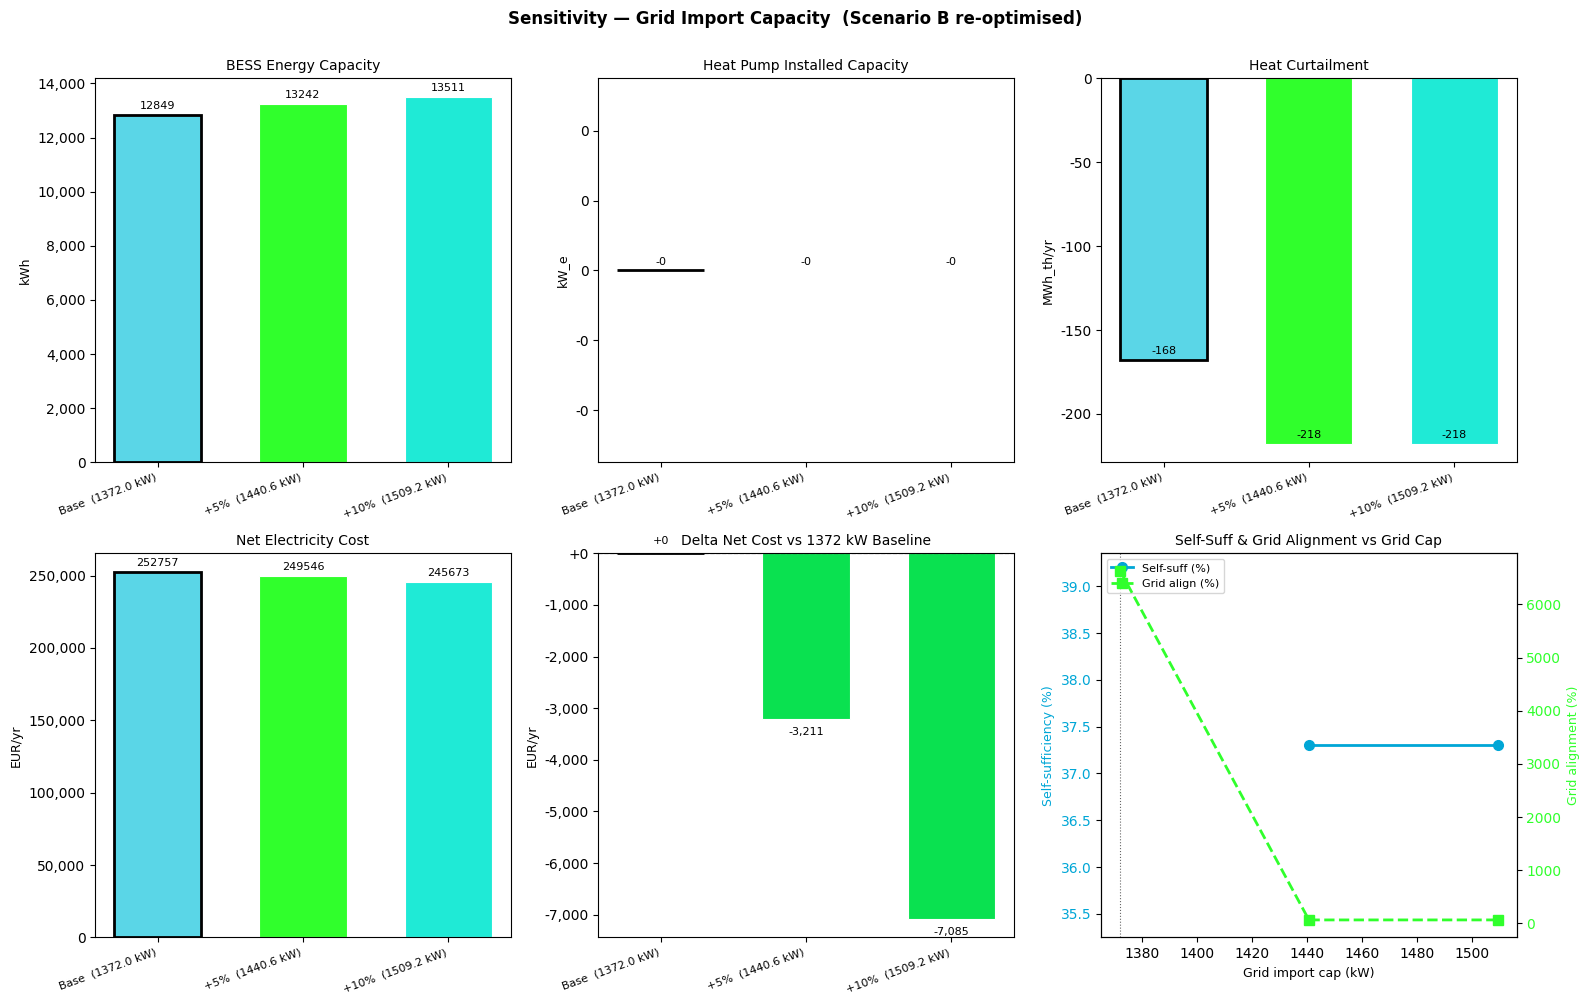

Saved: grid_cap_sensitivity_heat.png


In [154]:
# ═══════════════════════════════════════════════════════════════════════════════
# SENSITIVITY CHARTS — Grid Import Capacity
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.ticker as _mt2

_gl     = _df_grid.index.tolist()
_gx     = np.arange(len(_gl))
_gcaps  = _df_grid["Grid cap (kW)"].values
_gcols  = ["#5AD6E7", "#30FF2C", "#1FEAD6", "#00A6D6", "#0AE150"]
_gbase  = list(_df_grid["Grid cap (kW)"]).index(1372.0)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Sensitivity — Grid Import Capacity  (Scenario B re-optimised)",
             fontsize=12, fontweight="bold", y=0.999)

def _gbar(ax, vals, ylabel, title, fmt="{:.0f}"):
    bars = ax.bar(_gx, vals, color=_gcols, edgecolor="white", lw=0.8, width=0.6)
    ax.set_xticks(_gx)
    ax.set_xticklabels(_gl, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9); ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(_mt2.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    bars[_gbase].set_edgecolor("black"); bars[_gbase].set_linewidth(2.0)
    _yr = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, val in zip(bars, vals):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + _yr * 0.01,
                    fmt.format(val), ha="center", va="bottom", fontsize=8)

# Row 1: BESS energy | HP size | Curtailment
_gbar(axes[0, 0], _df_grid["BESS energy (kWh)"].values, "kWh",      "BESS Energy Capacity")
_gbar(axes[0, 1], _df_grid["HP size (kW_e)"].values,    "kW_e",     "Heat Pump Installed Capacity")
_gbar(axes[0, 2], _df_grid["Curtail (MWh/yr)"].values,  "MWh_th/yr","Heat Curtailment")

# Row 2: Net cost | Delta cost | SS + GA (twin axis)
_gbar(axes[1, 0], _df_grid["Net elec cost (EUR/yr)"].values, "EUR/yr", "Net Electricity Cost")

_dv = _df_grid["Delta cost (EUR/yr)"].values
_dc = ["#5AD6E7" if v > 0 else ("#0AE150" if v < 0 else "#1FEAD6") for v in _dv]
_db = axes[1, 1].bar(_gx, _dv, color=_dc, edgecolor="white", lw=0.8, width=0.6)
axes[1, 1].axhline(0, color="black", lw=0.8, ls="--")
axes[1, 1].set_xticks(_gx)
axes[1, 1].set_xticklabels(_gl, rotation=20, ha="right", fontsize=8)
axes[1, 1].set_ylabel("EUR/yr", fontsize=9)
axes[1, 1].set_title("Delta Net Cost vs 1372 kW Baseline", fontsize=10)
axes[1, 1].yaxis.set_major_formatter(_mt2.FuncFormatter(lambda v, _: f"{v:+,.0f}"))
_db[_gbase].set_edgecolor("black"); _db[_gbase].set_linewidth(2.0)
_dyr = axes[1, 1].get_ylim()[1] - axes[1, 1].get_ylim()[0]
for bar, val in zip(_db, _dv):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                     val + (_dyr * 0.02 if val >= 0 else -_dyr * 0.02),
                     f"{val:+,.0f}", ha="center",
                     va="bottom" if val >= 0 else "top", fontsize=8)

_ax_ss = axes[1, 2]; _ax_ga = _ax_ss.twinx()
_l1, = _ax_ss.plot(_gcaps, _df_grid["Self-suff (%)"].values,
                    "o-", color="#00A6D6", lw=2, ms=7, label="Self-suff (%)")
_l2, = _ax_ga.plot(_gcaps, _df_grid["Grid align (%)"].values,
                    "s--", color="#30FF2C", lw=2, ms=7, label="Grid align (%)")
_ax_ss.set_xlabel("Grid import cap (kW)", fontsize=9)
_ax_ss.set_ylabel("Self-sufficiency (%)", color="#00A6D6", fontsize=9)
_ax_ga.set_ylabel("Grid alignment (%)", color="#30FF2C", fontsize=9)
_ax_ss.tick_params(axis="y", labelcolor="#00A6D6")
_ax_ga.tick_params(axis="y", labelcolor="#30FF2C")
_ax_ss.set_title("Self-Suff & Grid Alignment vs Grid Cap", fontsize=10)
_ax_ss.legend(handles=[_l1, _l2], fontsize=8, loc="upper left")
_ax_ss.axvline(1372, color="black", lw=0.8, ls=":", alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.998])
_gfname = "grid_cap_sensitivity_heat.png"
plt.savefig(_gfname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_gfname}")

In [155]:
# ─── PV CAPEX Sensitivity Analysis ─────────────────────────────────────
_pv_prices_wp = [1.80, 1.60, 1.40, 1.20, 1.00]  # €/Wp
_vfmt = lambda x: f'{x:,.0f}' if x == x else 'n/a'
_pfmt = lambda x: f'{x:.1f} yr' if 0 < x < 999 else 'n/a'
# PV Shapley approx: standalone + half the synergy (synergy = true marginal - standalone)
_pv_sha = pv_benefit + (_pv_true_marginal - pv_benefit) / 2
W4 = 86
print('\n' + '='*W4)
print(f'  PV CAPEX SENSITIVITY  ({_PV_KWP_STC:,.0f} kWp STC nameplate)')
print('='*W4)
print(f"  {'Metric':<42}" + ''.join(f"  {'\u20ac'+str(p)+'/Wp':>8}" for p in _pv_prices_wp))
print('  ' + '-'*80)
_sv = []
for _p in _pv_prices_wp:
    _pce = _PV_KWP_STC * _p * 1000
    _tce = _pce + bat_capex_e + heat_capex_e
    _npv = sum(annual_benefit / (1 + WACC)**yr for yr in range(1, _life_yr + 1)) - _tce
    _sv.append((_pce, _tce, _npv,
                _pce / _pv_true_marginal    if _pv_true_marginal > 1 else float('inf'),
                _pce / _pv_sha              if _pv_sha           > 1 else float('inf'),
                bat_capex_e / _bat_true_marginal if _bat_true_marginal > 1 else float('inf'),
                _tce / annual_benefit       if annual_benefit    > 1 else float('inf')))
_npvlb = f'System NPV ({_life_yr} yr @ {int(WACC*100)}% WACC) (\u20ac)'
print(f"  {'PV CAPEX (\u20ac)':<42}" + ''.join(f'  {s[0]:>8,.0f}' for s in _sv))
print(f"  {'Total system CAPEX (\u20ac)':<42}" + ''.join(f'  {s[1]:>8,.0f}' for s in _sv))
print('  ' + '-'*80)
print(f"  {'PV standalone net O&M (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(pv_benefit):>8}' for _ in _sv))
print(f"  {'PV true marginal net O&M (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(_pv_true_marginal):>8}' for _ in _sv))
print(f"  {'PV Shapley approx (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(_pv_sha):>8}' for _ in _sv))
print(f"  {'Bat true marginal net O&M (\u20ac/yr)  [fixed]':<42}" + ''.join(f'  {_vfmt(_bat_true_marginal):>8}' for _ in _sv))
print('  ' + '-'*80)
print(f"  {'PV true marginal payback':<42}" + ''.join(f'  {_pfmt(s[3]):>8}' for s in _sv))
print(f"  {'PV Shapley approx payback':<42}" + ''.join(f'  {_pfmt(s[4]):>8}' for s in _sv))
print(f"  {'Battery true marginal payback  [fixed]':<42}" + ''.join(f'  {_pfmt(s[5]):>8}' for s in _sv))
print(f"  {'System payback':<42}" + ''.join(f'  {_pfmt(s[6]):>8}' for s in _sv))
print(f'  {_npvlb:<42}' + ''.join(f'  {s[2]:>8,.0f}' for s in _sv))
print('='*W4)
print(f'  PV Shapley = standalone + (true marginal - standalone) / 2  =  \u20ac{_pv_sha:,.0f}/yr')
print(f'  True marginal upper bound (all synergy to PV): \u20ac{_pv_true_marginal:,.0f}/yr')
print(f'  Annual system benefit: \u20ac{annual_benefit:+,.0f}/yr  |  Bat CAPEX fixed: \u20ac{bat_capex_e:,.0f}')



  PV CAPEX SENSITIVITY  (1,885 kWp STC nameplate)
  Metric                                       €1.8/Wp   €1.6/Wp   €1.4/Wp   €1.2/Wp   €1.0/Wp
  --------------------------------------------------------------------------------
  PV CAPEX (€)                                3,393,000  3,016,000  2,639,000  2,262,000  1,885,000
  Total system CAPEX (€)                      11,743,709  11,366,709  10,989,709  10,612,709  10,235,709
  --------------------------------------------------------------------------------
  PV standalone net O&M (€/yr)  [fixed]         58,067    58,067    58,067    58,067    58,067
  PV true marginal net O&M (€/yr)  [fixed]     133,777   133,777   133,777   133,777   133,777
  PV Shapley approx (€/yr)  [fixed]             95,922    95,922    95,922    95,922    95,922
  Bat true marginal net O&M (€/yr)  [fixed]    -29,160   -29,160   -29,160   -29,160   -29,160
  --------------------------------------------------------------------------------
  PV true marginal p